# EDA for New Occurrence Data

"pt" = Permian-Triassic = Perm_Trias folder

"gl" = Guadilupian-Ladinian = Guad-Ladin folder

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
iso = pd.read_csv("C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\data\\Perm-Trias\\songEA_isotopic_data_pt_1myr\\isotopic_1myr_binary_stages_timevar.csv")
iso_offset = pd.read_csv("C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\data\\Perm-Trias\\songEA_isotopic_data_pt_1myr\\isotopic_1myr_binary_stages_timevar_offset.csv")

iso.equals(iso_offset)

True

# Permian-Triassic Data


## Loading + Filtering + EDA Occs Data

In [2]:
pt_reptilia_all = pd.read_excel("Perm-Trias/occs_combined/reptilia_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_All_AF_Tiago_combined.xlsx")
pt_reptilia_terr = pd.read_excel("Perm-Trias/occs_combined/reptilia_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_terres_AF_Tiago_combined.xlsx")
pt_synapsida = pd.read_excel("Perm-Trias/occs_combined/synapsida_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_AF_Tiago_combined.xlsx")

# gl_reptilia = pd.read_excel("Guad-Ladin/reptilia_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_terres_MidTria.xlsx")
# gl_synapsida = pd.read_excel("Guad-Ladin/synapsida_occ_(PBDB+New)_genus_filt(no_ichno)_lowAgeUncer_MidTria.xlsx")

In [3]:
pt_reptilia_all.columns

Index(['occurrence_no', 'occurrence_no_AF', 'id', 'id_seperated', 'expt',
       'Rotated latitude', 'Rotated longitude', 'i_index', 'j_index',
       'Topo. (m)',
       ...
       'geoplate', 'paleoage', 'paleolng', 'paleolat', 'paleomodel2',
       'geoplate2', 'paleoage2', 'paleolng2', 'paleolat2', 'paleomodel3'],
      dtype='object', length=296)

In [4]:

pt_reptilia_all_filtered = pt_reptilia_all[['id', 'occurrence_no', 'occurrence_no_AF', 'Rotated latitude', 'genus', 'age_max', 'age_min', 'Epoch']]
pt_reptilia_terr_filtered = pt_reptilia_terr[['id', 'occurrence_no', 'occurrence_no_AF', 'Rotated latitude', 'genus', 'age_max', 'age_min', 'Epoch']]
pt_synapsida_filtered = pt_synapsida[['id', 'occurrence_no', 'occurrence_no_AF', 'Rotated latitude', 'genus', 'age_max', 'age_min', 'Epoch']]

# Need to add 'id' back in
# gl_reptilia_filtered = gl_reptilia[['id', 'occurrence_no', 'occurrence_no_AF', 'genus', 'age_max', 'age_min']]
# gl_synapsida_filtered = gl_synapsida[['id', 'occurrence_no', 'occurrence_no_AF', 'genus', 'age_max', 'age_min']]

In [5]:
list_filtered_dfs = [pt_reptilia_all_filtered, pt_reptilia_terr_filtered, pt_synapsida_filtered]
                        # ,gl_reptilia_filtered, gl_synapsida_filtered]

list_filtered_dfs_names = ['pt_reptilia_all_filtered', 'pt_reptilia_terr_filtered', 'pt_synapsida_filtered']
                        # ,'gl_reptilia_filtered', 'gl_synapsida_filtered']

# write a loop for 0:len(list_filtered_dfs) to print the name of each dataframe and its description
# and the number of missing values in each column
for i in range(len(list_filtered_dfs)):
    print(f"DataFrame: {list_filtered_dfs_names[i]}")
    print(list_filtered_dfs[i].describe())
    print(list_filtered_dfs[i].isna().sum())
    # Check that occurrence_no_AF is the same as occurrence_no, because the former came from Alex's dataset and the latter from Tiago's dataset.
    # If they're the same we know merging the two datasets happened correctly.
    different_rows = list_filtered_dfs[i].loc[list_filtered_dfs[i]['occurrence_no'] != list_filtered_dfs[i]['occurrence_no_AF']]
    length_different_rows = different_rows.shape[0]
    print(f"Number of rows where 'occurrence_no' and 'occurrence_no_AF' are different: {length_different_rows}")


DataFrame: pt_reptilia_all_filtered
               id  Rotated latitude      age_max      age_min
count  3987.00000       3987.000000  3987.000000  3987.000000
mean   5134.00000        -71.255378   244.115497   234.918219
std    1151.09209        820.651838    22.017241    24.675819
min    3141.00000      -9999.000000   201.400000   199.500000
25%    4137.50000        -47.039270   227.000000   208.500000
50%    5134.00000          1.353064   242.000000   237.000000
75%    6130.50000         27.011270   259.510000   251.902000
max    7127.00000         61.323520   298.900000   293.520000
id                  0
occurrence_no       0
occurrence_no_AF    0
Rotated latitude    0
genus               0
age_max             0
age_min             0
Epoch               0
dtype: int64
Number of rows where 'occurrence_no' and 'occurrence_no_AF' are different: 0
DataFrame: pt_reptilia_terr_filtered
                id  Rotated latitude      age_max      age_min
count  3140.000000       3140.000000  31

## Ages Visualization (Range Plots)

In [6]:
# Custom function to plot age RANGE (x) frequency (y) with log scale
def range_plot(df, df_name, age_max_col='age_max', age_min_col='age_min'):
    # # Count the frequency of each age range
    # df['range'] = df.apply(lambda row: (row['age_max'], row['age_min']), axis=1)
    # frequency = df['range'].value_counts().sort_index()
    
    # Count the frequency of each age range
    df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)
    frequency = df['range'].value_counts().sort_index()
    # Create the plot
    fig, ax = plt.subplots(figsize=(12,6))

    # Plot each range as a horizontal line with log-transformed y-values
    for (age_min, age_max), count in frequency.items():
        ax.plot([age_min, age_max], [np.log(count)] * 2, 'b-', linewidth=2)

    # Set the axis labels and title
    ax.set_xlabel('Age')
    ax.set_ylabel('Log(Frequency)')
    ax.set_title(f'{df_name} Age Range Frequency Plot (Log Scale)')

    # Get the x-axis limits
    x_min, x_max = ax.get_xlim()

    # Create ticks for every 1 unit
    ticks = np.arange(np.ceil(x_min), np.floor(x_max) + 1, 1)
    ax.set_xticks(ticks)

    # Create labels for every 5 units
    labels = [str(int(x)) if x % 5 == 0 else '' for x in ticks]
    ax.set_xticklabels(labels)

    # Invert the x-axis
    ax.invert_xaxis()

    # Add horizontal line at y=log(10)
    ax.axhline(y=np.log(10), color='r', linestyle='--', linewidth=2)

    # Customize y-axis ticks to show original frequency values
    y_ticks = ax.get_yticks()
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{np.exp(y):.0f}' for y in y_ticks])

    # Add vertical lines at the time-bin x-values
    vertical_lines = [290.1, 283.5, 273, 264.3, 259.5, 252, 247, 242, 237, 227, 217, 208]
    for vline in vertical_lines:
        ax.axvline(x=vline, color='g', linestyle='--', linewidth=1)

    # Show the plot
    plt.tight_layout()
    plt.show()
    plt.close()

    return fig

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_19116\2271861712.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)


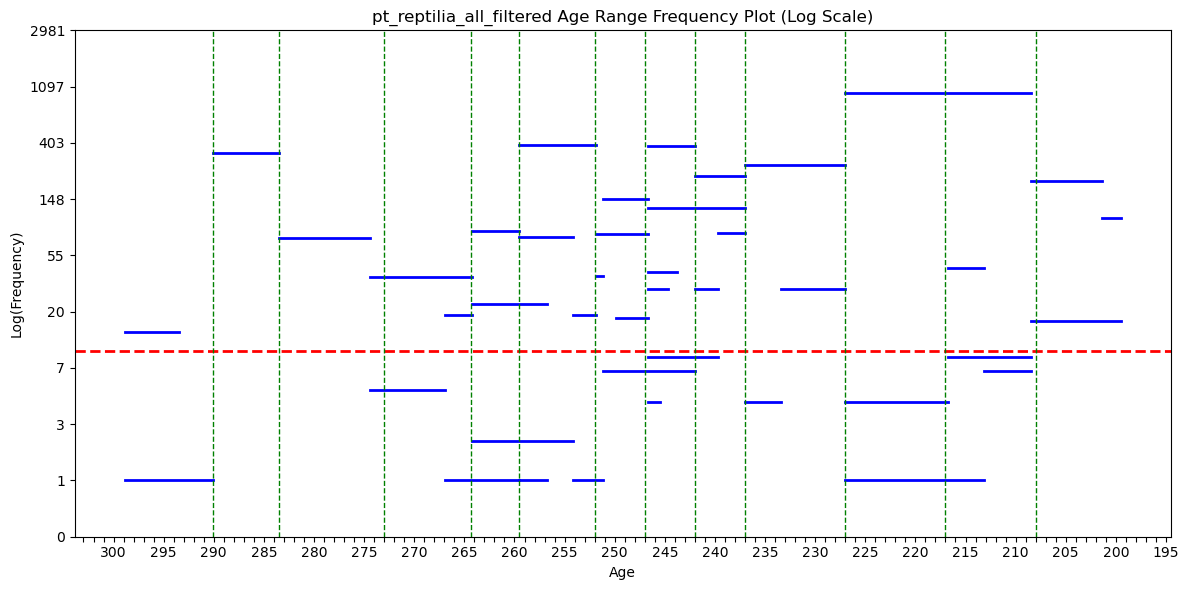

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_19116\2271861712.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)


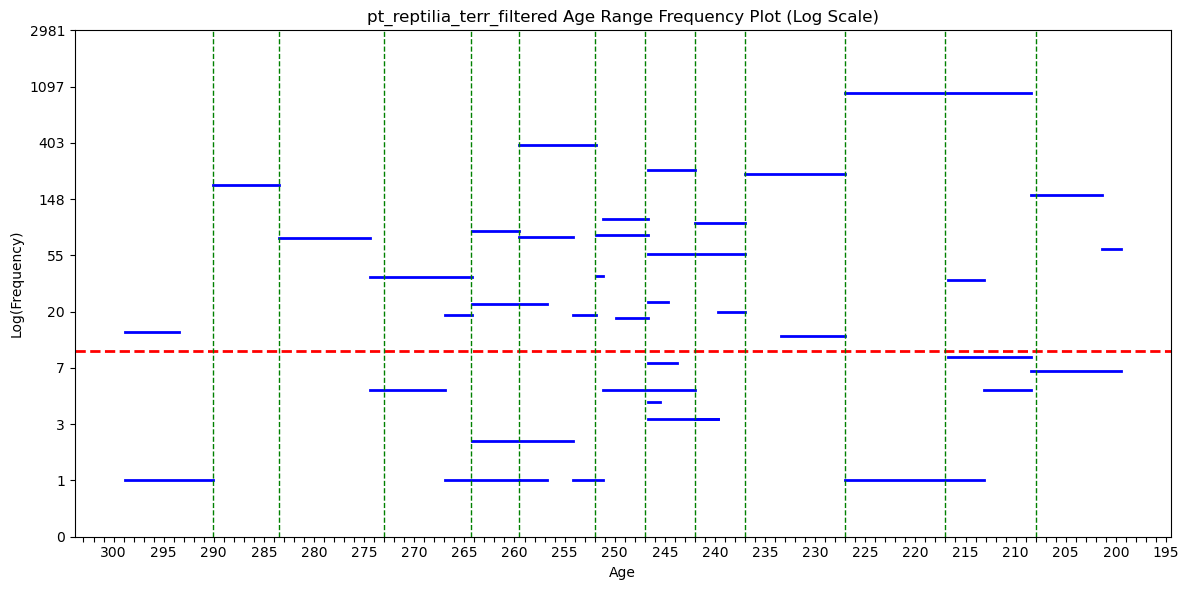

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_19116\2271861712.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['range'] = df.apply(lambda row: (row[age_max_col], row[age_min_col]), axis=1)


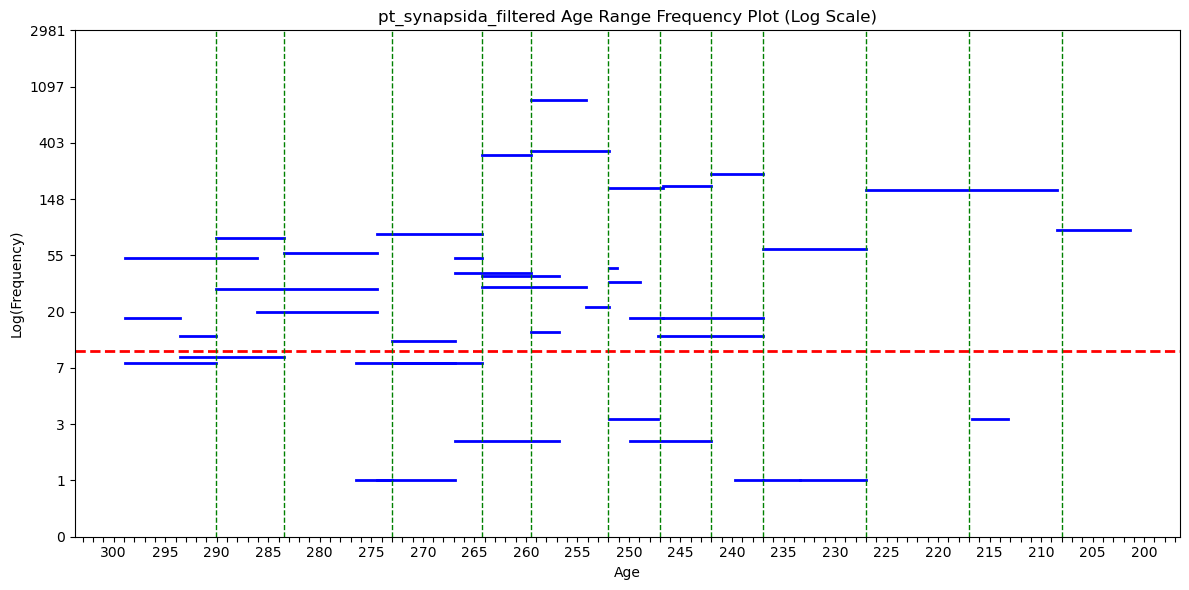

In [8]:
# plot each dataframe using the custom function
# then save the figures

for i in range(len(list_filtered_dfs)):
    fig = range_plot(list_filtered_dfs[i], list_filtered_dfs_names[i])
    fig.savefig(f"Perm-Trias/pt_data_visualizations/occs_age_range_frequencies/{list_filtered_dfs_names[i]}_age_range_frequency_plot.png", dpi=600)


## Dropping non-letter 'genus' strings

In [9]:
# See if there are any non-letters in the 'genus' columns of each dataframe
for i in range(len(list_filtered_dfs)):
    non_letters = list_filtered_dfs[i]['genus'].str.contains(r'[^a-zA-Z]', na=False)
    if non_letters.any():
        print(f"DataFrame: {list_filtered_dfs_names[i]}")
        print(f"Non-letter characters found in 'genus': {list_filtered_dfs[i][non_letters]['genus'].unique()}\n")
    else:
        print(f"DataFrame: {list_filtered_dfs_names[i]} - No non-letter characters found in 'genus'.\n")

DataFrame: pt_reptilia_all_filtered
Non-letter characters found in 'genus': ['new Neotheropoda' 'new Rhynchocephalia' 'Stenoscelida\xa0']

DataFrame: pt_reptilia_terr_filtered
Non-letter characters found in 'genus': ['new Neotheropoda' 'new Rhynchocephalia' 'Stenoscelida\xa0']

DataFrame: pt_synapsida_filtered
Non-letter characters found in 'genus': ['-' 'Bonacynodon ']



In [10]:
# print the rows with non-letter characters in the 'genus' column
for i in range(len(list_filtered_dfs)):
    non_letters = list_filtered_dfs[i]['genus'].str.contains(r'[^a-zA-Z]', na=False)
    if non_letters.any():
        print(f"DataFrame: {list_filtered_dfs_names[i]}")
        print(list_filtered_dfs[i][non_letters])
        print("\n")
    else:
        print(f"DataFrame: {list_filtered_dfs_names[i]} - No non-letter characters found in 'genus'.\n")

DataFrame: pt_reptilia_all_filtered
       id occurrence_no occurrence_no_AF  Rotated latitude  \
974  4115          N363             N363         -46.11636   
975  4116          N364             N364         -46.11636   
979  4120          N503             N503         -46.11636   

                   genus  age_max  age_min           Epoch           range  
974     new Neotheropoda    227.0    208.5  Upper Triassic  (227.0, 208.5)  
975  new Rhynchocephalia    227.0    208.5  Upper Triassic  (227.0, 208.5)  
979        Stenoscelida     227.0    208.5  Upper Triassic  (227.0, 208.5)  


DataFrame: pt_reptilia_terr_filtered
      id occurrence_no occurrence_no_AF  Rotated latitude  \
968  969          N363             N363         -46.11636   
969  970          N364             N364         -46.11636   
973  974          N503             N503         -46.11636   

                   genus  age_max  age_min           Epoch           range  
968     new Neotheropoda    227.0    208.5  Up

In [11]:
# Fixing those

# Make a copy of the filtered dataframes to avoid modifying the original ones
pt_reptilia_all_filtered_spellchecked = pt_reptilia_all_filtered.copy()
pt_reptilia_terr_filtered_spellchecked = pt_reptilia_terr_filtered.copy()
pt_synapsida_filtered_spellchecked = pt_synapsida_filtered.copy()

# Now perform all the cleaning

# Strip the ending space from row with index 979 in pt_reptilia_all_filtered in 'genus' column
pt_reptilia_all_filtered_spellchecked.at[979, 'genus'] = pt_reptilia_all_filtered_spellchecked.at[979, 'genus'].strip()

# Strip the ending space from row with index 973 in pt_reptilia_terr_filtered in 'genus' column
pt_reptilia_terr_filtered_spellchecked.at[973, 'genus'] = pt_reptilia_terr_filtered_spellchecked.at[973, 'genus'].strip()

# Strip the ending space from row with index 2685 and 2686 in pt_synapsida_filtered in 'genus' column
pt_synapsida_filtered_spellchecked.at[2685, 'genus'] = pt_synapsida_filtered_spellchecked.at[2685, 'genus'].strip()
pt_synapsida_filtered_spellchecked.at[2686, 'genus'] = pt_synapsida_filtered_spellchecked.at[2686, 'genus'].strip()

# Delete row with index 370 from pt_synapsida_all_filtered
pt_synapsida_filtered_spellchecked = pt_synapsida_filtered_spellchecked.drop(370)



In [12]:
# Check again

list_filtered_dfs_spellchecked = [pt_reptilia_all_filtered_spellchecked, pt_reptilia_terr_filtered_spellchecked, pt_synapsida_filtered_spellchecked]
list_filtered_dfs_names_spellchecked = ['pt_reptilia_all_filtered_spellchecked', 'pt_reptilia_terr_filtered_spellchecked', 'pt_synapsida_filtered_spellchecked']

# print the rows with non-letter characters in the 'genus' column
for i in range(len(list_filtered_dfs_spellchecked)):
    non_letters = list_filtered_dfs_spellchecked[i]['genus'].str.contains(r'[^a-zA-Z]', na=False)
    if non_letters.any():
        print(f"DataFrame: {list_filtered_dfs_names_spellchecked[i]}")
        print(list_filtered_dfs_spellchecked[i][non_letters])
        print("\n")
    else:
        print(f"DataFrame: {list_filtered_dfs_names_spellchecked[i]} - No non-letter characters found in 'genus'.\n")

DataFrame: pt_reptilia_all_filtered_spellchecked
       id occurrence_no occurrence_no_AF  Rotated latitude  \
974  4115          N363             N363         -46.11636   
975  4116          N364             N364         -46.11636   

                   genus  age_max  age_min           Epoch           range  
974     new Neotheropoda    227.0    208.5  Upper Triassic  (227.0, 208.5)  
975  new Rhynchocephalia    227.0    208.5  Upper Triassic  (227.0, 208.5)  


DataFrame: pt_reptilia_terr_filtered_spellchecked
      id occurrence_no occurrence_no_AF  Rotated latitude  \
968  969          N363             N363         -46.11636   
969  970          N364             N364         -46.11636   

                   genus  age_max  age_min           Epoch           range  
968     new Neotheropoda    227.0    208.5  Upper Triassic  (227.0, 208.5)  
969  new Rhynchocephalia    227.0    208.5  Upper Triassic  (227.0, 208.5)  


DataFrame: pt_synapsida_filtered_spellchecked - No non-letter ch

## PT Latitude -9999 Cleaning


In [13]:
pt_reptilia_all_filtered_spellchecked_lats = pt_reptilia_all_filtered_spellchecked.copy()
pt_reptilia_terr_filtered_spellchecked_lats = pt_reptilia_terr_filtered_spellchecked.copy()
pt_synapsida_filtered_spellchecked_lats = pt_synapsida_filtered_spellchecked.copy()


In [14]:
# Checking for nonsense values in the 'Rotated latitude' column
pt_reptilia_all_filtered_spellchecked_lats['Rotated latitude'].describe(), pt_reptilia_terr_filtered_spellchecked_lats['Rotated latitude'].describe(), pt_synapsida_filtered_spellchecked_lats['Rotated latitude'].describe()

(count    3987.000000
 mean      -71.255378
 std       820.651838
 min     -9999.000000
 25%       -47.039270
 50%         1.353064
 75%        27.011270
 max        61.323520
 Name: Rotated latitude, dtype: float64,
 count    3140.000000
 mean      -23.135116
 std       400.134800
 min     -9999.000000
 25%       -49.043510
 50%         1.353064
 75%        24.956070
 max        61.323520
 Name: Rotated latitude, dtype: float64,
 count    3184.000000
 mean      -45.700334
 std       308.060852
 min     -9999.000000
 25%       -61.365010
 50%       -52.001180
 75%       -15.491353
 max        62.825230
 Name: Rotated latitude, dtype: float64)

### Latitude Visualizations

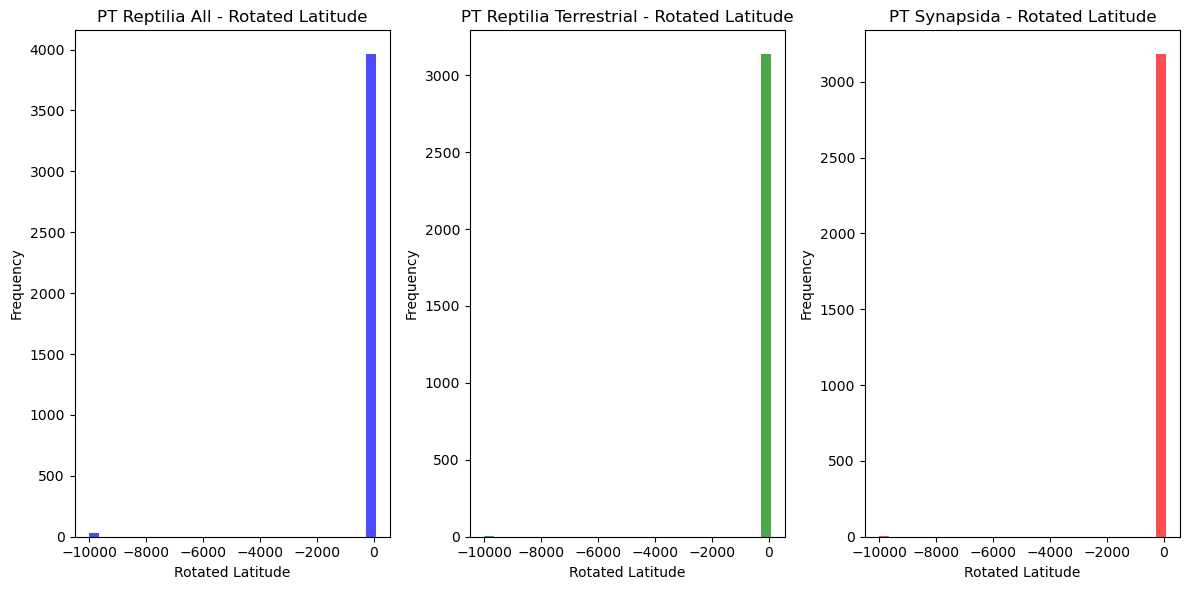

In [16]:
# Visualizing the latitudes
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.hist(pt_reptilia_all_filtered_spellchecked_lats['Rotated latitude'], bins=30, color='blue', alpha=0.7)
plt.title('PT Reptilia All - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 2)    
plt.hist(pt_reptilia_terr_filtered_spellchecked_lats['Rotated latitude'], bins=30, color='green', alpha=0.7)
plt.title('PT Reptilia Terrestrial - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 3)
plt.hist(pt_synapsida_filtered_spellchecked_lats['Rotated latitude'], bins=30, color='red', alpha=0.7)
plt.title('PT Synapsida - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Perm-Trias/pt_data_visualizations/occs_latitudes/raw_rotated_latitude_histograms.pdf')
plt.show()

In [17]:
# Viewing the rows whose latitudes are = -9999

pt_reptilia_9999_lats = pt_reptilia_all_filtered_spellchecked_lats[pt_reptilia_all_filtered_spellchecked_lats['Rotated latitude'] == -9999]
pt_reptilia_terr_9999_lats = pt_reptilia_terr_filtered_spellchecked_lats[pt_reptilia_terr_filtered_spellchecked_lats['Rotated latitude'] == -9999]
pt_synapsida_9999_lats = pt_synapsida_filtered_spellchecked_lats[pt_synapsida_filtered_spellchecked_lats['Rotated latitude'] == -9999]

print("Rows with 'Rotated latitude' = -9999 in pt_reptilia_all_filtered_spellchecked_lats:")
print(pt_reptilia_9999_lats)
print("\nRows with 'Rotated latitude' = -9999 in pt_reptilia_terr_filtered_spellchecked_lats:")
print(pt_reptilia_terr_9999_lats)
print("\nRows with 'Rotated latitude' = -9999 in pt_synapsida_filtered_spellchecked_lats:")
print(pt_synapsida_9999_lats)


Rows with 'Rotated latitude' = -9999 in pt_reptilia_all_filtered_spellchecked_lats:
        id occurrence_no occurrence_no_AF  Rotated latitude            genus  \
691   3832       1108583          1108583           -9999.0     Shastasaurus   
1068  4209        337694           337694           -9999.0   Neusticosaurus   
1069  4210        337705           337705           -9999.0     Cymatosaurus   
1340  4481       1134408          1134408           -9999.0  Californosaurus   
1346  4487       1181747          1181747           -9999.0      Nectosaurus   
1347  4488       1181748          1181748           -9999.0      Nectosaurus   
1348  4489       1181749          1181749           -9999.0     Shastasaurus   
1349  4490       1181750          1181750           -9999.0   Thalattosaurus   
1368  4509       1388419          1388419           -9999.0      Nectosaurus   
1383  4524       1419468          1419468           -9999.0     Shastasaurus   
1384  4525       1419470          14

In [18]:
# After checking with Tiago, we decided to drop the rows with 'Rotated latitude' = -9999
pt_reptilia_all_filtered_spellchecked_lats_dropped = pt_reptilia_all_filtered_spellchecked_lats[pt_reptilia_all_filtered_spellchecked_lats['Rotated latitude'] != -9999]
pt_reptilia_terr_filtered_spellchecked_lats_dropped = pt_reptilia_terr_filtered_spellchecked_lats[pt_reptilia_terr_filtered_spellchecked_lats['Rotated latitude'] != -9999]
pt_synapsida_filtered_spellchecked_lats_dropped = pt_synapsida_filtered_spellchecked_lats[pt_synapsida_filtered_spellchecked_lats['Rotated latitude'] != -9999]

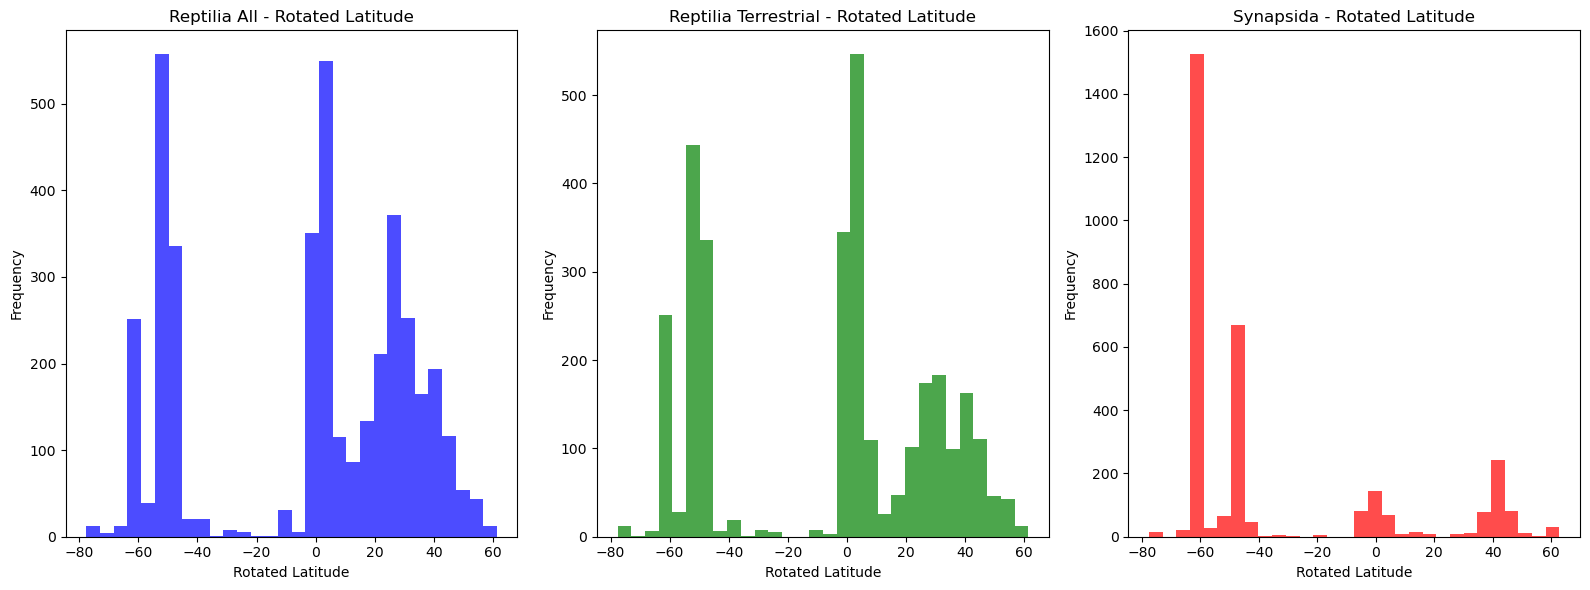

In [105]:
# Visualizing the latitudes now, after having dropped the -9999 values
plt.figure(figsize=(16, 6))
plt.subplot(1, 3, 1)
plt.hist(pt_reptilia_all_filtered_spellchecked_lats_dropped['Rotated latitude'], bins=30, color='blue', alpha=0.7)
plt.title('Reptilia All - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 2)    
plt.hist(pt_reptilia_terr_filtered_spellchecked_lats_dropped['Rotated latitude'], bins=30, color='green', alpha=0.7)
plt.title('Reptilia Terrestrial - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 3)
plt.hist(pt_synapsida_filtered_spellchecked_lats_dropped['Rotated latitude'], bins=30, color='red', alpha=0.7)
plt.title('Synapsida - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Perm-Trias/pt_data_visualizations/occs_latitudes/cleaned_rotated_latitude_histograms.png', dpi=600)
plt.show()

Note that there's another nice latitude distribution visualization in the "DEFUNCT: PT Latitude Binning ("New" Genera) section below.

In [21]:
pt_reptilia_all_filtered_spellchecked_lats_dropped['Rotated latitude'].describe(), pt_reptilia_terr_filtered_spellchecked_lats_dropped['Rotated latitude'].describe(), pt_synapsida_filtered_spellchecked_lats_dropped['Rotated latitude'].describe()

(count    3960.000000
 mean       -3.566211
 std        36.179317
 min       -77.584400
 25%       -46.558590
 50%         1.357201
 75%        27.011270
 max        61.323520
 Name: Rotated latitude, dtype: float64,
 count    3135.000000
 mean       -7.224646
 std        36.588580
 min       -77.584400
 25%       -49.043510
 50%         1.353064
 75%        24.956070
 max        61.323520
 Name: Rotated latitude, dtype: float64,
 count    3181.000000
 mean      -36.313380
 std        37.978068
 min       -77.584400
 25%       -61.365010
 50%       -52.001180
 75%        -2.980824
 max        62.825230
 Name: Rotated latitude, dtype: float64)

In [ ]:
# Save the cleaned dataframes to new csv files
pt_reptilia_all_filtered_spellchecked_lats_dropped.to_csv("Perm-Trias/occs_cleaned/pt_reptilia_all_cleaned.csv", index=False)
pt_reptilia_terr_filtered_spellchecked_lats_dropped.to_csv("Perm-Trias/occs_cleaned/pt_reptilia_terr_cleaned.csv", index=False)
pt_synapsida_filtered_spellchecked_lats_dropped.to_csv("Perm-Trias/occs_cleaned/pt_synapsida_cleaned.csv", index=False)

## Saving PT Occs off as PyRate Input .txts

Saving off data frames up until now, b/c all the rows that need to be dropped have been dropped

In [ ]:
# If you want to read it in instead of running all above again, uncomment the following lines:
# pt_reptilia_all_pyrate_input_txt = pd.read_csv("Perm-Trias/occs_cleaned/pt_reptilia_all_cleaned.csv")
# pt_reptilia_terr_pyrate_input_txt = pd.read_csv("Perm-Trias/occs_cleaned/pt_reptilia_terr_cleaned.csv")
# pt_synapsida_pyrate_input_txt = pd.read_csv("Perm-Trias/occs_cleaned/pt_synapsida_cleaned.csv")

In [213]:
cols_dict = {'genus':'Species', 'age_max':'max_age', 'age_min':'min_age'}

pt_reptilia_all_pyrate_input_txt = pt_reptilia_all_filtered_spellchecked_lats_dropped[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
pt_reptilia_all_pyrate_input_txt['Status'] = "extinct"
# Putting the columns in the right order
pt_reptilia_all_pyrate_input_txt = pt_reptilia_all_pyrate_input_txt[['Species', 'Status', 'min_age', 'max_age']]



pt_reptilia_terr_pyrate_input_txt = pt_reptilia_terr_filtered_spellchecked_lats_dropped[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
pt_reptilia_terr_pyrate_input_txt['Status'] = "extinct"
# Putting the columns in the right order
pt_reptilia_terr_pyrate_input_txt = pt_reptilia_terr_pyrate_input_txt[['Species', 'Status', 'min_age', 'max_age']]



pt_synapsida_pyrate_input_txt = pt_synapsida_filtered_spellchecked_lats_dropped[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
pt_synapsida_pyrate_input_txt['Status'] = "extinct"
# Putting the columns in the right order
pt_synapsida_pyrate_input_txt = pt_synapsida_pyrate_input_txt[['Species', 'Status', 'min_age', 'max_age']]

In [214]:
# Checking that new reptilia dataframes are == to the original minus the number of rows that had -9999 lats (i.e. the rows that were dropped)
pt_reptilia_all_filtered.shape[0] - len(pt_reptilia_9999_lats) == pt_reptilia_all_pyrate_input_txt.shape[0], pt_reptilia_terr_filtered.shape[0] - len(pt_reptilia_terr_9999_lats) == pt_reptilia_terr_pyrate_input_txt.shape[0]


(True, True)

In [215]:
# Synapsida dataset should be = original - the number of rows that had -9999 lats (rows that were dropped) 
# - 1 row that was dropped for having no value in 'genus'

(pt_synapsida_filtered.shape[0] - len(pt_synapsida_9999_lats) - 1) == pt_synapsida_pyrate_input_txt.shape[0]

True

In [216]:
pt_reptilia_all_pyrate_input_txt.isna().sum(), pt_reptilia_terr_pyrate_input_txt.isna().sum(), pt_synapsida_pyrate_input_txt.isna().sum()

(Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64,
 Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64,
 Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64)

In [217]:
pt_reptilia_all_pyrate_input_txt.head(), pt_reptilia_terr_pyrate_input_txt.head(), pt_synapsida_pyrate_input_txt.head()

(          Species   Status  min_age  max_age
 0     Icarosaurus  extinct    208.5    227.0
 1        Rutiodon  extinct    208.5    227.0
 2  Trilophosaurus  extinct    208.5    227.0
 3     Postosuchus  extinct    208.5    227.0
 4     Postosuchus  extinct    208.5    227.0,
       Species   Status  min_age  max_age
 0  Vancleavea  extinct    208.5    227.0
 1  Vancleavea  extinct    208.5    227.0
 2  Vancleavea  extinct    208.5    227.0
 3  Vancleavea  extinct    208.5    227.0
 4  Vancleavea  extinct    208.5    227.0,
         Species   Status  min_age  max_age
 0    Dimetrodon  extinct    286.1    298.9
 1    Ophiacodon  extinct    286.1    298.9
 2   Sphenacodon  extinct    286.1    298.9
 3  Edaphosaurus  extinct    286.1    298.9
 4    Ophiacodon  extinct    286.1    298.9)

In [218]:
# Check data types
print(pt_reptilia_all_pyrate_input_txt.dtypes)
print(pt_reptilia_terr_pyrate_input_txt.dtypes)
print(pt_synapsida_pyrate_input_txt.dtypes)

Species     object
Status      object
min_age    float64
max_age    float64
dtype: object
Species     object
Status      object
min_age    float64
max_age    float64
dtype: object
Species     object
Status      object
min_age    float64
max_age    float64
dtype: object


In [219]:
# Check if min_age is ever greater than max_age
print((pt_reptilia_all_pyrate_input_txt['min_age'] > pt_reptilia_all_pyrate_input_txt['max_age']).any())
print((pt_reptilia_terr_pyrate_input_txt['min_age'] > pt_reptilia_terr_pyrate_input_txt['max_age']).any())
print((pt_synapsida_pyrate_input_txt['min_age'] > pt_synapsida_pyrate_input_txt['max_age']).any())


False
False
False


In [220]:
pt_reptilia_all_pyrate_input_txt.info(), pt_reptilia_terr_pyrate_input_txt.info(), pt_synapsida_pyrate_input_txt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3960 entries, 0 to 3986
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  3960 non-null   object 
 1   Status   3960 non-null   object 
 2   min_age  3960 non-null   float64
 3   max_age  3960 non-null   float64
dtypes: float64(2), object(2)
memory usage: 154.7+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 3135 entries, 0 to 3139
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  3135 non-null   object 
 1   Status   3135 non-null   object 
 2   min_age  3135 non-null   float64
 3   max_age  3135 non-null   float64
dtypes: float64(2), object(2)
memory usage: 122.5+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 3181 entries, 0 to 3184
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  3181 non-null   object 
 1   Status   3181 

(None, None, None)

In [221]:
# Saving all off as .txt's
pt_reptilia_all_pyrate_input_txt.to_csv("Perm-Trias/pt_reptilia_all_pyrate_input_txt.txt", sep="\t", index=False)
pt_reptilia_terr_pyrate_input_txt.to_csv("Perm-Trias/pt_reptilia_terr_pyrate_input_txt.txt", sep="\t", index=False)
pt_synapsida_pyrate_input_txt.to_csv("Perm-Trias/pt_synapsida_pyrate_input_txt.txt", sep="\t", index=False)


## DEFUNCT/DO NOT RUN: PT Latitude Binning ("New" Genera)

### UPDATE: We've decided on a different method of taking into account wide-ranging species with large latitudinal ranges. See the sections on creating the BDNN trait file. HOWEVER, there is a **LATITUDINAL RANGE VISUALIZATION** in this section that is useful. Saved off in the pt_data_visuzliations section


I need species-specific trait files, one value per species. However, latitude can range widely within one species, which means averaging latitudes into one value for one species misrepresents the actual geographic distribution of that species. 

I'll need to check the range of latitudes per species, then for species that have a lot of variance in latitudes, I will separate that species into artificial "new" species delineated based off of its latitudinal range, which we have chosen to be 20 degrees

Previous runs done in the "old_occurrence_analyses" folder used the following geological latitude bins:

Latitudinal Bins:
- Arctic Circle: 66 deg 33 mins
- Tropic of Cancer: 23 deg 26 mins
- equator: 0
- Tropic of Capricorn: -23 deg 36 min
- Antarctic Circle: -66 deg 33 min


If 'Rotated Lat' 
- is >66 = Arctic 
- <= 66 & > 23 = Temperate_N
- <= 23 & >= -23 = Tropics
- < -23 & <= -66 = Temperate_S
- < -66 = Antarctic


However, using these lat ranges, there will still be genera whose lat ranges are significantly large (>40 degrees), which still means reducing latitude data to a very coarse resolution, obscuring the effect of latitude as a predictor. 

Below I explore different methods of latitude binning

In [ ]:
# #If you want to read it in instead of running all above again, uncomment the following lines:
# pt_reptilia_all_filtered_spellchecked_lats_dropped = pd.read_csv("Perm-Trias/occs_cleaned/pt_reptilia_all_cleaned.csv")
# pt_reptilia_terr_filtered_spellchecked_lats_dropped = pd.read_csv("Perm-Trias/occs_cleaned/pt_reptilia_terr_cleaned.csv")
# pt_synapsida_filtered_spellchecked_lats_dropped = pd.read_csv("Perm-Trias/occs_cleaned/pt_synapsida_cleaned.csv")

In [ ]:
# pt_reptilia_all_filtered_spellchecked_lats_dropped['Rotated latitude'].describe(), pt_reptilia_terr_filtered_spellchecked_lats_dropped['Rotated latitude'].describe(), pt_synapsida_filtered_spellchecked_lats_dropped['Rotated latitude'].describe()

(count    3960.000000
 mean       -3.566211
 std        36.179317
 min       -77.584400
 25%       -46.558590
 50%         1.357201
 75%        27.011270
 max        61.323520
 Name: Rotated latitude, dtype: float64,
 count    3135.000000
 mean       -7.224646
 std        36.588580
 min       -77.584400
 25%       -49.043510
 50%         1.353064
 75%        24.956070
 max        61.323520
 Name: Rotated latitude, dtype: float64,
 count    3181.000000
 mean      -36.313380
 std        37.978068
 min       -77.584400
 25%       -61.365010
 50%       -52.001180
 75%        -2.980824
 max        62.825230
 Name: Rotated latitude, dtype: float64)

<!-- In all clades/datasets, "Rotated latitude" values span from a minimum of -77.584400 to a maximum of 62.825230 -->

In [ ]:
# 62.825230 - -77.584400

140.40963

In [ ]:
# # Checking latitudinal ranges
# # Group by genus, then calculate the min, max, and range of latitudes

# def check_latitudinal_ranges(df, name):
#     lat_ranges = df.groupby('genus')['Rotated latitude'].agg(['min', 'max'])
#     lat_ranges['range'] = lat_ranges['max'] - lat_ranges['min']
#     print(f"Latitudinal ranges for {name}:")
#     print(lat_ranges.sort_values(by='range', ascending=False))
#     print("\n")
#     print("Stats for latitudinal ranges:")
#     print(lat_ranges.describe())
#     return lat_ranges  

# pt_reptilia_all_lat_ranges = check_latitudinal_ranges(pt_reptilia_all_filtered_spellchecked_lats_dropped, 'pt_reptilia_all')
# pt_reptilia_terr_lat_ranges = check_latitudinal_ranges(pt_reptilia_terr_filtered_spellchecked_lats_dropped, 'pt_reptilia_terr')
# pt_synapsida_lat_ranges = check_latitudinal_ranges(pt_synapsida_filtered_spellchecked_lats_dropped, 'pt_synapsida')


Latitudinal ranges for pt_reptilia_all:
                          min        max       range
genus                                               
Proterosuchus       -62.64909  61.217590  123.866680
Plateosaurus        -65.49458  45.574810  111.069390
Garjainia           -60.68525  48.313280  108.998530
Clevosaurus         -49.47713  52.141190  101.618320
Palacrodon          -77.58440   1.353064   78.937464
...                       ...        ...         ...
Honghesaurus         12.57983  12.579830    0.000000
Hispaniasaurus       10.40624  10.406240    0.000000
Himalayasaurus      -20.44913 -20.449130    0.000000
Heteropelta          26.05520  26.055200    0.000000
new Rhynchocephalia -46.11636 -46.116360    0.000000

[682 rows x 3 columns]


Stats for latitudinal ranges:
              min         max       range
count  682.000000  682.000000  682.000000
mean    -0.589981    3.884420    4.474401
std     36.624130   36.989144   13.293794
min    -77.584400  -76.624660    0.000000
25%  

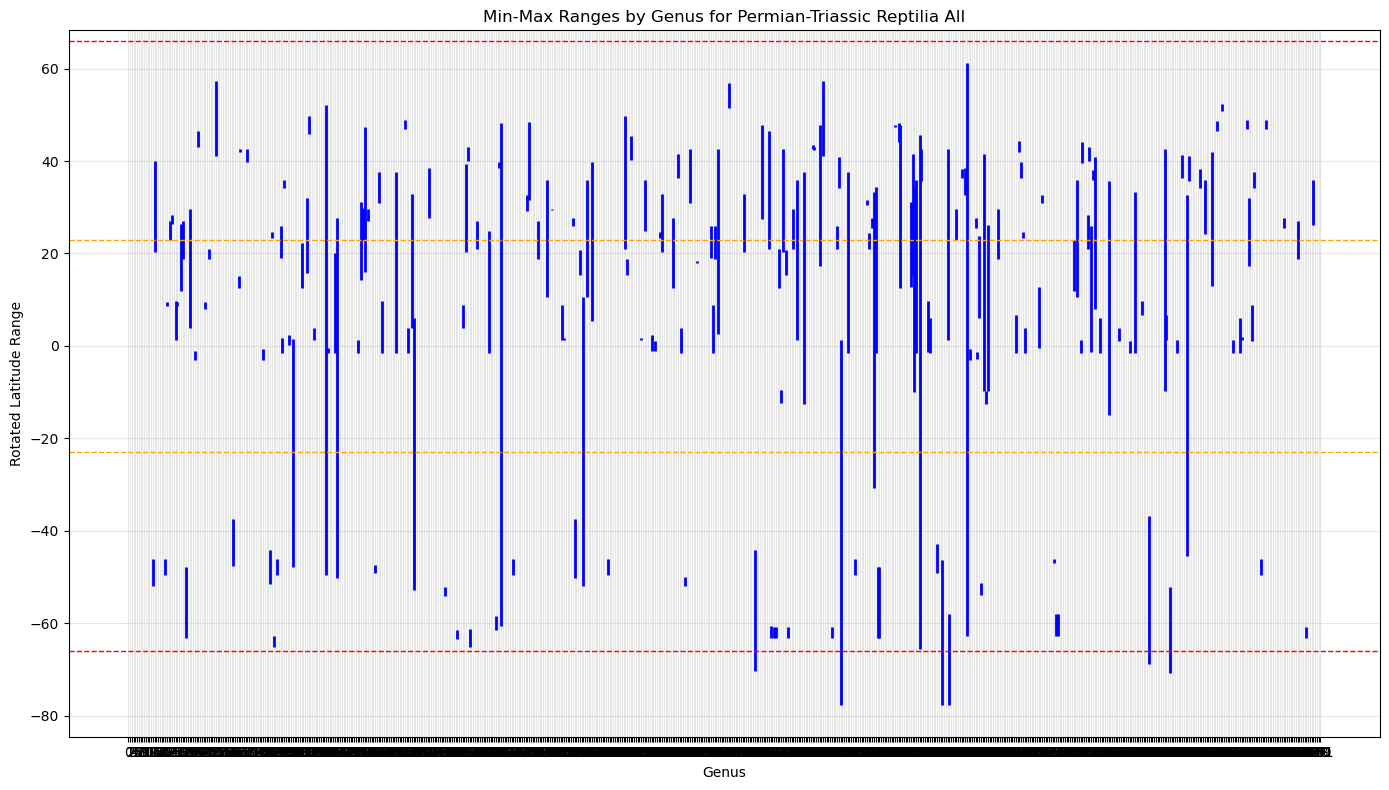

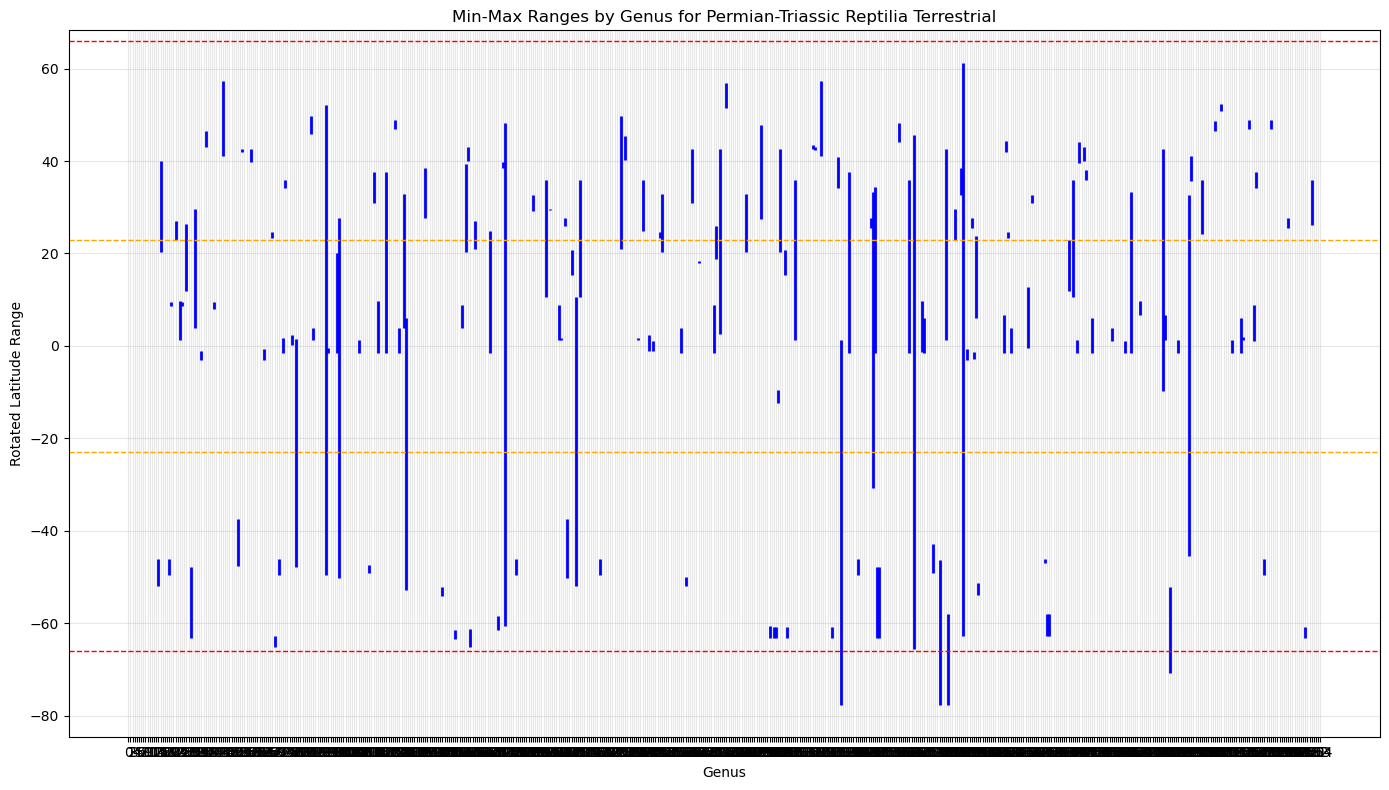

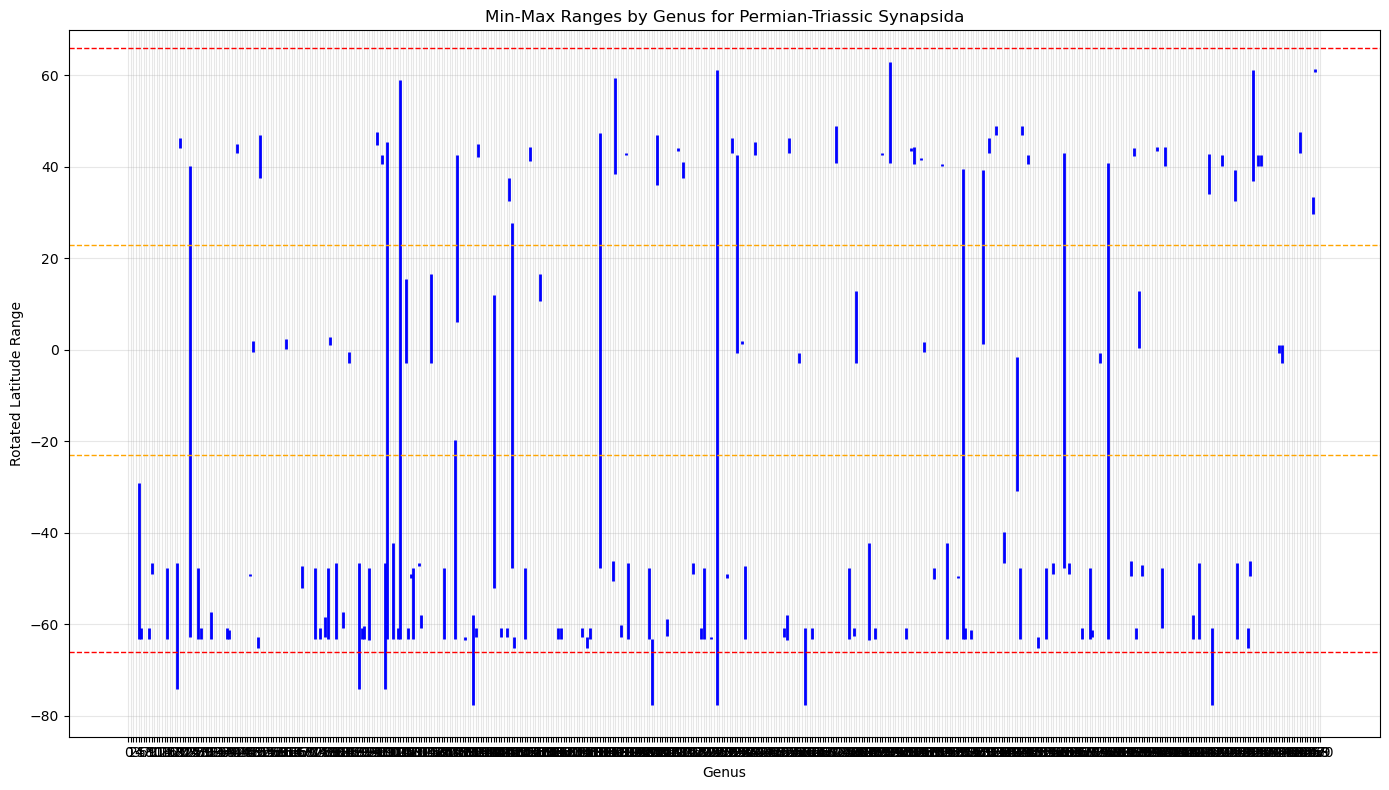

In [102]:
# def plot_genus_ranges_vlines(df, df_name):
#     """Plot vertical lines using matplotlib's vlines function"""
#     fig, ax = plt.subplots(figsize=(14, 8))
    
#     # Get x positions (0, 1, 2, ... for each genus)
#     x_positions = range(len(df))
    
#     # Plot vertical lines from min to max for each genus
#     for i, (genus, row) in enumerate(df.iterrows()):
#         ax.vlines(x=i, ymin=row['min'], ymax=row['max'], 
#                  colors='blue', linewidth=2)
    
#     # Set x-axis labels to genus names
#     ax.set_xticks(x_positions)
#     # ax.set_xticklabels(df.index, rotation=45, ha='right')

#     # Set horizontal lines at y = 66, y = 23, y = -23. y = -66
#     ax.axhline(y=66, color='red', linestyle='--', linewidth=1)
#     ax.axhline(y=23, color='orange', linestyle='--', linewidth=1)
#     ax.axhline(y=-23, color='orange', linestyle='--', linewidth=1)
#     ax.axhline(y=-66, color='red', linestyle='--', linewidth=1)
    
#     # Labels and title
#     ax.set_xlabel('Genus')
#     ax.set_ylabel('Rotated Latitude Range')
#     ax.set_title(f'Min-Max Ranges by Genus for {df_name}')
#     ax.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.savefig(f"Perm-Trias/pt_data_visualizations/occs_latitudes/{df_name}_lat_ranges_vlines.png", dpi=600)
#     plt.show()

# plot_genus_ranges_vlines(pt_reptilia_all_lat_ranges, 'Permian-Triassic Reptilia All')
# plot_genus_ranges_vlines(pt_reptilia_terr_lat_ranges, 'Permian-Triassic Reptilia Terrestrial')
# plot_genus_ranges_vlines(pt_synapsida_lat_ranges, 'Permian-Triassic Synapsida')




In [ ]:
# pt_reptilia_all_lat_ranges['range'].describe(), pt_reptilia_terr_lat_ranges['range'].describe(), pt_synapsida_lat_ranges['range'].describe()

(count    682.000000
 mean       4.474401
 std       13.293794
 min        0.000000
 25%        0.000000
 50%        0.000000
 75%        2.191812
 max      123.866680
 Name: range, dtype: float64,
 count    555.000000
 mean       4.036313
 std       13.522209
 min        0.000000
 25%        0.000000
 50%        0.000000
 75%        1.708547
 max      123.866680
 Name: range, dtype: float64,
 count    461.000000
 mean       4.733017
 std       15.930623
 min        0.000000
 25%        0.000000
 50%        0.000000
 75%        2.308690
 max      138.801990
 Name: range, dtype: float64)

<!-- Trying to ID outliers that might need lat binning via the 1.5IQR rule, for pt_reptilia_all (as a case study). Discovered that using that rule there are a ton more "outliers" than the arbitrary 20 degree lat range we used earlier -->

In [ ]:
# series = pt_reptilia_all_lat_ranges['range']
# q1 = series.quantile(0.25)
# q3 = series.quantile(0.75)
# iqr = q3 - q1
# lower_bound = q1 - 1.5 * iqr
# upper_bound = q3 + 1.5 * iqr
# outliers_pt_reptilia_all_lat_ranges = series[(series < lower_bound) | (series > upper_bound)]
# outliers_pt_reptilia_all_lat_ranges.sort_values(ascending=False)

genus
Proterosuchus       123.866680
Plateosaurus        111.069390
Garjainia           108.998530
Clevosaurus         101.618320
Palacrodon           78.937464
                       ...    
Protanystropheus      6.580790
Prestosuchus          6.239960
Eusaurosphargis       6.130070
Aetosauroides         5.884820
Proterochersis        5.796720
Name: range, Length: 106, dtype: float64

In [ ]:
# pt_reptilia_all_filtered_spellchecked_lats_dropped[pt_reptilia_all_filtered_spellchecked_lats_dropped['genus'] == 'Proterochersis']

,id,occurrence_no,occurrence_no_AF,Rotated latitude,genus,age_max,age_min,Epoch,range
676,3817,1099834,1099834,34.47747,Proterochersis,227.0,208.5,Late Triassic,"(227.0, 208.5)"
677,3818,1099923,1099923,32.59323,Proterochersis,227.0,208.5,Late Triassic,"(227.0, 208.5)"
678,3819,1099924,1099924,34.47747,Proterochersis,227.0,208.5,Late Triassic,"(227.0, 208.5)"
709,3850,1334449,1334449,34.47747,Proterochersis,227.0,208.5,Late Triassic,"(227.0, 208.5)"
787,3928,1554602,1554602,38.38995,Proterochersis,227.0,208.5,Late Triassic,"(227.0, 208.5)"


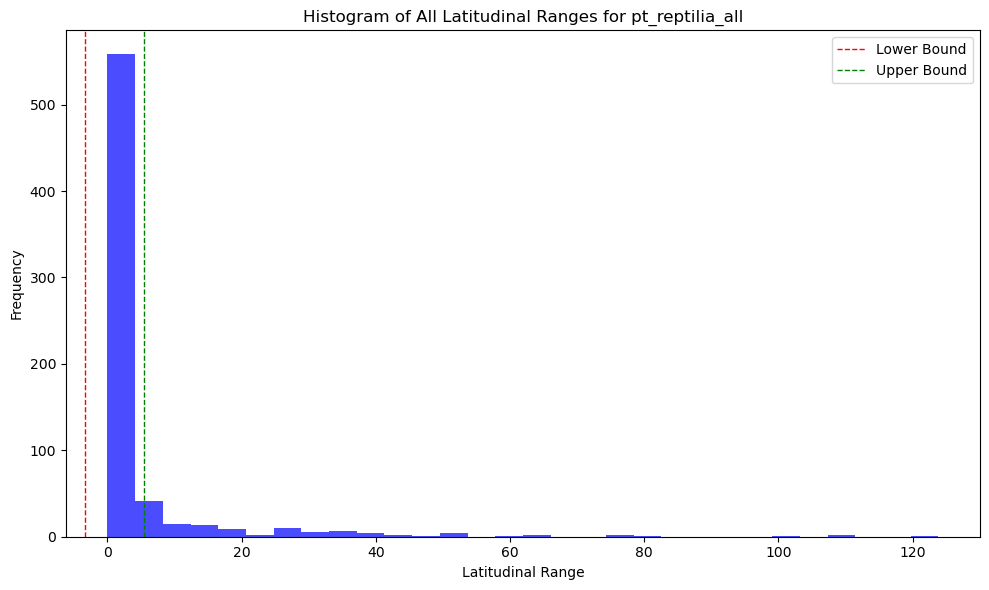

In [ ]:
# # Plot histogram of latitudinal ranges
# plt.figure(figsize=(10, 6))
# plt.hist(pt_reptilia_all_lat_ranges['range'], bins=30, color='blue', alpha=0.7)
# plt.title('Histogram of All Latitudinal Ranges for pt_reptilia_all')
# plt.xlabel('Latitudinal Range')
# plt.ylabel('Frequency')
# plt.axvline(lower_bound, color='red', linestyle='dashed', linewidth=1, label='Lower Bound')
# plt.axvline(upper_bound, color='green', linestyle='dashed', linewidth=1, label='Upper Bound')
# plt.legend()
# plt.savefig('Perm-Trias/pt_data_visualizations/pt_reptilia_all_lat_ranges_histogram.png')
# plt.tight_layout()
# plt.show()

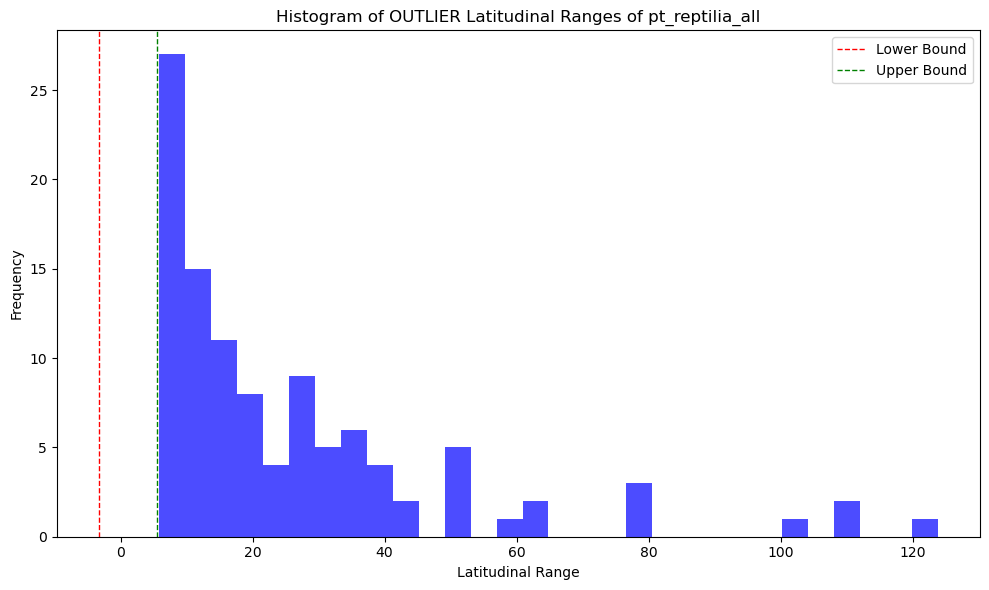

In [ ]:
# # plot histogram of latitudinal ranges of outliers
# outliers_pt_reptilia_all_lat_ranges_df = pt_reptilia_all_lat_ranges[pt_reptilia_all_lat_ranges['range'].isin(outliers_pt_reptilia_all_lat_ranges)]
# plt.figure(figsize=(10, 6))
# plt.hist(outliers_pt_reptilia_all_lat_ranges_df['range'], bins=30, color='blue', alpha=0.7)
# plt.title('Histogram of OUTLIER Latitudinal Ranges of pt_reptilia_all')
# plt.xlabel('Latitudinal Range')
# plt.ylabel('Frequency')
# plt.axvline(lower_bound, color='red', linestyle='dashed', linewidth=1, label='Lower Bound')
# plt.axvline(upper_bound, color='green', linestyle='dashed', linewidth=1, label='Upper Bound')
# plt.legend()
# plt.savefig('Perm-Trias/pt_data_visualizations/outliers_pt_reptilia_all_lat_ranges_histogram.png')
# plt.tight_layout()
# plt.show()

In [ ]:
# # Number of genera with latitudinal ranges > 20 degrees
# len(pt_reptilia_all_lat_ranges[pt_reptilia_all_lat_ranges['range'] > 20].groupby('genus').size().sort_values(ascending=False))

47

In [ ]:
# # Number of genera who are outliers in latitudinal range based on IQR method
# len(outliers_pt_reptilia_all_lat_ranges_df)

106

In [ ]:
# # Use 1.5 IQR to find outliers in latitudinal ranges
# def find_outliers_iqr(series):
#     q1 = series.quantile(0.25)
#     q3 = series.quantile(0.75)
#     iqr = q3 - q1
#     lower_bound = q1 - 1.5 * iqr
#     upper_bound = q3 + 1.5 * iqr
#     outliers = series[(series < lower_bound) | (series > upper_bound)]
#     print(f"Outliers in latitudinal ranges for {series}: {outliers}")
#     return outliers

# pt_reptilia_all_outliers = find_outliers_iqr(pt_reptilia_all_lat_ranges['range'])
# pt_reptilia_terr_outliers = find_outliers_iqr(pt_reptilia_terr_lat_ranges['range'])
# pt_synapsida_outliers = find_outliers_iqr(pt_synapsida_lat_ranges['range'])
# # print("Outliers in latitudinal ranges for pt_reptilia_all:")


Outliers in latitudinal ranges for genus
Abyssomedon            0.00000
Acadiella              0.00000
Acaenasuchus           0.00000
Acallosuchus           0.00000
Acerosodontosaurus     0.00000
                        ...   
Zanclodon              9.85185
Zhongjiania            0.00000
Zupaysaurus            0.00000
new Neotheropoda       0.00000
new Rhynchocephalia    0.00000
Name: range, Length: 682, dtype: float64: genus
Aetosauroides     5.884820
Aetosaurus       19.741860
Angistorhinus     8.357192
Anomoiodon       14.538710
Anshunsaurus      8.228820
                   ...    
Typothorax        7.558767
Utatsusaurus     14.748650
Vancleavea        7.767745
Xinpusaurus       8.228820
Zanclodon         9.851850
Name: range, Length: 106, dtype: float64
Outliers in latitudinal ranges for genus
Abyssomedon            0.00000
Acadiella              0.00000
Acaenasuchus           0.00000
Acallosuchus           0.00000
Acerosodontosaurus     0.00000
                        ...   
Zancl

In [ ]:
# def lat_ranges_over_20(lat_ranges):
#     # Filter for latitudinal ranges greater than 20 degrees and sort by range in descending order
#     lat_ranges_over_20 = lat_ranges[lat_ranges['range'] > 20]
#     lat_ranges_over_20 = lat_ranges_over_20.sort_values(by='range', ascending=False)
#     print(f"Latitudinal ranges over 20 degrees:")
#     print(lat_ranges_over_20)
#     return lat_ranges_over_20

# pt_reptilia_all_lat_ranges_over_20 = lat_ranges_over_20(pt_reptilia_all_lat_ranges)
# pt_reptilia_terr_lat_ranges_over_20 = lat_ranges_over_20(pt_reptilia_terr_lat_ranges)
# pt_synapsida_lat_ranges_over_20 = lat_ranges_over_20(pt_synapsida_lat_ranges)

Latitudinal ranges over 20 degrees:
                          min        max       range
genus                                               
Proterosuchus      -62.649090  61.217590  123.866680
Plateosaurus       -65.494580  45.574810  111.069390
Garjainia          -60.685250  48.313280  108.998530
Clevosaurus        -49.477130  52.141190  101.618320
Palacrodon         -77.584400   1.353064   78.937464
Teratosaurus       -45.494580  32.593230   78.087810
Coelurosauravus    -50.091960  27.634800   77.726760
Parasuchus         -30.814400  33.314900   64.129300
Hyperodapedon      -52.001180  10.587390   62.588570
Dromomeron         -52.854420   6.088668   58.943088
Tanystropheus       -9.650311  42.706720   52.357031
Psephoderma         -9.650311  41.435560   51.085871
Simosaurus         -14.990220  35.783620   50.773840
Nothosaurus        -12.547470  37.625320   50.172790
Captorhinus        -47.784110   1.521104   49.305214
Placodus            -9.895147  34.449210   44.344357
Proganoche

In [ ]:
# # Check that all the genera in pt_reptilia_terr_lat_ranges are also in pt_reptilia_all_lat_ranges
# pt_reptilia_terr_lat_ranges.index.isin(pt_reptilia_all_lat_ranges.index).all()

True

In [ ]:
# # LAT BINNING FUNCTION

# # Loop through rep_bdnn_dropped and re-name the genuses in the rep_lat_range_20 according to their value in the 'Rotated Lat' column
# # which determines which bin they should be in

# def lat_binning(df, lat_range_20_list_genus_list):
#     df_binned = df.copy()
#     for genus in lat_range_20_list_genus_list:
#         if genus in df_binned['genus'].values:
#             df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= 66.5), 'genus'] = genus + '_Arctic'
#             df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= 23.5) & (df_binned['Rotated Lat'] < 66.5), 'genus'] = genus + '_Temperate_N'
#             df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= 0) & (df_binned['Rotated Lat'] < 23.5), 'genus'] = genus + '_Tropical_N'
#             df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= -23.5) & (df_binned['Rotated Lat'] < 0), 'genus'] = genus + '_Tropical_S'
#             df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] >= -66.5) & (df_binned['Rotated Lat'] < -23.5), 'genus'] = genus + '_Temperate_S'
#             df_binned.loc[(df_binned['genus'] == genus) & (df_binned['Rotated Lat'] < -66.5), 'genus'] = genus + '_Antarctic'        
#     return df_binned

In [ ]:
# pt_reptilia_all_binned = lat_binning(pt_reptilia_all_filtered_spellchecked_lats_dropped, pt_reptilia_all_lat_ranges.index.tolist())
# pt_reptilia_terr_binned = lat_binning(pt_reptilia_terr_filtered_spellchecked_lats_dropped, pt_reptilia_terr_lat_ranges.index.tolist())
# pt_synapsida_binned = lat_binning(pt_synapsida_filtered_spellchecked_lats_dropped, pt_synapsida_lat_ranges.index.tolist())

In [ ]:
# # Checking shapes before and after binning, just to make sure we didn't lose any data
# # All values should be the same as before binning
# pt_reptilia_all_filtered_spellchecked_lats_dropped.shape[0], pt_reptilia_all_binned.shape[0], pt_reptilia_terr_filtered_spellchecked_lats_dropped.shape[0], pt_reptilia_terr_binned.shape[0], pt_synapsida_filtered_spellchecked_lats_dropped.shape[0], pt_synapsida_binned.shape[0]

# # Check that the binning worked correctly
# # The new dataframes should have more genera than the original ones
# print("Genera counts:")
# print("Reptilia All Binned:", pt_reptilia_all_binned['genus'].value_counts())
# print("Reptilia All Pre-Binning:", pt_reptilia_all_filtered_spellchecked_lats_dropped['genus'].value_counts())
# print("Reptilia Terrestrial Binned:", pt_reptilia_terr_binned['genus'].value_counts())
# print("Reptilia Terrestrial Pre-Binning:", pt_reptilia_terr_filtered_spellchecked_lats_dropped['genus'].value_counts())
# print("Synapsida Binned:", pt_synapsida_binned['genus'].value_counts())
# print("Synapsida Pre-Binning:", pt_synapsida_filtered_spellchecked_lats_dropped['genus'].value_counts())


In [ ]:
# pd.to_csv(pt_reptilia_all_binned, "Perm-Trias/pt_reptilia_all_lat_binned.csv", index=False)
# pd.to_csv(pt_reptilia_terr_binned, "Perm-Trias/pt_reptilia_terr_lat_binned.csv", index=False)
# pd.to_csv(pt_synapsida_binned, "Perm-Trias/pt_synapsida_lat_binned.csv", index=False)

# Guadalupian-Ladinian Data

In [22]:
gl_reptilia_all = pd.read_csv("Perm-Trias/occs_cleaned/pt_reptilia_all_cleaned.csv")
gl_reptilia_terr = pd.read_csv("Perm-Trias/occs_cleaned/pt_reptilia_terr_cleaned.csv")
gl_synapsida = pd.read_csv("Perm-Trias/occs_cleaned/pt_synapsida_cleaned.csv")

gl_reptilia_all.head(), gl_reptilia_terr.head(), gl_synapsida.head()

(     id occurrence_no occurrence_no_AF  Rotated latitude           genus  \
 0  3141        146084           146084          6.739012     Icarosaurus   
 1  3142        146085           146085          6.739012        Rutiodon   
 2  3143        149845           149845         -1.470099  Trilophosaurus   
 3  3144        149917           149917         -1.470099     Postosuchus   
 4  3145        149917           149917         -1.470099     Postosuchus   
 
    age_max  age_min          Epoch           range  
 0    227.0    208.5  Late Triassic  (227.0, 208.5)  
 1    227.0    208.5  Late Triassic  (227.0, 208.5)  
 2    227.0    208.5  Late Triassic  (227.0, 208.5)  
 3    227.0    208.5  Late Triassic  (227.0, 208.5)  
 4    227.0    208.5  Late Triassic  (227.0, 208.5)  ,
    id occurrence_no occurrence_no_AF  Rotated latitude       genus  age_max  \
 0   1        557171           557171          1.353064  Vancleavea    227.0   
 1   2        812265           812265          3.83

#### Dealing with one 'Epoch' null in Synapsida

As  you'll see there's one row with a null value in "Epoch". However, its age range falls within the Middle and Upper Triassic, it just spans them both, which is probably why there's a null value. This means I can keep it!

In [23]:
gl_reptilia_all.isna().sum(), gl_reptilia_terr.isna().sum(), gl_synapsida.isna().sum()

(id                  0
 occurrence_no       0
 occurrence_no_AF    0
 Rotated latitude    0
 genus               0
 age_max             0
 age_min             0
 Epoch               0
 range               0
 dtype: int64,
 id                  0
 occurrence_no       0
 occurrence_no_AF    0
 Rotated latitude    0
 genus               0
 age_max             0
 age_min             0
 Epoch               0
 range               0
 dtype: int64,
 id                  0
 occurrence_no       0
 occurrence_no_AF    0
 Rotated latitude    0
 genus               0
 age_max             0
 age_min             0
 Epoch               1
 range               0
 dtype: int64)

In [24]:
gl_synapsida[gl_synapsida['Epoch'].isna()]

,id,occurrence_no,occurrence_no_AF,Rotated latitude,genus,age_max,age_min,Epoch,range
2384,9515,1418754,1418754,-61.37537,Bauria,249.9,242.0,NaN,"(249.9, 242.0)"


In [25]:
gl_synapsida[gl_synapsida['genus'] == 'Bauria']

,id,occurrence_no,occurrence_no_AF,Rotated latitude,genus,age_max,age_min,Epoch,range
2384,9515,1418754,1418754,-61.37537,Bauria,249.9,242.0,NaN,"(249.9, 242.0)"
2446,9578,1418755,1418755,-61.37537,Bauria,246.7,242.0,Middle Triassic,"(246.7, 242.0)"
2465,9597,1332743,1332743,-63.33496,Bauria,246.7,242.0,Middle Triassic,"(246.7, 242.0)"
2517,9649,986757,986757,-61.37537,Bauria,246.7,242.0,Middle Triassic,"(246.7, 242.0)"
2527,9659,923778,923778,-63.33496,Bauria,246.7,242.0,Middle Triassic,"(246.7, 242.0)"
2556,9688,906810,906810,-63.33496,Bauria,246.7,242.0,Middle Triassic,"(246.7, 242.0)"
2558,9690,906808,906808,-61.37537,Bauria,246.7,242.0,Middle Triassic,"(246.7, 242.0)"
2559,9691,906802,906802,-61.37537,Bauria,246.7,242.0,Middle Triassic,"(246.7, 242.0)"
2560,9692,906799,906799,-63.33496,Bauria,246.7,242.0,Middle Triassic,"(246.7, 242.0)"
2561,9693,906797,906797,-61.37537,Bauria,246.7,242.0,Middle Triassic,"(246.7, 242.0)"


In [26]:
# We want to filter for rows that contain only certain values in the "Epoch" column

epochs = ['Guadalupian', 'Lopingian', 'Early Triassic', 'Middle Triassic']

gl_reptilia_all_epochs = gl_reptilia_all[gl_reptilia_all['Epoch'].isin(epochs)]
gl_reptilia_terr_epochs = gl_reptilia_terr[gl_reptilia_terr['Epoch'].isin(epochs)]
gl_synapsida_epochs = gl_synapsida[gl_synapsida['Epoch'].isin(epochs)]


gl_reptilia_all.shape[0], gl_reptilia_all_epochs.shape[0], gl_reptilia_terr.shape[0], gl_reptilia_terr_epochs.shape[0], gl_synapsida.shape[0], gl_synapsida_epochs.shape[0]    


(3960, 1850, 3135, 1343, 3181, 2571)

In [27]:
# Append one row from gl_synapsida to gl_synapsida_epochs
null_row = gl_synapsida.iloc[2384].copy()
gl_synapsida_epochs = pd.concat([gl_synapsida_epochs, null_row.to_frame().T], ignore_index=True)
gl_synapsida_epochs.shape[0], gl_synapsida_epochs.isna().sum(), gl_synapsida_epochs[gl_synapsida_epochs['genus'] == "Bauria"]

(2572,
 id                  0
 occurrence_no       0
 occurrence_no_AF    0
 Rotated latitude    0
 genus               0
 age_max             0
 age_min             0
 Epoch               1
 range               0
 dtype: int64,
         id occurrence_no occurrence_no_AF Rotated latitude   genus age_max  \
 2164  9578       1418755          1418755        -61.37537  Bauria   246.7   
 2183  9597       1332743          1332743        -63.33496  Bauria   246.7   
 2235  9649        986757           986757        -61.37537  Bauria   246.7   
 2245  9659        923778           923778        -63.33496  Bauria   246.7   
 2274  9688        906810           906810        -63.33496  Bauria   246.7   
 2276  9690        906808           906808        -61.37537  Bauria   246.7   
 2277  9691        906802           906802        -61.37537  Bauria   246.7   
 2278  9692        906799           906799        -63.33496  Bauria   246.7   
 2279  9693        906797           906797        -61.37537 

In [28]:
gl_reptilia_all_epochs['Epoch'].value_counts(), gl_reptilia_terr_epochs['Epoch'].value_counts(), gl_synapsida_epochs['Epoch'].value_counts()

(Epoch
 Middle Triassic    929
 Lopingian          485
 Early Triassic     267
 Guadalupian        169
 Name: count, dtype: int64,
 Epoch
 Lopingian          485
 Middle Triassic    468
 Early Triassic     221
 Guadalupian        169
 Name: count, dtype: int64,
 Epoch
 Lopingian          1245
 Guadalupian         596
 Middle Triassic     450
 Early Triassic      280
 Name: count, dtype: int64)

### Latitude Visualizations

Latitudinal ranges for gl_reptilia_all:
                       min        max       range
genus                                            
Proterosuchus   -62.649090  61.217590  123.866680
Garjainia       -60.685250  48.313280  108.998530
Coelurosauravus -50.091960  27.634800   77.726760
Teratosaurus    -45.494580  26.462570   71.957150
Placodus         -9.895147  34.449210   44.344357
...                    ...        ...         ...
Jesairosaurus    -3.863414  -3.863414    0.000000
Jushatyria       46.885000  46.885000    0.000000
Kadimakara      -54.016000 -54.016000    0.000000
Kahneria          1.681402   1.681402    0.000000
Zhongjiania      32.583710  32.583710    0.000000

[335 rows x 3 columns]


Stats for latitudinal ranges:
              min         max       range
count  335.000000  335.000000  335.000000
mean    -1.096047    2.991380    4.087427
std     40.406620   40.690223   12.874720
min    -77.584400  -76.624660    0.000000
25%    -47.784110  -46.558590    0.000000
50

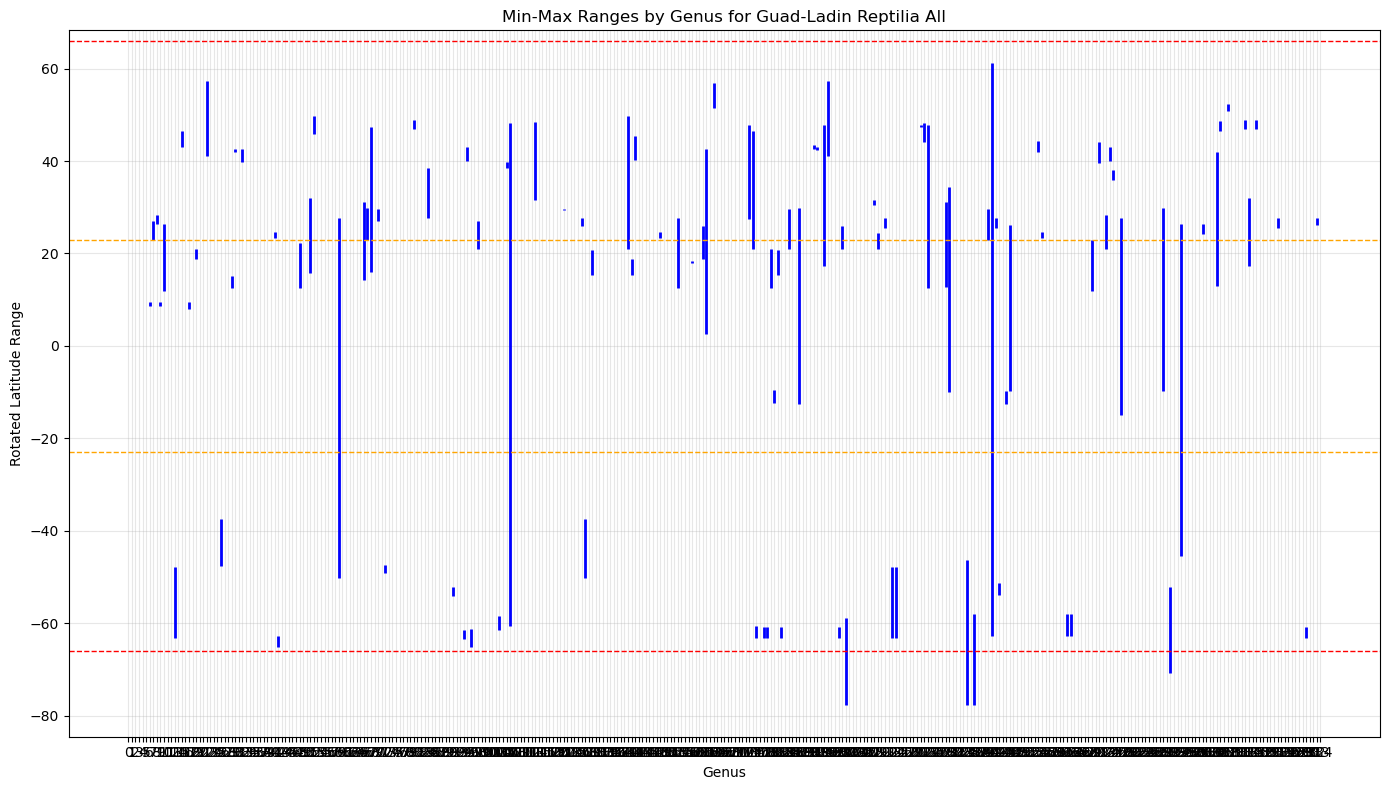

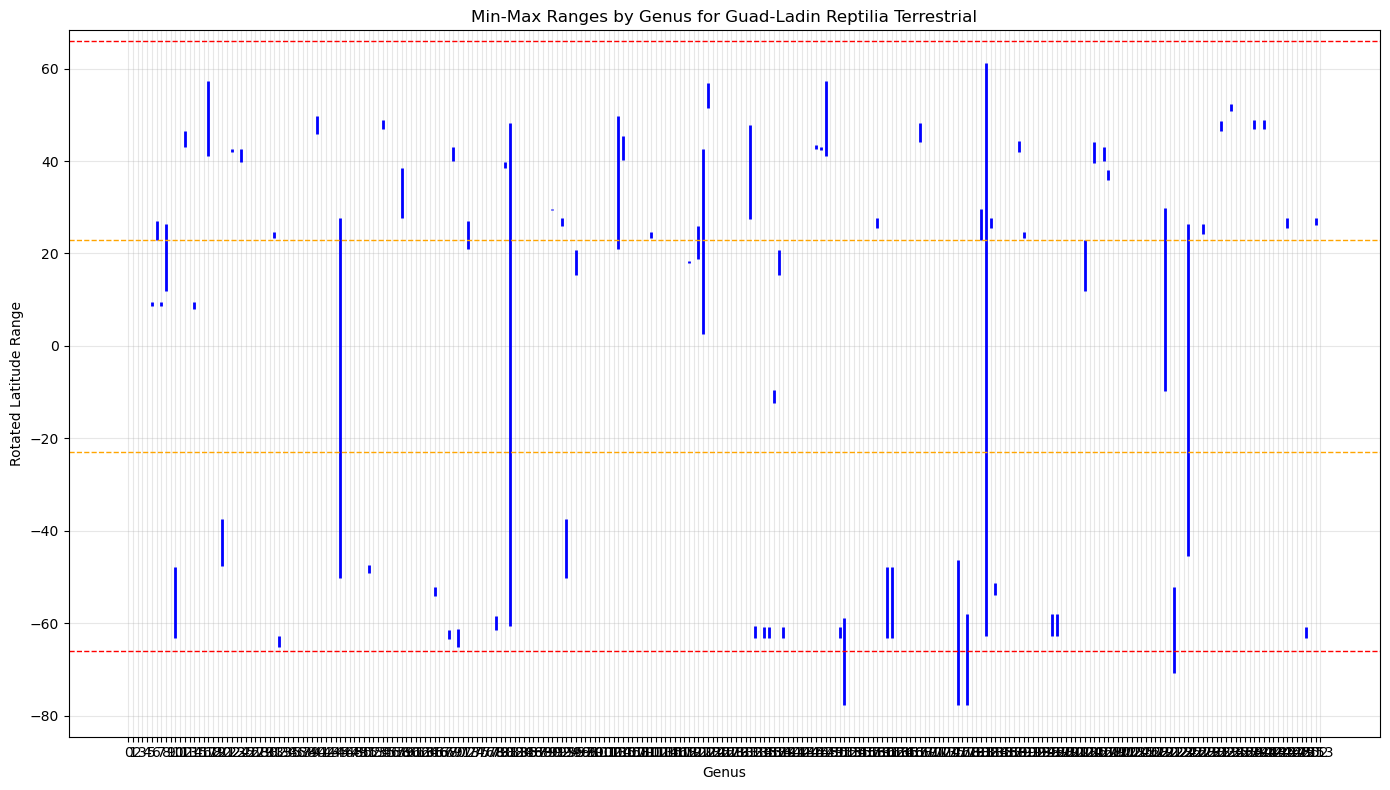

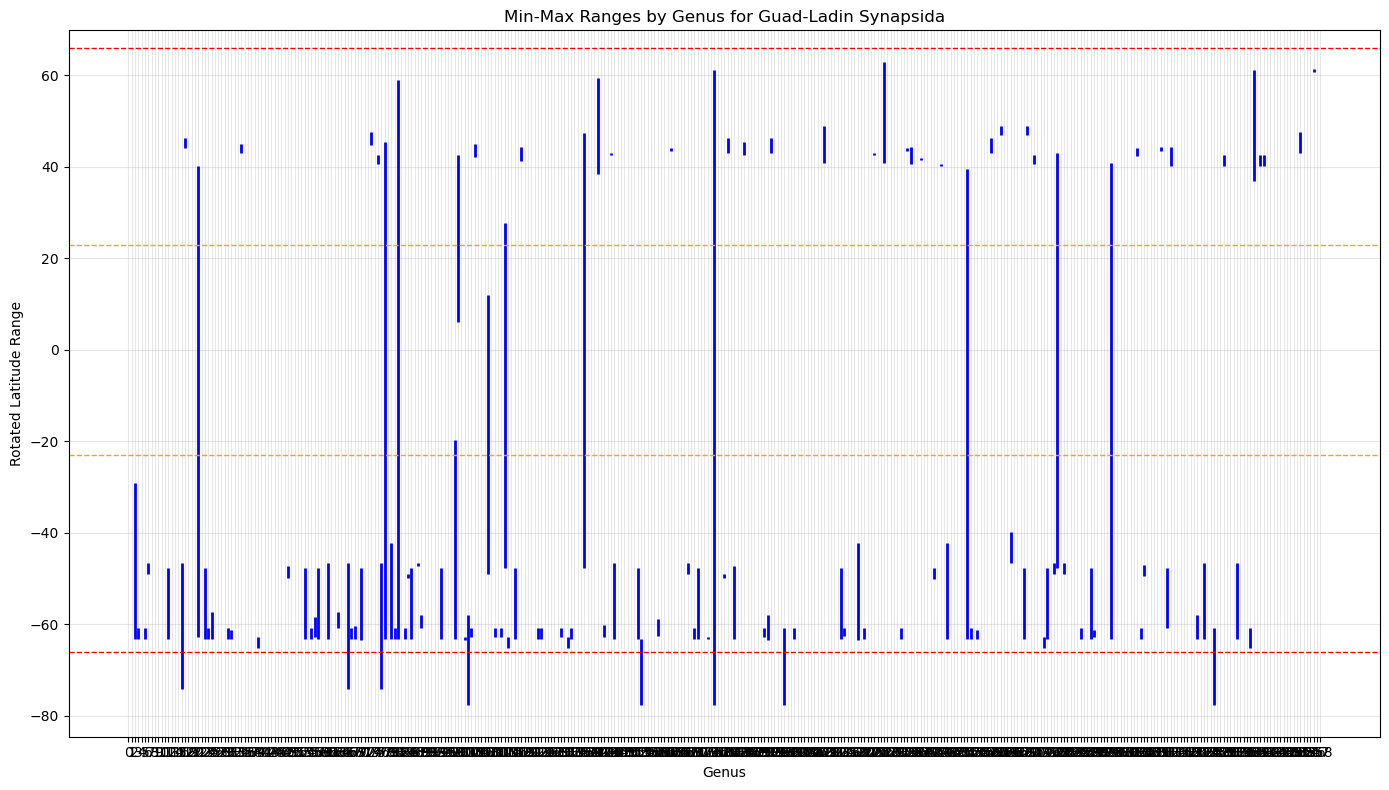

In [247]:
# this function is slightly edited from the DEFUNCT section
def check_latitudinal_ranges(df, name):
    lat_ranges = df.groupby('genus')['Rotated latitude'].agg(['min', 'max'])
    lat_ranges['range'] = lat_ranges['max'] - lat_ranges['min']
    print(f"Latitudinal ranges for {name}:")
    print(lat_ranges.sort_values(by='range', ascending=False))
    print("\n")
    print("Stats for latitudinal ranges:")
    print(lat_ranges.describe())
    return lat_ranges  

gl_reptilia_all_lat_ranges = check_latitudinal_ranges(gl_reptilia_all_epochs, 'gl_reptilia_all')
gl_reptilia_terr_lat_ranges = check_latitudinal_ranges(gl_reptilia_terr_epochs, 'gl_reptilia_terr')
gl_synapsida_lat_ranges = check_latitudinal_ranges(gl_synapsida_epochs, 'gl_synapsida')


def plot_genus_ranges_vlines(df, df_name):
    """Plot vertical lines using matplotlib's vlines function"""
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Get x positions (0, 1, 2, ... for each genus)
    x_positions = range(len(df))
    
    # Plot vertical lines from min to max for each genus
    for i, (genus, row) in enumerate(df.iterrows()):
        ax.vlines(x=i, ymin=row['min'], ymax=row['max'], 
                 colors='blue', linewidth=2)
    
    # Set x-axis labels to genus names
    ax.set_xticks(x_positions)
    # ax.set_xticklabels(df.index, rotation=45, ha='right')

    # Set horizontal lines at y = 66, y = 23, y = -23. y = -66
    ax.axhline(y=66, color='red', linestyle='--', linewidth=1)
    ax.axhline(y=23, color='orange', linestyle='--', linewidth=1)
    ax.axhline(y=-23, color='orange', linestyle='--', linewidth=1)
    ax.axhline(y=-66, color='red', linestyle='--', linewidth=1)
    
    # Labels and title
    ax.set_xlabel('Genus')
    ax.set_ylabel('Rotated Latitude Range')
    ax.set_title(f'Min-Max Ranges by Genus for {df_name}')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"Guad-Ladin/gl_data_visualizations/{df_name}_lat_ranges_vlines.png", dpi=600)
    plt.show()
    
plot_genus_ranges_vlines(gl_reptilia_all_lat_ranges, 'Guad-Ladin Reptilia All')
plot_genus_ranges_vlines(gl_reptilia_terr_lat_ranges, 'Guad-Ladin Reptilia Terrestrial')
plot_genus_ranges_vlines(gl_synapsida_lat_ranges, 'Guad-Ladin Synapsida')

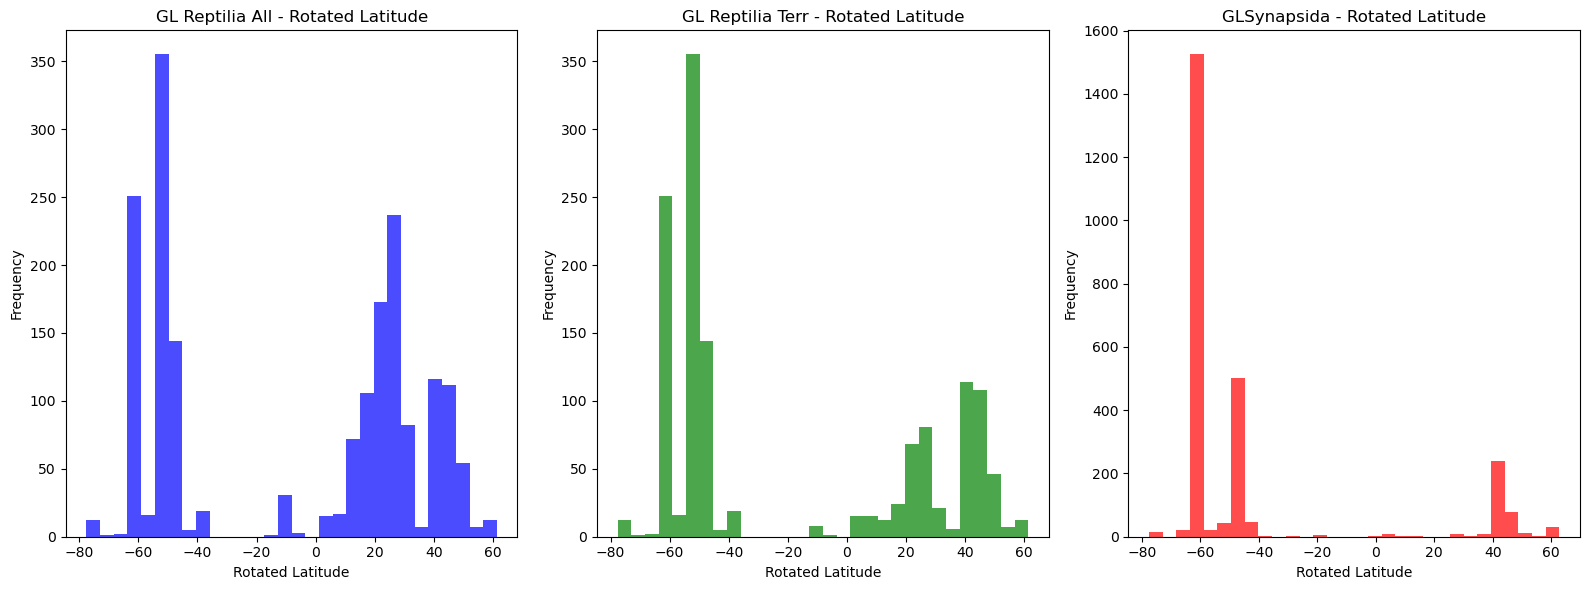

In [103]:
# Visualizing the latitudes
plt.figure(figsize=(16, 6))
plt.subplot(1, 3, 1)
plt.hist(gl_reptilia_all_epochs['Rotated latitude'], bins=30, color='blue', alpha=0.7)
plt.title('GL Reptilia All - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 2)
plt.hist(gl_reptilia_terr_epochs['Rotated latitude'], bins=30, color='green', alpha=0.7)
plt.title('GL Reptilia Terr - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.subplot(1, 3, 3)    
plt.hist(gl_synapsida_epochs['Rotated latitude'], bins=30, color='red', alpha=0.7)
plt.title('GLSynapsida - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Guad-Ladin/gl_data_visualizations/cleaned_rotated_latitude_histograms.pdf')
plt.show()

## Saving GT Occs off as PyRate Input .txts

In [370]:
# First saving off all cols as a cleaned dataset in case we need it later
gl_reptilia_all_epochs.to_csv("Guad-Ladin/occs_cleaned/gl_reptilia_all_cleaned.csv", index=False)
gl_reptilia_terr_epochs.to_csv("Guad-Ladin/occs_cleaned/gl_reptilia_terr_cleaned.csv", index=False)
gl_synapsida_epochs.to_csv("Guad-Ladin/occs_cleaned/gl_synapsida_cleaned.csv", index=False)


In [185]:
# Filter to columns

cols_dict = {'genus':'Species', 'age_max':'max_age', 'age_min':'min_age'}

gl_reptilia_all_epochs_filtered = gl_reptilia_all_epochs[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
gl_reptilia_all_epochs_filtered['Status'] = "extinct"
# Putting the columns in the right order
gl_reptilia_all_epochs_filtered = gl_reptilia_all_epochs_filtered[['Species', 'Status', 'min_age', 'max_age']]


gl_reptilia_terr_epochs_filtered = gl_reptilia_terr_epochs[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
gl_reptilia_terr_epochs_filtered['Status'] = "extinct"
# Putting the columns in the right order
gl_reptilia_terr_epochs_filtered = gl_reptilia_terr_epochs_filtered[['Species', 'Status', 'min_age', 'max_age']]

gl_synapsida_epochs_filtered = gl_synapsida_epochs[['genus', 'age_max', 'age_min']].rename(columns=cols_dict)
gl_synapsida_epochs_filtered['Status'] = "extinct"
# Putting the columns in the right order
gl_synapsida_epochs_filtered = gl_synapsida_epochs_filtered[['Species', 'Status', 'min_age', 'max_age']]

In [186]:
gl_reptilia_all_epochs_filtered.shape[0], gl_reptilia_terr_epochs_filtered.shape[0], gl_synapsida_epochs_filtered.shape[0]

(1850, 1343, 2572)

In [187]:
gl_reptilia_all_epochs_filtered.head(), gl_reptilia_terr_epochs_filtered.head(), gl_synapsida_epochs_filtered.head()

(              Species   Status  min_age  max_age
 1065   Neusticosaurus  extinct    237.0    246.7
 1066       Mixosaurus  extinct    237.0    246.7
 1067    Omphalosaurus  extinct    237.0    246.7
 1068    Omphalosaurus  extinct    237.0    246.7
 1069  Barracudasaurus  extinct    237.0    246.7,
            Species   Status  min_age  max_age
 1056  Rhombopholis  extinct    237.0    246.7
 1057    Langeronyx  extinct    237.0    246.7
 1058  Teratosaurus  extinct    237.0    246.7
 1059   Macrocnemus  extinct    237.0    246.7
 1060   Macrocnemus  extinct    237.0    246.7,
            Species   Status min_age max_age
 0  Parabradysaurus  extinct   266.9   276.5
 1  Parabradysaurus  extinct   266.9   276.5
 2       Kamagorgon  extinct   266.9   276.5
 3       Kamagorgon  extinct   266.9   276.5
 4      Microsyodon  extinct   266.9   276.5)

In [189]:
gl_reptilia_all_epochs_filtered.info(), gl_reptilia_terr_epochs_filtered.info(), gl_synapsida_epochs_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1850 entries, 1065 to 3959
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  1850 non-null   object 
 1   Status   1850 non-null   object 
 2   min_age  1850 non-null   float64
 3   max_age  1850 non-null   float64
dtypes: float64(2), object(2)
memory usage: 72.3+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 1343 entries, 1056 to 3134
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  1343 non-null   object 
 1   Status   1343 non-null   object 
 2   min_age  1343 non-null   float64
 3   max_age  1343 non-null   float64
dtypes: float64(2), object(2)
memory usage: 52.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2572 entries, 0 to 2571
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Species  2572 non-null   object
 1   Status  

(None, None, None)

In [188]:
gl_reptilia_all_epochs_filtered.describe(), gl_reptilia_terr_epochs_filtered.describe(), gl_synapsida_epochs_filtered.describe()

(           min_age      max_age
 count  1850.000000  1850.000000
 mean    246.079546   251.628532
 std       7.438206     8.127753
 min     237.000000   239.700000
 25%     239.700000   246.700000
 50%     245.100000   251.200000
 75%     251.902000   259.510000
 max     266.900000   274.400000,
            min_age      max_age
 count  1343.000000  1343.000000
 mean    248.411958   254.184648
 std       7.229062     7.934083
 min     237.000000   239.700000
 25%     242.000000   246.700000
 50%     251.200000   251.902000
 75%     251.902000   259.510000
 max     266.900000   274.400000,
           Species   Status  min_age  max_age
 count        2572     2572  2572.00  2572.00
 unique        359        1    13.00    13.00
 top     Diictodon  extinct   254.14   259.51
 freq          182     2572   893.00  1223.00)

In [191]:
gl_reptilia_all_epochs_filtered.isna().sum(), gl_reptilia_terr_epochs_filtered.isna().sum(), gl_synapsida_epochs_filtered.isna().sum()

(Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64,
 Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64,
 Species    0
 Status     0
 min_age    0
 max_age    0
 dtype: int64)

In [192]:
# Saving them off as .txt's
gl_reptilia_all_epochs_filtered.to_csv("Guad-Ladin/gl_reptilia_all_epochs_filtered.txt", sep="\t", index=False)
gl_reptilia_terr_epochs_filtered.to_csv("Guad-Ladin/gl_reptilia_terr_epochs_filtered.txt", sep="\t", index=False)
gl_synapsida_epochs_filtered.to_csv("Guad-Ladin/gl_synapsida_epochs_filtered.txt", sep="\t", index=False)

## Ages Visualization (Range Plots)

In [ ]:
gl_rep_terr_range_plot = range_plot(gl_reptilia_terr_epochs_filtered, 'gl_reptilia_terr_epochs_filtered', age_max_col = 'max_age', age_min_col = 'min_age')
gl_rep_terr_range_plot.savefig("Guad-Ladin/data_visualizations/gl_reptilia_terr_epochs_filtered_age_range_frequency_plot.png", dpi=600)

gl_synapsida_range_plot = range_plot(gl_synapsida_epochs_filtered, 'gl_synapsida_epochs_filtered', age_max_col = 'max_age', age_min_col = 'min_age')
gl_synapsida_range_plot.savefig("Guad-Ladin/data_visualizations/gl_synapsida_epochs_filtered_age_range_frequency_plot.png", dpi=600)


NameError: name 'range_plot' is not defined

# Predictor Files

## Latitude Data

I'll need:

One row per genus

6 columns:
1. Latitude range for that genus
2. 5 binary flags (1 or 0) for presence in each of the 5 biomes: Arctic (latitude > 66.5), Temperate_North (latitude <= 66.5 and > 23.5), Tropical, Temperate_South, Antarctic




In [32]:
pt_reptilia_all_lats = pd.read_csv("Perm-Trias/occs_cleaned/pt_reptilia_all_cleaned.csv")
pt_reptilia_terr_lats = pd.read_csv("Perm-Trias/occs_cleaned/pt_reptilia_terr_cleaned.csv")
pt_synapsida_lats = pd.read_csv("Perm-Trias/occs_cleaned/pt_synapsida_cleaned.csv")

gl_reptilia_all_lats = pd.read_csv("Guad-Ladin/occs_cleaned/gl_reptilia_all_cleaned.csv")
gl_reptilia_terr_lats = pd.read_csv("Guad-Ladin/occs_cleaned/gl_reptilia_terr_cleaned.csv")
gl_synapsida_lats = pd.read_csv("Guad-Ladin/occs_cleaned/gl_synapsida_cleaned.csv")

pt_reptilia_all_lats.head()


,id,occurrence_no,occurrence_no_AF,Rotated latitude,genus,age_max,age_min,Epoch,range
0,3141,146084,146084,6.739012,Icarosaurus,227.0,208.5,Late Triassic,"(227.0, 208.5)"
1,3142,146085,146085,6.739012,Rutiodon,227.0,208.5,Late Triassic,"(227.0, 208.5)"
2,3143,149845,149845,-1.470099,Trilophosaurus,227.0,208.5,Late Triassic,"(227.0, 208.5)"
3,3144,149917,149917,-1.470099,Postosuchus,227.0,208.5,Late Triassic,"(227.0, 208.5)"
4,3145,149917,149917,-1.470099,Postosuchus,227.0,208.5,Late Triassic,"(227.0, 208.5)"


In [33]:
pt_reptilia_all_lats_filtered = pt_reptilia_all_lats[['genus', 'Rotated latitude']]
pt_reptilia_terr_lats_filtered = pt_reptilia_terr_lats[['genus', 'Rotated latitude']]
pt_synapsida_lats_filtered = pt_synapsida_lats[['genus', 'Rotated latitude']]

pt_reptilia_all_lats_filtered.describe(), pt_reptilia_terr_lats_filtered.describe(), pt_synapsida_lats_filtered.describe()

(       Rotated latitude
 count       3960.000000
 mean          -3.566211
 std           36.179317
 min          -77.584400
 25%          -46.558590
 50%            1.357201
 75%           27.011270
 max           61.323520,
        Rotated latitude
 count       3135.000000
 mean          -7.224646
 std           36.588580
 min          -77.584400
 25%          -49.043510
 50%            1.353064
 75%           24.956070
 max           61.323520,
        Rotated latitude
 count       3181.000000
 mean         -36.313380
 std           37.978068
 min          -77.584400
 25%          -61.365010
 50%          -52.001180
 75%           -2.980824
 max           62.825230)

In [34]:
pt_reptilia_all_lats_filtered.info(), pt_reptilia_terr_lats_filtered.info(), pt_synapsida_lats_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   genus             3960 non-null   object 
 1   Rotated latitude  3960 non-null   float64
dtypes: float64(1), object(1)
memory usage: 62.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3135 entries, 0 to 3134
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   genus             3135 non-null   object 
 1   Rotated latitude  3135 non-null   float64
dtypes: float64(1), object(1)
memory usage: 49.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3181 entries, 0 to 3180
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   genus             3181 non-null   object 
 1   Rotated latitude  3181 non-null   float64
dtypes: floa

(None, None, None)

In [35]:
gl_reptilia_all_lats_filtered = gl_reptilia_all_lats[['genus', 'Rotated latitude']]
gl_reptilia_terr_lats_filtered = gl_reptilia_terr_lats[['genus', 'Rotated latitude']]   
gl_synapsida_lats_filtered = gl_synapsida_lats[['genus', 'Rotated latitude']]

gl_reptilia_all_lats_filtered.describe(), gl_reptilia_terr_lats_filtered.describe(), gl_synapsida_lats_filtered.describe()

(       Rotated latitude
 count       1850.000000
 mean          -7.654757
 std           41.978903
 min          -77.584400
 25%          -50.091960
 50%           12.579830
 75%           27.724180
 max           61.323520,
        Rotated latitude
 count       1343.000000
 mean         -18.749758
 std           44.046005
 min          -77.584400
 25%          -50.091960
 50%          -49.043510
 75%           27.723815
 max           61.323520,
        Rotated latitude
 count       2572.000000
 mean         -42.630999
 std           36.963910
 min          -77.584400
 25%          -62.751640
 50%          -60.850790
 75%          -47.784110
 max           62.825230)

In [36]:
gl_reptilia_all_lats_filtered.info(), gl_reptilia_terr_lats_filtered.info(), gl_synapsida_lats_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850 entries, 0 to 1849
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   genus             1850 non-null   object 
 1   Rotated latitude  1850 non-null   float64
dtypes: float64(1), object(1)
memory usage: 29.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1343 entries, 0 to 1342
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   genus             1343 non-null   object 
 1   Rotated latitude  1343 non-null   float64
dtypes: float64(1), object(1)
memory usage: 21.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2572 entries, 0 to 2571
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   genus             2572 non-null   object 
 1   Rotated latitude  2572 non-null   float64
dtypes: floa

(None, None, None)

### Binary Biome Flags + Lat Ranges

If a genus has even one occurrence with a rotated latitude value that falls within one of the biomes, assign a 1 to the column associated with that biome, indicating that that genus was present in that biome


Biomes:
- Arctic: 'Rotated latitude' >= 66.5
- Temperate North: 23.5 <= 'Rotated latitude' <= 66.5
- Tropical: -23.5 <= 'Rotated latitude' <= 23.5
- Temperate South: -66.5 <= 'Rotated latitude' <= -23.5
- Antarctic: 'Rotated latitude' <= -66.5


In [376]:
# Creating 'Arctic', 'Temperate_N', 'Tropical', 'Temperate_S', 'Antarctic' columns based on the latitudes for each genus
# We're doing this by occurrences first, in case there are genera that skip over biomes (in which case doing biome categorization by latitudinal ranges would not work)

def categorize_latitudes(df):
    df['Arctic'] = df['Rotated latitude'].apply(lambda x: 1 if x >= 66.5 else 0)
    df['Temperate_N'] = df['Rotated latitude'].apply(lambda x: 1 if 23.5 <= x < 66.5 else 0)
    df['Tropical'] = df['Rotated latitude'].apply(lambda x: 1 if -23.5 <= x < 23.5 else 0)
    df['Temperate_S'] = df['Rotated latitude'].apply(lambda x: 1 if -66.5 <= x < -23.5 else 0)
    df['Antarctic'] = df['Rotated latitude'].apply(lambda x: 1 if x < -66.5 else 0)
    return df


In [377]:
pt_reptilia_all_lats_file = categorize_latitudes(pt_reptilia_all_lats_filtered.copy())
pt_reptilia_terr_lats_file = categorize_latitudes(pt_reptilia_terr_lats_filtered.copy())
pt_synapsida_lats_file = categorize_latitudes(pt_synapsida_lats_filtered.copy())

gl_reptilia_all_lats_file = categorize_latitudes(gl_reptilia_all_lats_filtered.copy())
gl_reptilia_terr_lats_file = categorize_latitudes(gl_reptilia_terr_lats_filtered.copy())
gl_synapsida_lats_file = categorize_latitudes(gl_synapsida_lats_filtered.copy())

pt_reptilia_all_lats_file.head()


,genus,Rotated latitude,Arctic,Temperate_N,Tropical,Temperate_S,Antarctic
0,Icarosaurus,6.739012,0,0,1,0,0
1,Rutiodon,6.739012,0,0,1,0,0
2,Trilophosaurus,-1.470099,0,0,1,0,0
3,Postosuchus,-1.470099,0,0,1,0,0
4,Postosuchus,-1.470099,0,0,1,0,0


In [ ]:
# # needed reset_index to avoid making 'genus' the index column
# pt_reptilia_all_lats_file_groupby = pt_reptilia_all_lats_file.groupby('genus').agg({'Rotated latitude': ['min', 'max'],
#     'Arctic': 'sum',
#     'Temperate_N': 'sum',
#     'Tropical': 'sum',
#     'Temperate_S': 'sum',
#     'Antarctic': 'sum'}).reset_index()
# # Flatten the multi-level columns and rename
# pt_reptilia_all_lats_file_groupby.columns = ['genus', 'Rotated_lat_min', 'Rotated_lat_max', 'Arctic', 'Temperate_N', 'Tropical', 'Temperate_S', 'Antarctic']
# # Lat range
# pt_reptilia_all_lats_file_groupby['lat_range'] = pt_reptilia_all_lats_file_groupby['Rotated_lat_max'] - pt_reptilia_all_lats_file_groupby['Rotated_lat_min']

# pt_synapsida_lats_file_groupby = pt_synapsida_lats_file.groupby('genus').agg({'Rotated latitude': ['min', 'max'],
#     'Arctic': 'sum',
#     'Temperate_N': 'sum',
#     'Tropical': 'sum',
#     'Temperate_S': 'sum',
#     'Antarctic': 'sum'}).reset_index()

# # Flatten the multi-level columns and rename
# pt_synapsida_lats_file_groupby.columns = ['genus', 'Rotated_lat_min', 'Rotated_lat_max', 'Arctic', 'Temperate_N', 'Tropical', 'Temperate_S', 'Antarctic']
# # Lat range
# pt_synapsida_lats_file_groupby['lat_range'] = pt_synapsida_lats_file_groupby['Rotated_lat_max'] - pt_synapsida_lats_file_groupby['Rotated_lat_min']

# Make the above into a function
def sum_biomes_by_genus(df):
    df_groupby = df.groupby('genus').agg({'Rotated latitude': ['min', 'max'], 
        'Arctic': 'sum',
        'Temperate_N': 'sum',
        'Tropical': 'sum',
        'Temperate_S': 'sum',
        'Antarctic': 'sum'}).reset_index()
    # Flatten the multi-level columns and rename
    df_groupby.columns = ['genus', 'Rotated_lat_min', 'Rotated_lat_max', 'Arctic', 'Temperate_N', 'Tropical', 'Temperate_S', 'Antarctic']
    # Lat range
    df_groupby['lat_range'] = df_groupby['Rotated_lat_max'] - df_groupby['Rotated_lat_min']
    return df_groupby

In [379]:
pt_reptilia_all_lats_file_groupby = sum_biomes_by_genus(pt_reptilia_all_lats_file)
pt_reptilia_terr_lats_file_groupby = sum_biomes_by_genus(pt_reptilia_terr_lats_file)
pt_synapsida_lats_file_groupby = sum_biomes_by_genus(pt_synapsida_lats_file)

gl_reptilia_all_lats_file_groupby = sum_biomes_by_genus(gl_reptilia_all_lats_file)
gl_reptilia_terr_lats_file_groupby = sum_biomes_by_genus(gl_reptilia_terr_lats_file)
gl_synapsida_lats_file_groupby = sum_biomes_by_genus(gl_synapsida_lats_file)

pt_reptilia_all_lats_file_groupby.head()

,genus,Rotated_lat_min,Rotated_lat_max,Arctic,Temperate_N,Tropical,Temperate_S,Antarctic,lat_range
0,Abyssomedon,-0.729992,-0.729992,0,0,1,0,0,0.0
1,Acadiella,10.587390,10.587390,0,0,1,0,0,0.0
2,Acaenasuchus,1.353064,1.353064,0,0,8,0,0,0.0
3,Acallosuchus,1.353064,1.353064,0,0,1,0,0,0.0
4,Acerosodontosaurus,-50.091960,-50.091960,0,0,0,1,0,0.0


In [380]:
pt_reptilia_all_lats_file_groupby.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   genus            682 non-null    object 
 1   Rotated_lat_min  682 non-null    float64
 2   Rotated_lat_max  682 non-null    float64
 3   Arctic           682 non-null    int64  
 4   Temperate_N      682 non-null    int64  
 5   Tropical         682 non-null    int64  
 6   Temperate_S      682 non-null    int64  
 7   Antarctic        682 non-null    int64  
 8   lat_range        682 non-null    float64
dtypes: float64(3), int64(5), object(1)
memory usage: 48.1+ KB


In [381]:
pt_reptilia_terr_lats_file_groupby.info(), pt_synapsida_lats_file_groupby.info(), gl_reptilia_all_lats_file_groupby.info(), gl_reptilia_terr_lats_file_groupby.info(), gl_synapsida_lats_file_groupby.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   genus            555 non-null    object 
 1   Rotated_lat_min  555 non-null    float64
 2   Rotated_lat_max  555 non-null    float64
 3   Arctic           555 non-null    int64  
 4   Temperate_N      555 non-null    int64  
 5   Tropical         555 non-null    int64  
 6   Temperate_S      555 non-null    int64  
 7   Antarctic        555 non-null    int64  
 8   lat_range        555 non-null    float64
dtypes: float64(3), int64(5), object(1)
memory usage: 39.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461 entries, 0 to 460
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   genus            461 non-null    object 
 1   Rotated_lat_min  461 non-null    float64
 2   Rotated_lat_max  461 non-null    f

(None, None, None, None, None)

In [382]:
# # Change binary biome columns so that if the value is > 0, it is 1, otherwise it is 0
# reptilia_all_lats_file_groupby['Arctic'] = reptilia_all_lats_file_groupby['Arctic'].apply(lambda x: 1 if x > 0 else 0)
# reptilia_all_lats_file_groupby['Temperate_N'] = reptilia_all_lats_file_groupby['Temperate_N'].apply(lambda x: 1 if x > 0 else 0)
# reptilia_all_lats_file_groupby['Tropical'] = reptilia_all_lats_file_groupby['Tropical'].apply(lambda x: 1 if x > 0 else 0)
# reptilia_all_lats_file_groupby['Temperate_S'] = reptilia_all_lats_file_groupby['Temperate_S'].apply(lambda x: 1 if x > 0 else 0)
# reptilia_all_lats_file_groupby['Antarctic'] = reptilia_all_lats_file_groupby['Antarctic'].apply(lambda x: 1 if x > 0 else 0)
# synapsida_lats_file_groupby['Arctic'] = synapsida_lats_file_groupby['Arctic'].apply(lambda x: 1 if x > 0 else 0)
# synapsida_lats_file_groupby['Temperate_N'] = synapsida_lats_file_groupby['Temperate_N'].apply(lambda x: 1 if x > 0 else 0)
# synapsida_lats_file_groupby['Tropical'] = synapsida_lats_file_groupby['Tropical'].apply(lambda x: 1 if x > 0 else 0)
# synapsida_lats_file_groupby['Temperate_S'] = synapsida_lats_file_groupby['Temperate_S'].apply(lambda x: 1 if x > 0 else 0)
# synapsida_lats_file_groupby['Antarctic'] = synapsida_lats_file_groupby['Antarctic'].apply(lambda x: 1 if x > 0 else 0)

# Make the above into a function
def binarize_biome_columns(df):
    df['Arctic'] = df['Arctic'].apply(lambda x: 1 if x > 0 else 0)
    df['Temperate_N'] = df['Temperate_N'].apply(lambda x: 1 if x > 0 else 0)
    df['Tropical'] = df['Tropical'].apply(lambda x: 1 if x > 0 else 0)
    df['Temperate_S'] = df['Temperate_S'].apply(lambda x: 1 if x > 0 else 0)
    df['Antarctic'] = df['Antarctic'].apply(lambda x: 1 if x > 0 else 0)
    return df

In [383]:
pt_reptilia_all_lats_file_groupby_binarized = binarize_biome_columns(pt_reptilia_all_lats_file_groupby.copy())
pt_reptilia_terr_lats_file_groupby_binarized = binarize_biome_columns(pt_reptilia_terr_lats_file_groupby.copy())
pt_synapsida_lats_file_groupby_binarized = binarize_biome_columns(pt_synapsida_lats_file_groupby.copy())

gl_reptilia_all_lats_file_groupby_binarized = binarize_biome_columns(gl_reptilia_all_lats_file_groupby.copy())
gl_reptilia_terr_lats_file_groupby_binarized = binarize_biome_columns(gl_reptilia_terr_lats_file_groupby.copy())
gl_synapsida_lats_file_groupby_binarized = binarize_biome_columns(gl_synapsida_lats_file_groupby.copy())

In [384]:
pt_reptilia_all_lats_file_groupby_binarized

,genus,Rotated_lat_min,Rotated_lat_max,Arctic,Temperate_N,Tropical,Temperate_S,Antarctic,lat_range
0,Abyssomedon,-0.729992,-0.729992,0,0,1,0,0,0.00000
1,Acadiella,10.587390,10.587390,0,0,1,0,0,0.00000
2,Acaenasuchus,1.353064,1.353064,0,0,1,0,0,0.00000
3,Acallosuchus,1.353064,1.353064,0,0,1,0,0,0.00000
4,Acerosodontosaurus,-50.091960,-50.091960,0,0,0,1,0,0.00000
...,...,...,...,...,...,...,...,...,...
677,Zanclodon,26.116940,35.968790,0,1,0,0,0,9.85185
678,Zhongjiania,32.583710,32.583710,0,1,0,0,0,0.00000
679,Zupaysaurus,-50.497190,-50.497190,0,0,0,1,0,0.00000
680,new Neotheropoda,-46.116360,-46.116360,0,0,0,1,0,0.00000


In [387]:
# Making sure we didn't lose any genera in the grouping
print(len(pt_reptilia_all_lats_file['genus'].unique()), pt_reptilia_all_lats_file_groupby.shape, 
len(pt_reptilia_terr_lats_file['genus'].unique()), pt_reptilia_terr_lats_file_groupby.shape,
len(pt_synapsida_lats_file['genus'].unique()), pt_synapsida_lats_file_groupby.shape,
len(gl_reptilia_all_lats_file['genus'].unique()), gl_reptilia_all_lats_file_groupby.shape, 
len(gl_reptilia_terr_lats_file['genus'].unique()), gl_reptilia_terr_lats_file_groupby.shape,
len(gl_synapsida_lats_file['genus'].unique()), gl_synapsida_lats_file_groupby.shape)



682 (682, 9) 555 (555, 9) 461 (461, 9) 335 (335, 9) 254 (254, 9) 359 (359, 9)


In [389]:
# Want to look at all genera with 'range' = 0 
pt_reptilia_range_0 = pt_reptilia_all_lats_file_groupby_binarized[pt_reptilia_all_lats_file_groupby_binarized['lat_range'] == 0]
pt_reptilia_range_0


,genus,Rotated_lat_min,Rotated_lat_max,Arctic,Temperate_N,Tropical,Temperate_S,Antarctic,lat_range
0,Abyssomedon,-0.729992,-0.729992,0,0,1,0,0,0.0
1,Acadiella,10.587390,10.587390,0,0,1,0,0,0.0
2,Acaenasuchus,1.353064,1.353064,0,0,1,0,0,0.0
3,Acallosuchus,1.353064,1.353064,0,0,1,0,0,0.0
4,Acerosodontosaurus,-50.091960,-50.091960,0,0,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...
676,Yunnanosaurus,52.141190,52.141190,0,1,0,0,0,0.0
678,Zhongjiania,32.583710,32.583710,0,1,0,0,0,0.0
679,Zupaysaurus,-50.497190,-50.497190,0,0,0,1,0,0.0
680,new Neotheropoda,-46.116360,-46.116360,0,0,0,1,0,0.0


In [390]:
# Isolating all occurrences (so from the original reptilia_all_lats_filtered dataframe) of the genera that have a range of 0
pt_reptilia_all_lats_filtered[pt_reptilia_all_lats_filtered['genus'].isin(pt_reptilia_range_0['genus'])].value_counts()


genus                Rotated latitude
Opisthodontosaurus   -0.729992           31
Bradysaurus          -62.751640          30
Fodonyx               21.054390          21
Stenaulorhynchus     -46.558590          21
Lessemsaurus         -50.497190          21
                                         ..
Hescheleria           20.937880           1
Heptasuchus           9.714393            1
Hanosaurus            13.326150           1
Halazhaisuchus        42.978920           1
new Rhynchocephalia  -46.116360           1
Name: count, Length: 472, dtype: int64

In [391]:
# Looking at one of them to make sure every occurrence has the same latitude
pt_reptilia_all_lats_filtered[pt_reptilia_all_lats_filtered['genus'] == 'Opisthodontosaurus']

,genus,Rotated latitude
2154,Opisthodontosaurus,-0.729992
2155,Opisthodontosaurus,-0.729992
2156,Opisthodontosaurus,-0.729992
2157,Opisthodontosaurus,-0.729992
2158,Opisthodontosaurus,-0.729992
2159,Opisthodontosaurus,-0.729992
2160,Opisthodontosaurus,-0.729992
2161,Opisthodontosaurus,-0.729992
2162,Opisthodontosaurus,-0.729992
2163,Opisthodontosaurus,-0.729992


### Z-transformation

In [392]:
from sklearn.preprocessing import StandardScaler
# Scaling the latitudes

scaler_pt_rep_all = StandardScaler()
pt_reptilia_all_lats_file_groupby_binarized['lat_range_z_trans'] = scaler_pt_rep_all.fit_transform(pt_reptilia_all_lats_file_groupby_binarized[['lat_range']])

scaler_pt_rep_terr = StandardScaler()
pt_reptilia_terr_lats_file_groupby_binarized['lat_range_z_trans'] = scaler_pt_rep_terr.fit_transform(pt_reptilia_terr_lats_file_groupby_binarized[['lat_range']])

scaler_pt_syn = StandardScaler()
pt_synapsida_lats_file_groupby_binarized['lat_range_z_trans'] = scaler_pt_syn.fit_transform(pt_synapsida_lats_file_groupby_binarized[['lat_range']])

scaler_gl_rep_all = StandardScaler()
gl_reptilia_all_lats_file_groupby_binarized['lat_range_z_trans'] = scaler_gl_rep_all.fit_transform(gl_reptilia_all_lats_file_groupby_binarized[['lat_range']])

scaler_gl_rep_terr = StandardScaler()
gl_reptilia_terr_lats_file_groupby_binarized['lat_range_z_trans'] = scaler_gl_rep_terr.fit_transform(gl_reptilia_terr_lats_file_groupby_binarized[['lat_range']])

scaler_gl_syn = StandardScaler()
gl_synapsida_lats_file_groupby_binarized['lat_range_z_trans'] = scaler_gl_syn.fit_transform(gl_synapsida_lats_file_groupby_binarized[['lat_range']])


# scaler_rep_all_lat_range = StandardScaler()
# reptilia_all_lats_file_groupby['lat_range_z_trans'] = scaler_rep_all_lat_range.fit_transform(reptilia_all_lats_file_groupby[['lat_range']])

# scaler_syn_lat_range = StandardScaler()
# synapsida_lats_file_groupby['lat_range_z_trans'] = scaler_syn_lat_range.fit_transform(synapsida_lats_file_groupby[['lat_range']])


In [393]:
pt_reptilia_all_lats_file_groupby_binarized

,genus,Rotated_lat_min,Rotated_lat_max,Arctic,Temperate_N,Tropical,Temperate_S,Antarctic,lat_range,lat_range_z_trans
0,Abyssomedon,-0.729992,-0.729992,0,0,1,0,0,0.00000,-0.336825
1,Acadiella,10.587390,10.587390,0,0,1,0,0,0.00000,-0.336825
2,Acaenasuchus,1.353064,1.353064,0,0,1,0,0,0.00000,-0.336825
3,Acallosuchus,1.353064,1.353064,0,0,1,0,0,0.00000,-0.336825
4,Acerosodontosaurus,-50.091960,-50.091960,0,0,0,1,0,0.00000,-0.336825
...,...,...,...,...,...,...,...,...,...,...
677,Zanclodon,26.116940,35.968790,0,1,0,0,0,9.85185,0.404805
678,Zhongjiania,32.583710,32.583710,0,1,0,0,0,0.00000,-0.336825
679,Zupaysaurus,-50.497190,-50.497190,0,0,0,1,0,0.00000,-0.336825
680,new Neotheropoda,-46.116360,-46.116360,0,0,0,1,0,0.00000,-0.336825


In [396]:
pt_reptilia_all_lats_file_groupby_binarized.to_csv("Perm-Trias/bdnn_trait_files/all_lat_columns/pt_reptilia_all_lats_file_groupby_binarized.csv", index=False)
pt_reptilia_terr_lats_file_groupby_binarized.to_csv("Perm-Trias/bdnn_trait_files/all_lat_columns/pt_reptilia_terr_lats_file_groupby_binarized.csv", index=False)
pt_synapsida_lats_file_groupby_binarized.to_csv("Perm-Trias/bdnn_trait_files/all_lat_columns/pt_synapsida_lats_file_groupby_binarized.csv", index=False)

gl_reptilia_all_lats_file_groupby_binarized.to_csv("Guad-Ladin/bdnn_trait_files/all_lat_columns/gl_reptilia_all_lats_file_groupby_binarized.csv", index=False)
gl_reptilia_terr_lats_file_groupby_binarized.to_csv("Guad-Ladin/bdnn_trait_files/all_lat_columns/gl_reptilia_terr_lats_file_groupby_binarized.csv", index=False)
gl_synapsida_lats_file_groupby_binarized.to_csv("Guad-Ladin/bdnn_trait_files/all_lat_columns/gl_synapsida_lats_file_groupby_binarized.csv", index=False)

### Creating Backscale.txts

In [ ]:
# use this if you need to load the files back in

pt_reptilia_all_lats_file_groupby_binarized = pd.read_csv("Perm-Trias/bdnn_trait_files/all_lat_columns/pt_reptilia_all_lats_file_groupby_binarized.csv")
pt_reptilia_terr_lats_file_groupby_binarized = pd.read_csv("Perm-Trias/bdnn_trait_files/all_lat_columns/pt_reptilia_terr_lats_file_groupby_binarized.csv")
pt_synapsida_lats_file_groupby_binarized = pd.read_csv("Perm-Trias/bdnn_trait_files/all_lat_columns/pt_synapsida_lats_file_groupby_binarized.csv")

gl_reptilia_all_lats_file_groupby_binarized = pd.read_csv("Guad-Ladin/bdnn_trait_files/all_lat_columns/gl_reptilia_all_lats_file_groupby_binarized.csv")
gl_reptilia_terr_lats_file_groupby_binarized = pd.read_csv("Guad-Ladin/bdnn_trait_files/all_lat_columns/gl_reptilia_terr_lats_file_groupby_binarized.csv")
gl_synapsida_lats_file_groupby_binarized = pd.read_csv("Guad-Ladin/bdnn_trait_files/all_lat_columns/gl_synapsida_lats_file_groupby_binarized.csv")



In [ ]:
# Making a dataframe by hand, with 'lat_range_z_trans' as the only column, no index, and first row = the original 'lat_range' mean, second row = the original 'lat_range' std

# Named generically because I'll need to add the mean and std of isotopic and BRIDGE data to it later. So it's one backscale txt for reptilia all (since reptilia terr is just a subset of reptilia all) and one for synapsida.

pt_reptilia_all_backscale_lats = pd.DataFrame({'lat_range_z_trans': [pt_reptilia_all_lats_file_groupby_binarized['lat_range'].mean(), 
                                                                     pt_reptilia_all_lats_file_groupby_binarized['lat_range'].std()]}, index=['mean', 'std']).reset_index(drop=True)
pt_reptilia_terr_backscale_lats = pd.DataFrame({'lat_range_z_trans': [pt_reptilia_terr_lats_file_groupby_binarized['lat_range'].mean(),
                                                                       pt_reptilia_terr_lats_file_groupby_binarized['lat_range'].std()]}, index=['mean', 'std']).reset_index(drop=True)
pt_synapsida_backscale_lats = pd.DataFrame({'lat_range_z_trans': [pt_synapsida_lats_file_groupby_binarized['lat_range'].mean(), 
                                                                  pt_synapsida_lats_file_groupby_binarized['lat_range'].std()]}, index=['mean', 'std']).reset_index(drop=True)

gl_reptilia_all_backscale_lats = pd.DataFrame({'lat_range_z_trans': [gl_reptilia_all_lats_file_groupby_binarized['lat_range'].mean(), 
                                                                     gl_reptilia_all_lats_file_groupby_binarized['lat_range'].std()]}, index=['mean', 'std']).reset_index(drop=True)
gl_reptilia_terr_backscale_lats = pd.DataFrame({'lat_range_z_trans': [gl_reptilia_terr_lats_file_groupby_binarized['lat_range'].mean(), 
                                                                      gl_reptilia_terr_lats_file_groupby_binarized['lat_range'].std()]}, index=['mean', 'std']).reset_index(drop=True)
gl_synapsida_backscale_lats = pd.DataFrame({'lat_range_z_trans': [gl_synapsida_lats_file_groupby_binarized['lat_range'].mean(), 
                                                                  gl_synapsida_lats_file_groupby_binarized['lat_range'].std()]}, index=['mean', 'std']).reset_index(drop=True)

In [6]:
pt_reptilia_all_backscale_lats

,lat_range_z_trans
0,4.474401
1,13.293794


In [7]:
pt_reptilia_all_lats_file_groupby_binarized['lat_range'].mean()

4.474400965835778

In [10]:
# Checking that terrestrial is a subset of all
pt_reptilia_terr_lats_file_groupby_binarized['genus'].isin(pt_reptilia_all_lats_file_groupby_binarized['genus']).all(), gl_reptilia_terr_lats_file_groupby_binarized['genus'].isin(gl_reptilia_all_lats_file_groupby_binarized['genus']).all()

(True, True)

In [11]:
# Checking that gl is a subset of pt
gl_reptilia_all_lats_file_groupby_binarized['genus'].isin(pt_reptilia_all_lats_file_groupby_binarized['genus']).all(), gl_reptilia_terr_lats_file_groupby_binarized['genus'].isin(pt_reptilia_terr_lats_file_groupby_binarized['genus']).all(), gl_synapsida_lats_file_groupby_binarized['genus'].isin(pt_synapsida_lats_file_groupby_binarized['genus']).all()

(True, True, True)

In [ ]:
# Saving all the backscale dfs as .txt's
pt_reptilia_all_backscale_lats.to_csv("Perm-Trias/backscale_txts/intermediate_backscale_txts/pt_reptilia_all_lat_range_backscale.txt", sep="\t", index=False)
pt_reptilia_terr_backscale_lats.to_csv("Perm-Trias/backscale_txts/intermediate_backscale_txts/pt_reptilia_terr_lat_range_backscale.txt", sep="\t", index=False)
pt_synapsida_backscale_lats.to_csv("Perm-Trias/backscale_txts/intermediate_backscale_txts/pt_synapsida_lat_range_backscale.txt", sep="\t", index=False)

gl_synapsida_backscale_lats.to_csv("Guad-Ladin/backscale_txts/intermediate_backscale_txts/gl_synapsida_lat_range_backscale.txt", sep="\t", index=False)
gl_reptilia_all_backscale_lats.to_csv("Guad-Ladin/backscale_txts/intermediate_backscale_txts/gl_reptilia_all_lat_range_backscale.txt", sep="\t", index=False)
gl_reptilia_terr_backscale_lats.to_csv("Guad-Ladin/backscale_txts/intermediate_backscale_txts/gl_reptilia_terr_lat_range_backscale.txt", sep="\t", index=False)

### Lat.split() Error Whitespace removal in 2 genera

See "Lat Data Troubleshooting" section for an explanation

In [68]:
# use this if you need to load the files back in

pt_reptilia_all_lats_file_groupby_binarized = pd.read_csv("Perm-Trias/bdnn_trait_files/all_lat_columns/pt_reptilia_all_lats_file_groupby_binarized.csv")
pt_reptilia_terr_lats_file_groupby_binarized = pd.read_csv("Perm-Trias/bdnn_trait_files/all_lat_columns/pt_reptilia_terr_lats_file_groupby_binarized.csv")
pt_synapsida_lats_file_groupby_binarized = pd.read_csv("Perm-Trias/bdnn_trait_files/all_lat_columns/pt_synapsida_lats_file_groupby_binarized.csv")

gl_reptilia_all_lats_file_groupby_binarized = pd.read_csv("Guad-Ladin/bdnn_trait_files/all_lat_columns/gl_reptilia_all_lats_file_groupby_binarized.csv")
gl_reptilia_terr_lats_file_groupby_binarized = pd.read_csv("Guad-Ladin/bdnn_trait_files/all_lat_columns/gl_reptilia_terr_lats_file_groupby_binarized.csv")
gl_synapsida_lats_file_groupby_binarized = pd.read_csv("Guad-Ladin/bdnn_trait_files/all_lat_columns/gl_synapsida_lats_file_groupby_binarized.csv")



In [69]:
# # Check if any genus names contain spaces
# genus_with_spaces = reptilia_all_lats_file_groupby[reptilia_all_lats_file_groupby['genus'].str.contains(' ', na=False)]
# print("Genus names with spaces:")
# print(genus_with_spaces['genus'].tolist())

# # Check for unusual characters
# print("\nUnique characters in genus names:")
# all_chars = set(''.join(reptilia_all_lats_file_groupby['genus']))
# print(sorted(all_chars))

# Make the above into a function
def check_genus_names(df):
    # Check if any genus names contain spaces
    genus_with_spaces = df[df['genus'].str.contains(' ', na=False)]
    print("Genus names with spaces:")
    print(genus_with_spaces['genus'].tolist())

    # Check for unusual characters
    print("\nUnique characters in genus names:")
    all_chars = set(''.join(df['genus']))
    print(sorted(all_chars))

In [70]:
check_genus_names(pt_reptilia_all_lats_file_groupby_binarized)
check_genus_names(pt_synapsida_lats_file_groupby_binarized)
check_genus_names(pt_reptilia_terr_lats_file_groupby_binarized)
check_genus_names(gl_synapsida_lats_file_groupby_binarized)
check_genus_names(gl_reptilia_all_lats_file_groupby_binarized)
check_genus_names(gl_reptilia_terr_lats_file_groupby_binarized)

Genus names with spaces:
['new Neotheropoda', 'new Rhynchocephalia']

Unique characters in genus names:
[' ', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Genus names with spaces:
[]

Unique characters in genus names:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Genus names with spaces:
['new Neotheropoda', 'new Rhynchocephalia']

Unique characters in genus names:
[' ', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', '

In [71]:
pt_reptilia_all_lats_file_groupby_binarized.loc[pt_reptilia_all_lats_file_groupby_binarized['genus'] == 'new Neotheropoda', 'genus'] = 'new_Neotheropoda'
pt_reptilia_all_lats_file_groupby_binarized.loc[pt_reptilia_all_lats_file_groupby_binarized['genus'] == 'new Rhynchocephalia', 'genus'] = 'new_Rhynchocephalia'

pt_reptilia_terr_lats_file_groupby_binarized.loc[pt_reptilia_terr_lats_file_groupby_binarized['genus'] == 'new Neotheropoda', 'genus'] = 'new_Neotheropoda'
pt_reptilia_terr_lats_file_groupby_binarized.loc[pt_reptilia_terr_lats_file_groupby_binarized['genus'] == 'new Rhynchocephalia', 'genus'] = 'new_Rhynchocephalia'

In [ ]:
# removed 'arctic' bc no genera fall into that category
pt_reptilia_all_lats_file_final = pt_reptilia_all_lats_file_groupby_binarized[['genus', 'lat_range_z_trans', 'Temperate_N', 'Tropical', 'Temperate_S', 'Antarctic']]
pt_reptilia_terr_lats_file_final = pt_reptilia_terr_lats_file_groupby_binarized[['genus', 'lat_range_z_trans', 'Temperate_N', 'Tropical', 'Temperate_S', 'Antarctic']]
pt_synapsida_lats_file_final = pt_synapsida_lats_file_groupby_binarized[['genus', 'lat_range_z_trans', 'Temperate_N', 'Tropical', 'Temperate_S', 'Antarctic']]
gl_reptilia_all_lats_file_final = gl_reptilia_all_lats_file_groupby_binarized[['genus', 'lat_range_z_trans', 'Temperate_N', 'Tropical', 'Temperate_S', 'Antarctic']]
gl_reptilia_terr_lats_file_final = gl_reptilia_terr_lats_file_groupby_binarized[['genus', 'lat_range_z_trans', 'Temperate_N', 'Tropical', 'Temperate_S', 'Antarctic']]
gl_synapsida_lats_file_final = gl_synapsida_lats_file_groupby_binarized[['genus', 'lat_range_z_trans', 'Temperate_N', 'Tropical', 'Temperate_S', 'Antarctic']]
pt_reptilia_all_lats_file_final.head()

,genus,lat_range_z_trans,Arctic,Temperate_N,Tropical,Temperate_S,Antarctic
0,Abyssomedon,-0.336825,0,0,1,0,0
1,Acadiella,-0.336825,0,0,1,0,0
2,Acaenasuchus,-0.336825,0,0,1,0,0
3,Acallosuchus,-0.336825,0,0,1,0,0
4,Acerosodontosaurus,-0.336825,0,0,0,1,0


In [73]:
# Saving all as txt files and csv files

pt_reptilia_all_lats_file_final.to_csv("Perm-Trias/bdnn_trait_files/pt_reptilia_all_lats_file_final.txt", sep="\t", index=False)
pt_reptilia_all_lats_file_final.to_csv("Perm-Trias/bdnn_trait_files/pt_reptilia_all_lats_file_final.csv", index=False)
pt_reptilia_terr_lats_file_final.to_csv("Perm-Trias/bdnn_trait_files/pt_reptilia_terr_lats_file_final.txt", sep="\t", index=False)
pt_reptilia_terr_lats_file_final.to_csv("Perm-Trias/bdnn_trait_files/pt_reptilia_terr_lats_file_final.csv", index=False)
pt_synapsida_lats_file_final.to_csv("Perm-Trias/bdnn_trait_files/pt_synapsida_lats_file_final.txt", sep="\t", index=False)
pt_synapsida_lats_file_final.to_csv("Perm-Trias/bdnn_trait_files/pt_synapsida_lats_file_final.csv", index=False)

gl_reptilia_all_lats_file_final.to_csv("Guad-Ladin/bdnn_trait_files/gl_reptilia_all_lats_file_final.txt", sep="\t", index=False)
gl_reptilia_all_lats_file_final.to_csv("Guad-Ladin/bdnn_trait_files/gl_reptilia_all_lats_file_final.csv", index=False)
gl_reptilia_terr_lats_file_final.to_csv("Guad-Ladin/bdnn_trait_files/gl_reptilia_terr_lats_file_final.txt", sep="\t", index=False)
gl_reptilia_terr_lats_file_final.to_csv("Guad-Ladin/bdnn_trait_files/gl_reptilia_terr_lats_file_final.csv", index=False)
gl_synapsida_lats_file_final.to_csv("Guad-Ladin/bdnn_trait_files/gl_synapsida_lats_file_final.txt", sep="\t", index=False)
gl_synapsida_lats_file_final.to_csv("Guad-Ladin/bdnn_trait_files/gl_synapsida_lats_file_final.csv", index=False)

### How to Handle Occs that are on the cusp of biomes


Occurrences that are at the cusp of biome division lines are a problem if all the occurrences of one unique genus fall very close to the division line, but are still all on one side. If Genus_A for example has occurrences that are all 23.6, and our division line is 23.5, it might be inaccurate to only define Genus_A as present in the Temperate_North biome.

In [ ]:
def explore_lats(df, name):
    print(f"Exploring latitudes for {name}:")
    
    print("\nNumber of unique genera in the Arctic biome, lat > 66")
    arctic_biome = df[df['Rotated latitude'] >= 66]
    print(len(arctic_biome['genus'].unique()))
    

    print("\nNumber of unique genera on the cusp of the 66.5 degree line, 66 < lat < 67")
    cusp_arctic_biome = df[(df['Rotated latitude'] >= 66) & (df['Rotated latitude'] <= 67)]
    cusp_arctic_biome = cusp_arctic_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']).reset_index()
    print(len(cusp_arctic_biome))        
    # Do those genera on the cusp of the Arctic biome have occurrences on both sides of the 66.5 degree line?
    cusp_arctic_biome['Occs on both sides of 66.5'] = False
    if len(cusp_arctic_biome) > 0:
        cusp_arctic_biome_genera = cusp_arctic_biome['genus'].to_list()
        for genus in cusp_arctic_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < 66.5 and occurrences['Rotated latitude'].max() > 66.5:
                cusp_arctic_biome.loc[cusp_arctic_biome['genus'] == genus, 'Occs on both sides of 66.5'] = True
            else:
                cusp_arctic_biome.loc[cusp_arctic_biome['genus'] == genus, 'Occs on both sides of 66.5'] = False
        print("\nLatitude ranges of these cusp genera:")
        print(cusp_arctic_biome)
    

    print("\nNumber of unique genera on the cusp of the 23.5 degree line, 23 < lat < 24")
    cusp_tropic_north_biome = df[(df['Rotated latitude'] >= 23) & (df['Rotated latitude'] <= 24)]
    cusp_tropic_north_biome = cusp_tropic_north_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']).reset_index()
    print(len(cusp_tropic_north_biome))
    # Do those genera on the cusp of the Tropic of Cancer have occurrences on both sides of the 23.5 degree line?
    cusp_tropic_north_biome['Occs on both sides of 23.5'] = False
    if len(cusp_tropic_north_biome) > 0:
        cusp_tropic_north_biome_genera = cusp_tropic_north_biome['genus'].to_list()
        for genus in cusp_tropic_north_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < 23.5 and occurrences['Rotated latitude'].max() > 23.5:
                cusp_tropic_north_biome.loc[cusp_tropic_north_biome['genus'] == genus, 'Occs on both sides of 23.5'] = True
            else:
                cusp_tropic_north_biome.loc[cusp_tropic_north_biome['genus'] == genus, 'Occs on both sides of 23.5'] = False
        print("\nLatitude ranges of these cusp genera:")
        print(cusp_tropic_north_biome)
    # cusp_tropic_north_biome = df[(df['Rotated latitude'] >= 23) & (df['Rotated latitude'] <= 24)]
    # print(len(cusp_tropic_north_biome['genus'].unique()))
    # if len(cusp_tropic_north_biome) > 0:
    #     print(cusp_tropic_north_biome)
    #     print("\nLatitude ranges of these cusp genera:")
    #     print(cusp_tropic_north_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']))
    # # Do those genera on the cusp of the Tropic of Cancer have occurrences on both sides of the 23.5 degree line?
    # if len(cusp_tropic_north_biome) > 0:
    #     cusp_tropic_north_biome_genera = cusp_tropic_north_biome['genus'].unique()
    #     for genus in cusp_tropic_north_biome_genera:
    #         occurrences = df[df['genus'] == genus]
    #         if occurrences['Rotated latitude'].min() < 23.5 and occurrences['Rotated latitude'].max() > 23.5:
    #             print(f"{genus} has occurrences on both sides of the 23.5 degree line.")
    #         else:
    #             print(f"{genus} does NOT have occurrences on both sides of the 23.5 degree line.")
    

    print("\nNumber of unique genera on the cusp of the -23.5 degree line, -24 < lat < -23")
    cusp_tropic_south_biome = df[(df['Rotated latitude'] >= -24) & (df['Rotated latitude'] <= -23)]
    cusp_tropic_south_biome = cusp_tropic_south_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']).reset_index()
    print(len(cusp_tropic_south_biome))
    # Do those genera on the cusp of the Tropic of Capricorn have occurrences on both sides of the -23.5 degree line?
    cusp_tropic_south_biome['Occs on both sides of -23.5'] = False
    if len(cusp_tropic_south_biome) > 0:
        cusp_tropic_south_biome_genera = cusp_tropic_south_biome['genus'].to_list()
        for genus in cusp_tropic_south_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < -23.5 and occurrences['Rotated latitude'].max() > -23.5:
                cusp_tropic_south_biome.loc[cusp_tropic_south_biome['genus'] == genus, 'Occs on both sides of -23.5'] = True
            else:
                cusp_tropic_south_biome.loc[cusp_tropic_south_biome['genus'] == genus, 'Occs on both sides of -23.5'] = False
        print("\nLatitude ranges of these cusp genera:")
        print(cusp_tropic_south_biome)
    # cusp_tropic_south_biome = df[(df['Rotated latitude'] >= -24) & (df['Rotated latitude'] <= -23)]
    # print(len(cusp_tropic_south_biome['genus'].unique()))
    # if len(cusp_tropic_south_biome) > 0:
    #     print(cusp_tropic_south_biome)
    #     print("\nLatitude ranges of these cusp genera:")
    #     print(cusp_tropic_south_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']))
    # # Do those genera on the cusp of the Tropic of Capricorn have occurrences on both sides of the -23.5 degree line?
    # if len(cusp_tropic_south_biome) > 0:
    #     cusp_tropic_south_biome_genera = cusp_tropic_south_biome['genus'].unique()
    #     for genus in cusp_tropic_south_biome_genera:
    #         occurrences = df[df['genus'] == genus]
    #         if occurrences['Rotated latitude'].min() < -23.5 and occurrences['Rotated latitude'].max() > -23.5:
    #             print(f"{genus} has occurrences on both sides of the -23.5 degree line.")
    #         else:
    #             print(f"{genus} does NOT have occurrences on both sides of the -23.5 degree line.")
    

    print("\nNumber of unique genera on the cusp of the -66.5 degree line, -67 < lat < -66")
    cusp_antarctic_biome = df[(df['Rotated latitude'] >= -67) & (df['Rotated latitude'] <= -66)]
    cusp_antarctic_biome = cusp_antarctic_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']).reset_index()
    print(len(cusp_antarctic_biome))
    # Do those genera on the cusp of the Antarctic Circle have occurrences on both sides of the -66.5 degree line?        
    cusp_antarctic_biome['Occs on both sides of -66.5'] = False
    if len(cusp_antarctic_biome) > 0:
        cusp_antarctic_biome_genera = cusp_antarctic_biome['genus'].to_list()
        for genus in cusp_antarctic_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < -66.5 and occurrences['Rotated latitude'].max() > -66.5:
                cusp_antarctic_biome.loc[cusp_antarctic_biome['genus'] == genus, 'Occs on both sides of -66.5'] = True
            else:
                cusp_antarctic_biome.loc[cusp_antarctic_biome['genus'] == genus, 'Occs on both sides of -66.5'] = False
        print("\nLatitude ranges of these cusp genera:")
        print(cusp_antarctic_biome)           
    # cusp_antarctic_biome = df[(df['Rotated latitude'] >= -67) & (df['Rotated latitude'] <= -66)]
    # print(len(cusp_antarctic_biome['genus'].unique()))
    # if len(cusp_antarctic_biome) > 0:
    #     print(cusp_antarctic_biome)
    #     print("\nLatitude ranges of these cusp genera:")
    #     print(cusp_antarctic_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']))
    # # Do those genera on the cusp of the Antarctic Circle have occurrences on both sides of the -66.5 degree line?
    # if len(cusp_antarctic_biome) > 0:
    #     cusp_antarctic_biome_genera = cusp_antarctic_biome['genus'].unique()
    #     for genus in cusp_antarctic_biome_genera:
    #         occurrences = df[df['genus'] == genus]
    #         if occurrences['Rotated latitude'].min() < -66.5 and occurrences['Rotated latitude'].max() > -66.5:
    #             print(f"{genus} has occurrences on both sides of the -66.5 degree line.")
    #         else:
    #             print(f"{genus} does NOT have occurrences on both sides of the -66.5 degree line.")
    
    
    print("\nNumber of unique genera in the Antarctic biome, lat <= -66")
    antarctic_biome = df[df['Rotated latitude'] <= -66]
    print(len(antarctic_biome['genus'].unique()))
    # If any of the above dataframes containing CUSP genera are >=1, print the rows in the dataframe that correspond to those genera

  

#### Reptilia Cusp

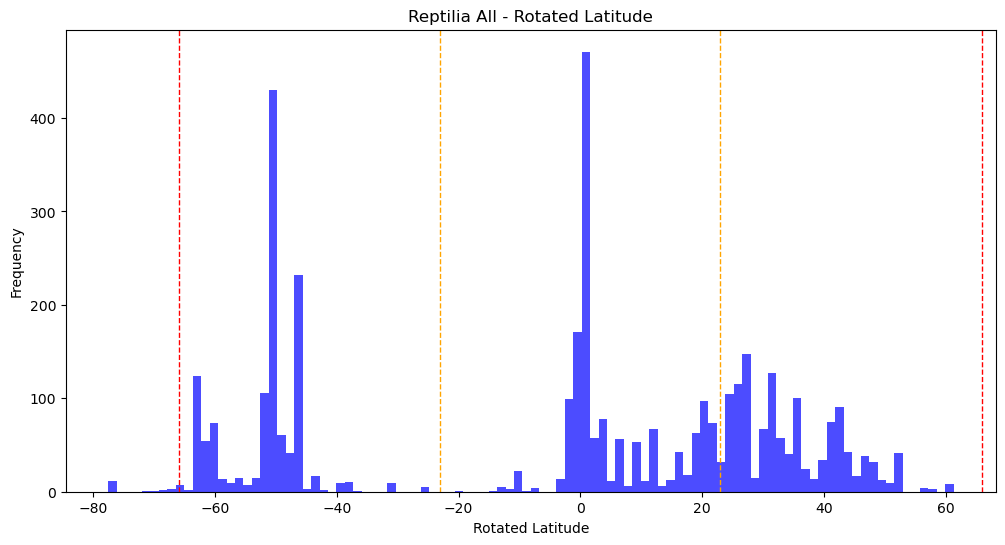

In [ ]:
# Visualizing the latitudes, separately for Reptilia All and Synapsida
plt.figure(figsize=(12, 6))
plt.hist(pt_reptilia_all_lats_filtered['Rotated latitude'], bins=100, color='blue', alpha=0.7)
# vertical lines at x = 66, 23, -23, -66
plt.axvline(x=66, color='red', linestyle='--', linewidth=1)
plt.axvline(x=23, color='orange', linestyle='--', linewidth=1)
plt.axvline(x=-23, color='orange', linestyle='--', linewidth=1)
plt.axvline(x=-66, color='red', linestyle='--', linewidth=1)
plt.title('Reptilia All - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.savefig('Perm-Trias/pt_data_visualizations/occs_latitudes/reptilia_all_widened_rotated_latitude_histogram.png', dpi=600)
plt.show()


In [133]:
explore_lats(pt_reptilia_all_lats_filtered, 'Reptilia All Lats')

Exploring latitudes for Reptilia All Lats:

Number of unique genera in the Arctic biome, lat > 66
0

Number of unique genera on the cusp of the 66.5 degree line, 66 < lat < 67
0

Number of unique genera on the cusp of the 23.5 degree line, 23 < lat < 24
6

Latitude ranges of these cusp genera:
          genus       min       max  Occs on both sides of 23.5
0    Ammosaurus  23.76488  23.76488                       False
1  Bromsgroveia  23.39688  23.39688                        True
2   Clevosaurus  23.76488  23.76488                        True
3    Langeronyx  23.39688  23.39688                        True
4   Protosuchus  23.76488  23.76488                        True
5  Rhombopholis  23.39688  23.39688                        True

Number of unique genera on the cusp of the -23.5 degree line, -24 < lat < -23
0

Number of unique genera on the cusp of the -66.5 degree line, -67 < lat < -66
0

Number of unique genera in the Antarctic biome, lat <= -66
7


##### 23.5 Deg Cusp

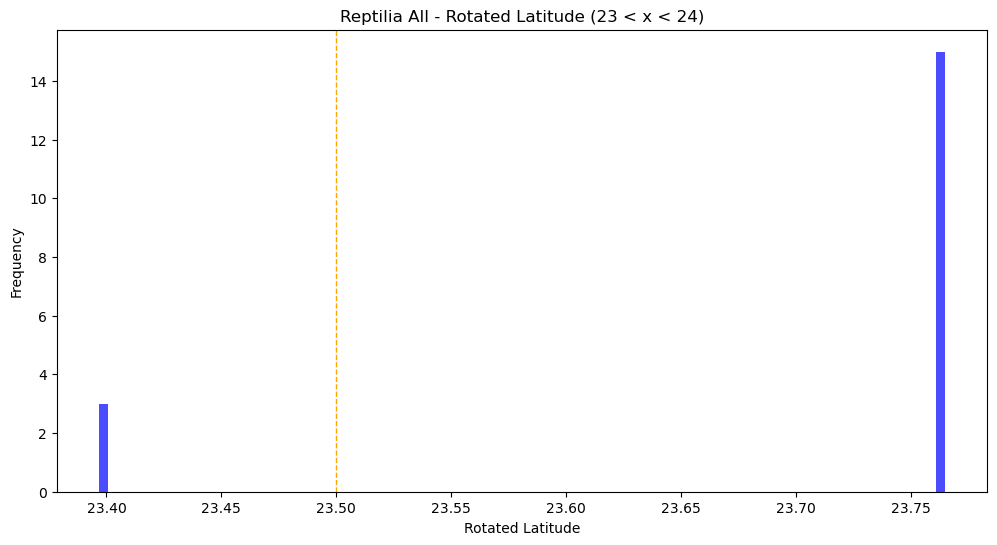

In [97]:
# Plot just reptilia all latitudes at 23 <= x <= 24, colored by genus
plt.figure(figsize=(12, 6))
plt.hist(pt_reptilia_all_lats_filtered[(pt_reptilia_all_lats_filtered['Rotated latitude'] >= 23) & (pt_reptilia_all_lats_filtered['Rotated latitude'] <= 24)]['Rotated latitude'], bins=100, color='blue', alpha=0.7)
plt.title('Reptilia All - Rotated Latitude (23 < x < 24)')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.axvline(x=23.5, color='orange', linestyle='--', linewidth=1)
plt.show()

In [ ]:
def plot_latitude_in_chosen_range(df, y_range, y_value, title):   
    """Plot the distribution of Rotated Latitude by Genus."""
    filtered_df = df[(df['Rotated latitude'] >= y_range[0]) & (df['Rotated latitude'] <= y_range[1])]
    
    plt.figure(figsize=(8, 6))
    sns.stripplot(data=filtered_df, 
                  x='genus', 
                  y='Rotated latitude',
                  size=6,
                  alpha=0.7)
    
    plt.axhline(y=y_value, color='red', linestyle='--', linewidth=1, label=f'{y_value}° Line')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Genus')
    plt.ylabel('Rotated Latitude')
    plt.title(title)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nSummary by genus:")
    summary = filtered_df.groupby('genus')['Rotated latitude'].agg(['count', 'mean', 'min', 'max'])
    print(summary)


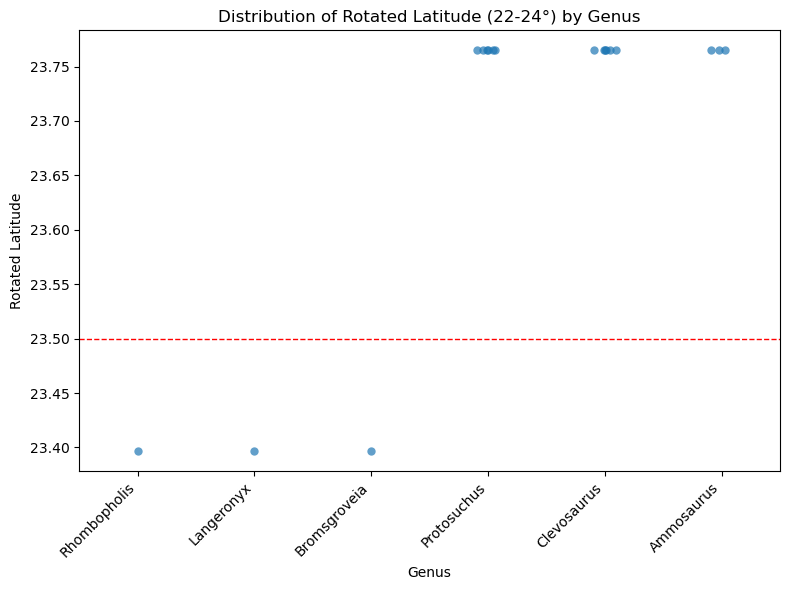


Summary by genus:
              count      mean       min       max
genus                                            
Ammosaurus        3  23.76488  23.76488  23.76488
Bromsgroveia      1  23.39688  23.39688  23.39688
Clevosaurus       6  23.76488  23.76488  23.76488
Langeronyx        1  23.39688  23.39688  23.39688
Protosuchus       6  23.76488  23.76488  23.76488
Rhombopholis      1  23.39688  23.39688  23.39688


In [96]:
plot_latitude_in_chosen_range(pt_reptilia_all_lats_filtered, (23, 24), 23.5, 'Distribution of Rotated Latitude (22-24°) by Genus')

If these genera around the cusp also have an occurrence that is far on the other side of the dividing line, then their presence around the cusp of a line doesn't matter

In [ ]:
reptilia_lats_by_genus = pt_reptilia_all_lats_filtered.groupby('genus')['Rotated latitude'].agg(['count', 'mean', 'min', 'max']).sort_values(by='count', ascending=False)

In [109]:
reptilia_lats_by_genus[reptilia_lats_by_genus.index.isin(['Ammosaurus', 'Bromsgroveia', 'Clevosaurus', 'Langeronyx', 'Protosuchus', 'Rhombopholis'])]

,count,mean,min,max
genus,,,,
Clevosaurus,51,-10.003465,-49.477130,52.14119
Protosuchus,10,16.694395,6.088668,23.76488
Bromsgroveia,4,24.262117,23.396880,24.55053
Langeronyx,3,24.165980,23.396880,24.55053
Ammosaurus,3,23.764880,23.764880,23.76488
Rhombopholis,3,24.165980,23.396880,24.55053


##### -66.5 Cusp

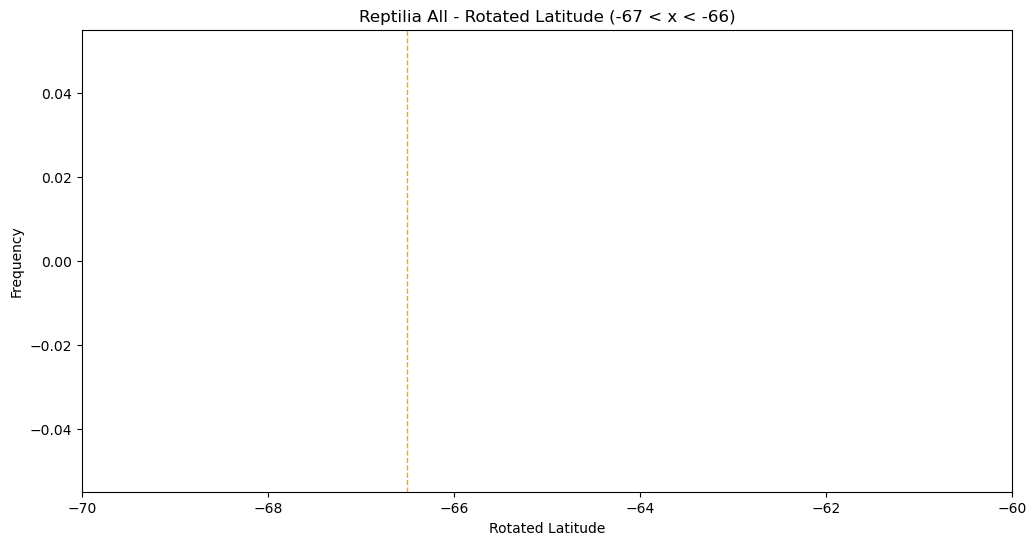

In [94]:
# Plot just reptilia all latitudes at -67 < x < -66, colored by genus
plt.figure(figsize=(12, 6))
plt.hist(pt_reptilia_all_lats_filtered[(pt_reptilia_all_lats_filtered['Rotated latitude'] >= -67) & (pt_reptilia_all_lats_filtered['Rotated latitude'] <= -66)]['Rotated latitude'], bins=100, color='blue', alpha=0.7)
plt.title('Reptilia All - Rotated Latitude (-67 < x < -66)')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
# Limit x axis to -70 to -60
plt.xlim(-70, -60)
plt.axvline(x=-66.5, color='orange', linestyle='--', linewidth=1)
plt.show()

##### Widening "Cusp" Definition

In [135]:
def explore_lats_wider(df, name):
    print(f"Exploring wider latitudes for {name}:")

    print("\nNumber of unique genera on a wider cusp of the 66.5 degree line, 65.5 < lat < 67.5")
    wider_cusp_arctic_biome = df[(df['Rotated latitude'] >= 65.5) & (df['Rotated latitude'] <= 67.5)]
    wider_cusp_arctic_biome = wider_cusp_arctic_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']).reset_index()
    print(len(wider_cusp_arctic_biome))        
    # Do those genera on the cusp of the Arctic biome have occurrences on both sides of the 66.5 degree line?
    wider_cusp_arctic_biome['Occs on both sides of 66.5'] = False
    if len(wider_cusp_arctic_biome) > 0:
        wider_cusp_arctic_biome_genera = wider_cusp_arctic_biome['genus'].to_list()
        for genus in wider_cusp_arctic_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < 66.5 and occurrences['Rotated latitude'].max() > 66.5:
                wider_cusp_arctic_biome.loc[wider_cusp_arctic_biome['genus'] == genus, 'Occs on both sides of 66.5'] = True
            else:
                wider_cusp_arctic_biome.loc[wider_cusp_arctic_biome['genus'] == genus, 'Occs on both sides of 66.5'] = False
        print("\nLatitude ranges of these cusp genera:")
        print(wider_cusp_arctic_biome)
    

    print("\nNumber of unique genera on a wider cusp of the 23.5 degree line, 22.5 < lat < 24.5")
    wider_cusp_tropic_north_biome = df[(df['Rotated latitude'] >= 22.5) & (df['Rotated latitude'] <= 24.5)]
    wider_cusp_tropic_north_biome = wider_cusp_tropic_north_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']).reset_index()
    print(len(wider_cusp_tropic_north_biome))
    # Do those genera on the cusp of the Tropic of Cancer have occurrences on both sides of the 23.5 degree line?
    wider_cusp_tropic_north_biome['Occs on both sides of 23.5'] = False
    if len(wider_cusp_tropic_north_biome) > 0:
        wider_cusp_tropic_north_biome_genera = wider_cusp_tropic_north_biome['genus'].to_list()
        for genus in wider_cusp_tropic_north_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < 23.5 and occurrences['Rotated latitude'].max() > 23.5:
                wider_cusp_tropic_north_biome.loc[wider_cusp_tropic_north_biome['genus'] == genus, 'Occs on both sides of 23.5'] = True
            else:
                wider_cusp_tropic_north_biome.loc[wider_cusp_tropic_north_biome['genus'] == genus, 'Occs on both sides of 23.5'] = False
        print("\nLatitude ranges of these cusp genera:")
        print(wider_cusp_tropic_north_biome)


    print("\nNumber of unique genera on a wider cusp of the -23.5 degree line, -24.5 < lat < -22.5")
    wider_cusp_tropic_south_biome = df[(df['Rotated latitude'] >= -24.5) & (df['Rotated latitude'] <= -22.5)]
    wider_cusp_tropic_south_biome = wider_cusp_tropic_south_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']).reset_index()
    print(len(wider_cusp_tropic_south_biome))
    # Do those genera on the cusp of the Tropic of Capricorn have occurrences on both sides of the -23.5 degree line?
    wider_cusp_tropic_south_biome['Occs on both sides of -23.5'] = False
    if len(wider_cusp_tropic_south_biome) > 0:
        wider_cusp_tropic_south_biome_genera = wider_cusp_tropic_south_biome['genus'].to_list()
        for genus in wider_cusp_tropic_south_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < -23.5 and occurrences['Rotated latitude'].max() > -23.5:
                wider_cusp_tropic_south_biome.loc[wider_cusp_tropic_south_biome['genus'] == genus, 'Occs on both sides of -23.5'] = True
            else:
                wider_cusp_tropic_south_biome.loc[wider_cusp_tropic_south_biome['genus'] == genus, 'Occs on both sides of -23.5'] = False
        print("\nLatitude ranges of these cusp genera:")
        print(wider_cusp_tropic_south_biome)


    print("\nNumber of unique genera on a wider cusp of the -66.5 degree line, -67.5 < lat < -65.5")
    wider_cusp_antarctic_biome = df[(df['Rotated latitude'] >= -67.5) & (df['Rotated latitude'] <= -65.5)]
    wider_cusp_antarctic_biome = wider_cusp_antarctic_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']).reset_index()
    print(len(wider_cusp_antarctic_biome))
    # Do those genera on the cusp of the Antarctic Circle have occurrences on both sides of the -66.5 degree line?        
    wider_cusp_antarctic_biome['Occs on both sides of -66.5'] = False
    if len(wider_cusp_antarctic_biome) > 0:
        wider_cusp_antarctic_biome_genera = wider_cusp_antarctic_biome['genus'].to_list()
        for genus in wider_cusp_antarctic_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < -66.5 and occurrences['Rotated latitude'].max() > -66.5:
                wider_cusp_antarctic_biome.loc[wider_cusp_antarctic_biome['genus'] == genus, 'Occs on both sides of -66.5'] = True
            else:
                wider_cusp_antarctic_biome.loc[wider_cusp_antarctic_biome['genus'] == genus, 'Occs on both sides of -66.5'] = False
        print("\nLatitude ranges of these cusp genera:")
        print(wider_cusp_antarctic_biome)           


  

In [ ]:
def explore_lats_wider(df, name):
    print(f"Exploring latitudes for {name}:")


    print("Number of unique genera on the widened_cusp of the 66.5 degree line, 65.5 < lat < 67.5")
    widened_cusp_arctic_biome = df[(df['Rotated latitude'] >= 65.5) & (df['Rotated latitude'] <= 67.5)]
    print(len(widened_cusp_arctic_biome['genus'].unique()))
    plot_latitude_in_chosen_range(df, (65.5, 67.5), 66.5, 'Distribution of Rotated Latitude (65.5, 67.5°) by Genus')
    if len(widened_cusp_arctic_biome) > 0:
        print(widened_cusp_arctic_biome)
        print("\nLatitude ranges of these widened_cusp genera:")
        print(widened_cusp_arctic_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']))
    # Do those genera on the widened_cusp of the Arctic Circle have occurrences on both sides of the 66.5 degree line?
    if len(widened_cusp_arctic_biome) > 0:
        widened_cusp_arctic_biome_genera = widened_cusp_arctic_biome['genus'].unique()
        for genus in widened_cusp_arctic_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < 66.5 and occurrences['Rotated latitude'].max() > 66.5:
                print(f"{genus} has occurrences on both sides of the 66.5 degree line.")
            else:
                print(f"{genus} does NOT have occurrences on both sides of the 66.5 degree line.")
                      

    print("Number of unique genera on the widened_cusp of the 23.5 degree line, 22.5 < lat < 24.5")
    widened_cusp_tropic_north_biome = df[(df['Rotated latitude'] >= 22.5) & (df['Rotated latitude'] <= 24.5)]
    print(len(widened_cusp_tropic_north_biome['genus'].unique()))
    if len(widened_cusp_tropic_north_biome) > 0:
        print(widened_cusp_tropic_north_biome)
        print("\nLatitude ranges of these widened_cusp genera:")
        print(widened_cusp_tropic_north_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']))
    # Do those genera on the widened_cusp of the Tropic of Cancer have occurrences on both sides of the 23.5 degree line?
    if len(widened_cusp_tropic_north_biome) > 0:
        widened_cusp_tropic_north_biome_genera = widened_cusp_tropic_north_biome['genus'].unique()
        for genus in widened_cusp_tropic_north_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < 23.5 and occurrences['Rotated latitude'].max() > 23.5:
                print(f"{genus} has occurrences on both sides of the 23.5 degree line.")
            else:
                print(f"{genus} does NOT have occurrences on both sides of the 23.5 degree line.")


    print("Number of unique genera on the widened_cusp of the -23.5 degree line, -24.5 < lat < -22.5")
    widened_cusp_tropic_south_biome = df[(df['Rotated latitude'] >= -24.5) & (df['Rotated latitude'] <= -22.5)]
    print(len(widened_cusp_tropic_south_biome['genus'].unique()))
    if len(widened_cusp_tropic_south_biome) > 0:
        print(widened_cusp_tropic_south_biome)
        print("\nLatitude ranges of these widened_cusp genera:")
        print(widened_cusp_tropic_south_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']))
    # Do those genera on the widened_cusp of the Tropic of Capricorn have occurrences on both sides of the -23.5 degree line?
    if len(widened_cusp_tropic_south_biome) > 0:
        widened_cusp_tropic_south_biome['Occs on both sides of -23.5'] = False
        widened_cusp_tropic_south_biome_genera = widened_cusp_tropic_south_biome['genus'].unique()
        for genus in widened_cusp_tropic_south_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < -23.5 and occurrences['Rotated latitude'].max() > -23.5:
                print(f"{genus} has occurrences on both sides of the -23.5 degree line.")
                widened_cusp_tropic_south_biome.loc[widened_cusp_tropic_south_biome['genus'] == genus, 'Occs on both sides of -23.5'] = True
            else:
                print(f"{genus} does NOT have occurrences on both sides of the -23.5 degree line.")
                widened_cusp_tropic_south_biome.loc[widened_cusp_tropic_south_biome['genus'] == genus, 'Occs on both sides of -23.5'] = False


    print("Number of unique genera on the widened_cusp of the -66.5 degree line, -67.5 < lat < -65.5")
    widened_cusp_antarctic_biome = df[(df['Rotated latitude'] >= -67.5) & (df['Rotated latitude'] <= -65.5)]
    print(len(widened_cusp_antarctic_biome['genus'].unique()))
    if len(widened_cusp_antarctic_biome) > 0:
        print(widened_cusp_antarctic_biome)
        print("\nLatitude ranges of these widened_cusp genera:")
        print(widened_cusp_antarctic_biome.groupby('genus')['Rotated latitude'].agg(['min', 'max']))
    # Do those genera on the widened_cusp of the Antarctic Circle have occurrences on both sides of the -66.5 degree line?
    if len(widened_cusp_antarctic_biome) > 0:
        widened_cusp_antarctic_biome_genera = widened_cusp_antarctic_biome['genus'].unique()
        for genus in widened_cusp_antarctic_biome_genera:
            occurrences = df[df['genus'] == genus]
            if occurrences['Rotated latitude'].min() < -66.5 and occurrences['Rotated latitude'].max() > -66.5:
                print(f"{genus} has occurrences on both sides of the -66.5 degree line.")
            else:
                print(f"{genus} does NOT have occurrences on both sides of the -66.5 degree line.")

    # If any of the above dataframes containing widened_cusp genera are >=1, print the rows in the dataframe that correspond to those genera

  

In [136]:
explore_lats_wider(pt_reptilia_all_lats_filtered, 'Reptilia All Lats Wider')

Exploring wider latitudes for Reptilia All Lats Wider:

Number of unique genera on a wider cusp of the 66.5 degree line, 65.5 < lat < 67.5
0

Number of unique genera on a wider cusp of the 23.5 degree line, 22.5 < lat < 24.5
21

Latitude ranges of these cusp genera:
               genus       min       max  Occs on both sides of 23.5
0         Ammosaurus  23.76488  23.76488                       False
1        Amotosaurus  22.98052  22.98052                        True
2         Anomoiodon  22.98052  22.98052                        True
3       Bromsgroveia  23.39688  23.39688                        True
4        Clevosaurus  23.76488  23.76488                        True
5           Cyamodus  24.21337  24.21337                        True
6       Cymatosaurus  22.98052  24.48539                        True
7         Langeronyx  23.39688  23.39688                        True
8     Marcianosuchus  22.98052  22.98052                       False
9       Megachirella  24.48539  24.48539   

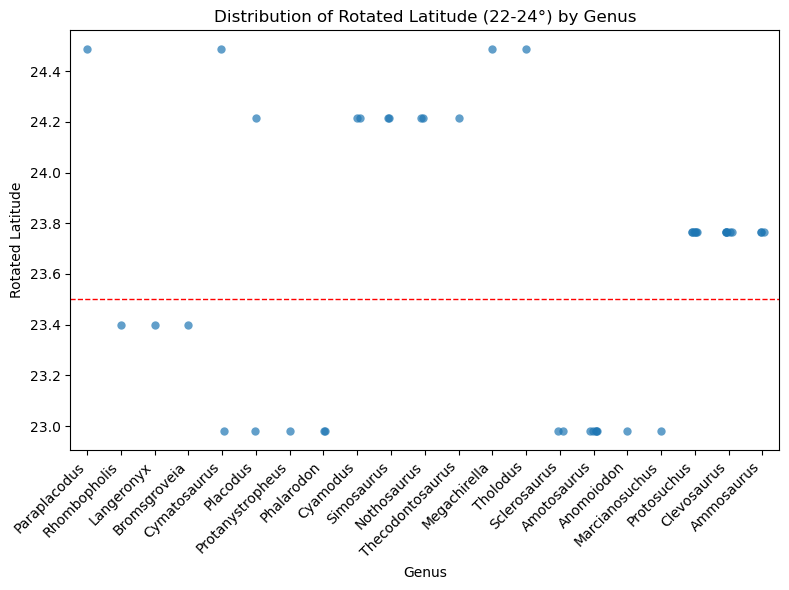


Summary by genus:
                  count       mean       min       max
genus                                                 
Ammosaurus            3  23.764880  23.76488  23.76488
Amotosaurus           5  22.980520  22.98052  22.98052
Anomoiodon            1  22.980520  22.98052  22.98052
Bromsgroveia          1  23.396880  23.39688  23.39688
Clevosaurus           6  23.764880  23.76488  23.76488
Cyamodus              2  24.213370  24.21337  24.21337
Cymatosaurus          2  23.732955  22.98052  24.48539
Langeronyx            1  23.396880  23.39688  23.39688
Marcianosuchus        1  22.980520  22.98052  22.98052
Megachirella          1  24.485390  24.48539  24.48539
Nothosaurus           2  24.213370  24.21337  24.21337
Paraplacodus          1  24.485390  24.48539  24.48539
Phalarodon            2  22.980520  22.98052  22.98052
Placodus              2  23.596945  22.98052  24.21337
Protanystropheus      1  22.980520  22.98052  22.98052
Protosuchus           6  23.764880  23.76488  

In [104]:
plot_latitude_in_chosen_range(pt_reptilia_all_lats_filtered, (22.5, 24.5), 23.5, 'Distribution of Rotated Latitude (22-24°) by Genus')

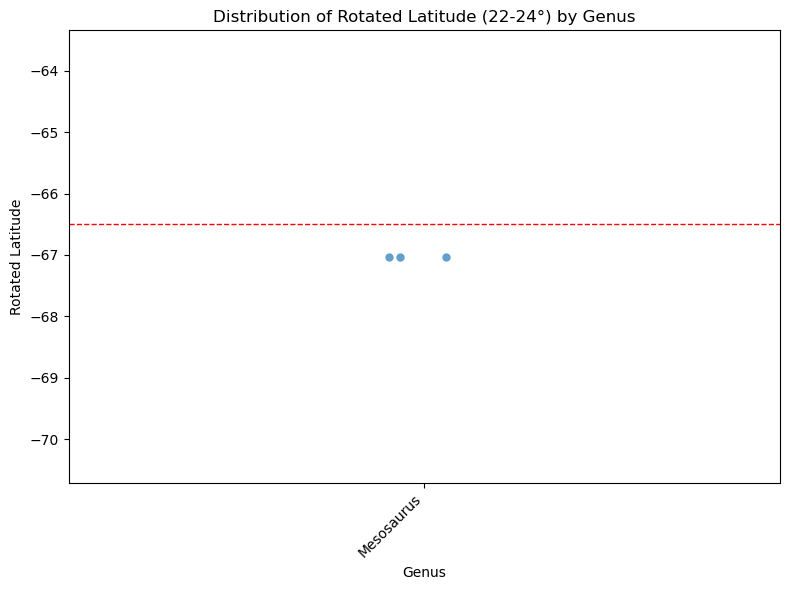


Summary by genus:
            count     mean      min      max
genus                                       
Mesosaurus      3 -67.0248 -67.0248 -67.0248


In [105]:
plot_latitude_in_chosen_range(pt_reptilia_all_lats_filtered, (-67.5, -65.5), -66.5, 'Distribution of Rotated Latitude (22-24°) by Genus')

#### Synapsida Cusp

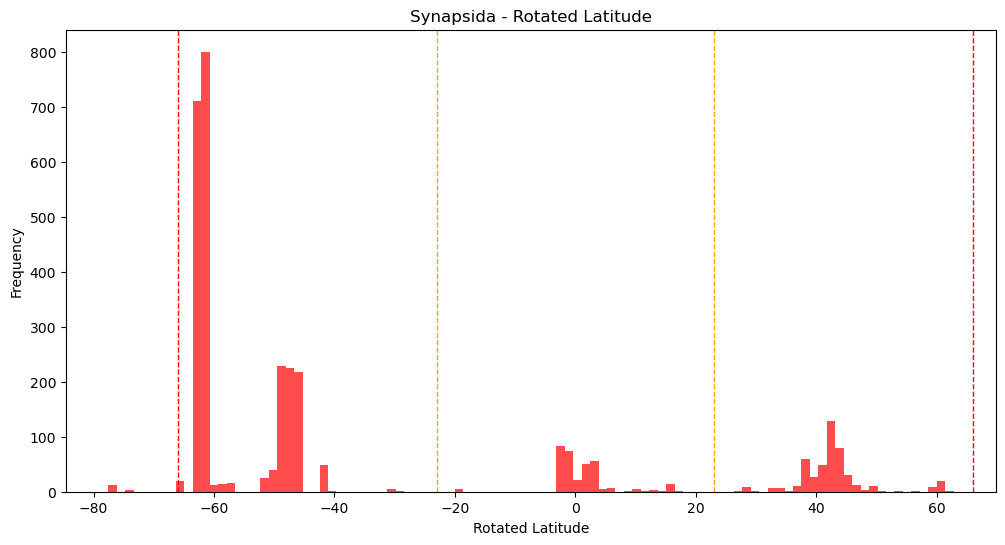

In [41]:
plt.figure(figsize=(12, 6))
plt.hist(pt_synapsida_lats_filtered['Rotated latitude'], bins=100, color='red', alpha=0.7)
# vertical lines at x = 66, 23, -23, -66
plt.axvline(x=66, color='red', linestyle='--', linewidth=1)
plt.axvline(x=23, color='orange', linestyle='--', linewidth=1)
plt.axvline(x=-23, color='orange', linestyle='--', linewidth=1)
plt.axvline(x=-66, color='red', linestyle='--', linewidth=1)
plt.title('Synapsida - Rotated Latitude')
plt.xlabel('Rotated Latitude')
plt.ylabel('Frequency')
plt.savefig('Perm-Trias/pt_data_visualizations/occs_latitudes/synapsida_widened_rotated_latitude_histogram.pdf')
plt.show()

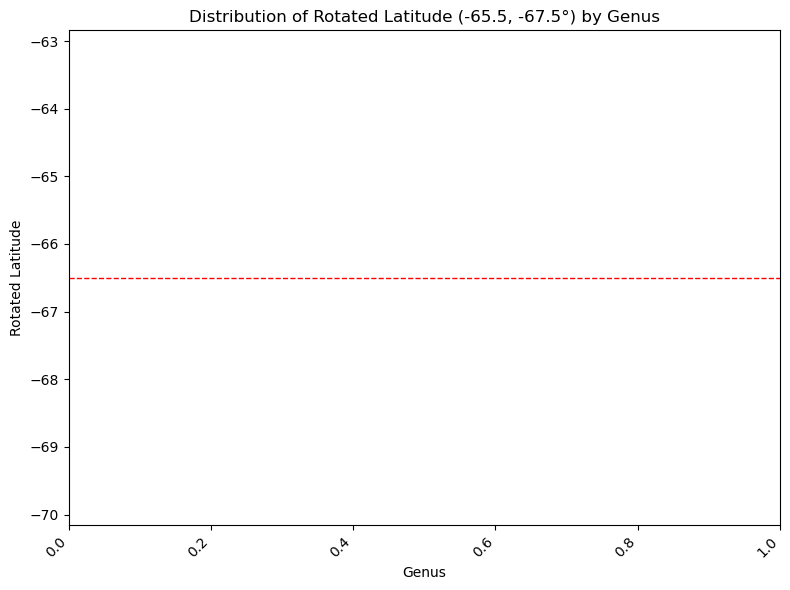


Summary by genus:
Empty DataFrame
Columns: [count, mean, min, max]
Index: []


In [140]:
plot_latitude_in_chosen_range(pt_synapsida_lats_filtered, (-65.5, -67.5), -66.5, 'Distribution of Rotated Latitude (-65.5, -67.5°) by Genus')

In [138]:
explore_lats(pt_synapsida_lats_filtered, 'Synapsida Lats')

Exploring latitudes for Synapsida Lats:

Number of unique genera in the Arctic biome, lat > 66
0

Number of unique genera on the cusp of the 66.5 degree line, 66 < lat < 67
0

Number of unique genera on the cusp of the 23.5 degree line, 23 < lat < 24
0

Number of unique genera on the cusp of the -23.5 degree line, -24 < lat < -23
0

Number of unique genera on the cusp of the -66.5 degree line, -67 < lat < -66
0

Number of unique genera in the Antarctic biome, lat <= -66
9


In [139]:
explore_lats_wider(pt_synapsida_lats_filtered, 'Synapsida Lats Wider')

Exploring wider latitudes for Synapsida Lats Wider:

Number of unique genera on a wider cusp of the 66.5 degree line, 65.5 < lat < 67.5
0

Number of unique genera on a wider cusp of the 23.5 degree line, 22.5 < lat < 24.5
0

Number of unique genera on a wider cusp of the -23.5 degree line, -24.5 < lat < -22.5
0

Number of unique genera on a wider cusp of the -66.5 degree line, -67.5 < lat < -65.5
0


### Checking Lat Data Coverage

In [ ]:
# Check that all genuses in gl_reptilia_all, gl_reptilia_terr, gl_synapsida, and pt_reptilia_terr are in the latitude data predictor file

# Create list of all unique genera in gl_reptilia_all, gl_reptilia_terr, gl_synapsida, and pt_reptilia_terr, then compare to the list of genera 
# in the latitude data predictor file

### Lat Data Troubleshooting

Ran into an error message after running model_6 on reptilia:

The error: Traceback (most recent call last):
  File "C:\Users\SimoesLabAdmin\Documents\PyRate\PyRate.py", line 7000, in <module>
    trait_values = np.array(trait_val)
                   ^^^^^^^^^^^^^^^^^^^
ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (682,) + inhomogeneous part.


First tested if -trait_file .txt could only takeo ne trait column at a time, by only feeding in a lat trait file with 'genus' and the 'lat_range_z_trans' value. Error did not go away

Then I looked at the code in question (line 7000 of PyRate.py) and found the code uses .split() to split each row into a specific # of elements/columns. .split() splits on white space. If some of the values in my columns have white space in them, the row with a value containing a white space will have more columns than the other rows after the .split(). Did some EDA and realized I had to remove white space from 2 genera in reptilia_all.

Well that would be extremely troublesome, because I'd have to recreate all the pyrate input files in order to rename just those 2 genera (which also only have one occurrence each)

I went into the PyRate.txt's and yes, the genera are named:

"new Neotheropoda" and "new Rhynchocephalia"

However, in the PyRate.py's (created using the PyRate.txt's) the program automatically turned those spaces into underscores. At the bottom of the PyRate.py you can see 'new_Neotheropoda' and 'new_Rhynchocephalia'. 

So all I should have to do is go into the bdnn_trait_file folder and manually change the genera names (changing the space to an underscore) in the reptilia_all_lats_file_groupby_filtered.txt. 

So I did that, and it worked. Error resolved, model running. 

Just in case I ever run this full notebook again though, I'm adding in code that changes the names in this notebook, so that I don't have to run into this error again. 


In [277]:
reptilia_all_lats_file_groupby_filtered = pd.read_csv("Perm-Trias/bdnn_trait_files/reptilia_all_lats_file_groupby_filtered.txt", sep="\t")
synapsida_lats_file_groupby_filtered = pd.read_csv("Perm-Trias/bdnn_trait_files/synapsida_lats_file_groupby_filtered.txt", sep="\t")
reptilia_all_lats_file_groupby_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   genus              682 non-null    object 
 1   lat_range_z_trans  682 non-null    float64
 2   Arctic             682 non-null    int64  
 3   Temperate_N        682 non-null    int64  
 4   Tropical           682 non-null    int64  
 5   Temperate_S        682 non-null    int64  
 6   Antarctic          682 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 37.4+ KB


In [ ]:
## Used this when I ran into an error message after running model_6 on reptilia, to see if -trait_file .txt could only have one trait column at a time. No
## The error: Traceback (most recent call last):
#   File "C:\Users\SimoesLabAdmin\Documents\PyRate\PyRate.py", line 7000, in <module>
#     trait_values = np.array(trait_val)
#                    ^^^^^^^^^^^^^^^^^^^
# ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (682,) + inhomogeneous part.
# reptilia_all_lats_file_groupby_filtered_lats_only = reptilia_all_lats_file_groupby_filtered[['genus', 'lat_range_z_trans']]
# reptilia_all_lats_file_groupby_filtered_lats_only.to_csv("Perm-Trias/bdnn_trait_files/reptilia_lats_test.txt", sep="\t", index=False)

In [ ]:
reptilia_all_lats_file_groupby_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   genus              682 non-null    object 
 1   lat_range_z_trans  682 non-null    float64
 2   Arctic             682 non-null    int64  
 3   Temperate_N        682 non-null    int64  
 4   Tropical           682 non-null    int64  
 5   Temperate_S        682 non-null    int64  
 6   Antarctic          682 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 37.4+ KB


In [ ]:
reptilia_all_lats_file_groupby_filtered.describe()

,lat_range_z_trans,Arctic,Temperate_N,Tropical,Temperate_S,Antarctic
count,6.820000e+02,682.0,682.000000,682.000000,682.000000,682.000000
mean,-1.041852e-17,0.0,0.422287,0.390029,0.291789,0.010264
std,1.000734e+00,0.0,0.494286,0.488115,0.454919,0.100864
min,-3.368252e-01,0.0,0.000000,0.000000,0.000000,0.000000
25%,-3.368252e-01,0.0,0.000000,0.000000,0.000000,0.000000
50%,-3.368252e-01,0.0,0.000000,0.000000,0.000000,0.000000
75%,-1.718293e-01,0.0,1.000000,1.000000,1.000000,0.000000
max,8.987645e+00,0.0,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Check if any genus names contain spaces
genus_with_spaces = reptilia_all_lats_file_groupby_filtered[reptilia_all_lats_file_groupby_filtered['genus'].str.contains(' ', na=False)]
print("Genus names with spaces:")
print(genus_with_spaces['genus'].tolist())

# Check for unusual characters
print("\nUnique characters in genus names:")
all_chars = set(''.join(reptilia_all_lats_file_groupby_filtered['genus']))
print(sorted(all_chars))

Genus names with spaces:
['new Neotheropoda', 'new Rhynchocephalia']

Unique characters in genus names:
[' ', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [ ]:
## Used this when I ran into an error message after running model_6 on reptilia, to see if -trait_file .txt could only have one trait column at a time. No
## The error: Traceback (most recent call last):
#   File "C:\Users\SimoesLabAdmin\Documents\PyRate\PyRate.py", line 7000, in <module>
#     trait_values = np.array(trait_val)
#                    ^^^^^^^^^^^^^^^^^^^
# ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (682,) + inhomogeneous part.
# reptilia_all_lats_file_groupby_filtered_lats_only = reptilia_all_lats_file_groupby_filtered[['genus', 'lat_range_z_trans']]
# reptilia_all_lats_file_groupby_filtered_lats_only.to_csv("Perm-Trias/bdnn_trait_files/reptilia_lats_test.txt", sep="\t", index=False)

In [ ]:
reptilia_all_lats_file_groupby_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   genus              682 non-null    object 
 1   lat_range_z_trans  682 non-null    float64
 2   Arctic             682 non-null    int64  
 3   Temperate_N        682 non-null    int64  
 4   Tropical           682 non-null    int64  
 5   Temperate_S        682 non-null    int64  
 6   Antarctic          682 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 37.4+ KB


In [ ]:
reptilia_all_lats_file_groupby_filtered.describe()

,lat_range_z_trans,Arctic,Temperate_N,Tropical,Temperate_S,Antarctic
count,6.820000e+02,682.0,682.000000,682.000000,682.000000,682.000000
mean,-1.041852e-17,0.0,0.422287,0.390029,0.291789,0.010264
std,1.000734e+00,0.0,0.494286,0.488115,0.454919,0.100864
min,-3.368252e-01,0.0,0.000000,0.000000,0.000000,0.000000
25%,-3.368252e-01,0.0,0.000000,0.000000,0.000000,0.000000
50%,-3.368252e-01,0.0,0.000000,0.000000,0.000000,0.000000
75%,-1.718293e-01,0.0,1.000000,1.000000,1.000000,0.000000
max,8.987645e+00,0.0,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Check if any genus names contain spaces
genus_with_spaces = reptilia_all_lats_file_groupby_filtered[reptilia_all_lats_file_groupby_filtered['genus'].str.contains(' ', na=False)]
print("Genus names with spaces:")
print(genus_with_spaces['genus'].tolist())

# Check for unusual characters
print("\nUnique characters in genus names:")
all_chars = set(''.join(reptilia_all_lats_file_groupby_filtered['genus']))
print(sorted(all_chars))

Genus names with spaces:
['new Neotheropoda', 'new Rhynchocephalia']

Unique characters in genus names:
[' ', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [278]:
reptilia_all_lats_file_groupby_filtered.isna().sum()

genus                0
lat_range_z_trans    0
Arctic               0
Temperate_N          0
Tropical             0
Temperate_S          0
Antarctic            0
dtype: int64

In [ ]:
reptilia_all_lats_file_groupby_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   genus              682 non-null    object 
 1   lat_range_z_trans  682 non-null    float64
 2   Arctic             682 non-null    int64  
 3   Temperate_N        682 non-null    int64  
 4   Tropical           682 non-null    int64  
 5   Temperate_S        682 non-null    int64  
 6   Antarctic          682 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 37.4+ KB


In [ ]:
reptilia_all_lats_file_groupby_filtered.describe()

,lat_range_z_trans,Arctic,Temperate_N,Tropical,Temperate_S,Antarctic
count,6.820000e+02,682.0,682.000000,682.000000,682.000000,682.000000
mean,-1.041852e-17,0.0,0.422287,0.390029,0.291789,0.010264
std,1.000734e+00,0.0,0.494286,0.488115,0.454919,0.100864
min,-3.368252e-01,0.0,0.000000,0.000000,0.000000,0.000000
25%,-3.368252e-01,0.0,0.000000,0.000000,0.000000,0.000000
50%,-3.368252e-01,0.0,0.000000,0.000000,0.000000,0.000000
75%,-1.718293e-01,0.0,1.000000,1.000000,1.000000,0.000000
max,8.987645e+00,0.0,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Check if any genus names contain spaces
genus_with_spaces = reptilia_all_lats_file_groupby_filtered[reptilia_all_lats_file_groupby_filtered['genus'].str.contains(' ', na=False)]
print("Genus names with spaces:")
print(genus_with_spaces['genus'].tolist())

# Check for unusual characters
print("\nUnique characters in genus names:")
all_chars = set(''.join(reptilia_all_lats_file_groupby_filtered['genus']))
print(sorted(all_chars))

Genus names with spaces:
['new Neotheropoda', 'new Rhynchocephalia']

Unique characters in genus names:
[' ', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


## Time-Series Data (Isotopic, Stage)

In [13]:
songEA_data = pd.read_csv("Guad-Ladin/songEA_isotopic_data_gl_stages/PaleoEnvData_Stage_SongEA_Guad-Lad.csv")
songEA_data

,Period,Stage,age,mean,Mod_R_deltaTMyr
0,Permian,Roadian,270.50,27.775300,1.532881
1,Permian,Sakmarian,292.00,26.797336,1.676262
2,Permian,Wordian,265.50,25.249696,2.204013
3,Permian,Wuchipiangian,257.00,29.064592,1.262948
4,Triassic,Anisian,244.00,34.241650,1.815053
5,Triassic,Carnian,232.25,32.130069,1.418901
6,Triassic,Induan,250.50,36.701308,2.291109
7,Triassic,Ladinian,239.00,33.490617,2.078977


In [14]:
# The row order needs to be smallest to largest by 'Time'
songEA_data_ordered = songEA_data.sort_values(by='age').reset_index(drop=True)
songEA_data_ordered

,Period,Stage,age,mean,Mod_R_deltaTMyr
0,Triassic,Carnian,232.25,32.130069,1.418901
1,Triassic,Ladinian,239.00,33.490617,2.078977
2,Triassic,Anisian,244.00,34.241650,1.815053
3,Triassic,Induan,250.50,36.701308,2.291109
4,Permian,Wuchipiangian,257.00,29.064592,1.262948
5,Permian,Wordian,265.50,25.249696,2.204013
6,Permian,Roadian,270.50,27.775300,1.532881
7,Permian,Sakmarian,292.00,26.797336,1.676262


In [15]:
songEA_data_ordered.loc[songEA_data_ordered['Stage'] == 'Wuchipiangian', 'Stage'] = 'Wuchiapingian'
songEA_data_ordered


,Period,Stage,age,mean,Mod_R_deltaTMyr
0,Triassic,Carnian,232.25,32.130069,1.418901
1,Triassic,Ladinian,239.00,33.490617,2.078977
2,Triassic,Anisian,244.00,34.241650,1.815053
3,Triassic,Induan,250.50,36.701308,2.291109
4,Permian,Wuchiapingian,257.00,29.064592,1.262948
5,Permian,Wordian,265.50,25.249696,2.204013
6,Permian,Roadian,270.50,27.775300,1.532881
7,Permian,Sakmarian,292.00,26.797336,1.676262


#### Adding proper time bin ages

In [16]:
# Dictionary to map time bins to ages
time_bin_to_age = {
    "Hettangian":199.3,
    "Rhaetian":201.3,
    "Norian":208.5,
    "Carnian":227.0,
    "Ladinian":237.0,
    "Anisian":242.0,
    "Olenekian":247.2,
    "Induan":251.2,
    "Changhsingian":251.902,
    "Wuchiapingian":254.14,
    "Capitanian":259.1,
    "Wordian":265.1,
    "Roadian":268.8,
    "Kungurian":272.95,
    "Artinskian":283.5,
    "Sakmarian":290.1,
    "Asselian":293.52
}

In [17]:
songEA_data_ordered['Time'] = songEA_data_ordered['Stage'].map(time_bin_to_age)
songEA_data_ordered

,Period,Stage,age,mean,Mod_R_deltaTMyr,Time
0,Triassic,Carnian,232.25,32.130069,1.418901,227.00
1,Triassic,Ladinian,239.00,33.490617,2.078977,237.00
2,Triassic,Anisian,244.00,34.241650,1.815053,242.00
3,Triassic,Induan,250.50,36.701308,2.291109,251.20
4,Permian,Wuchiapingian,257.00,29.064592,1.262948,254.14
5,Permian,Wordian,265.50,25.249696,2.204013,265.10
6,Permian,Roadian,270.50,27.775300,1.532881,268.80
7,Permian,Sakmarian,292.00,26.797336,1.676262,290.10


#### Z-transformation

In [18]:
# Z transforming both columns
from sklearn.preprocessing import StandardScaler
scaler_mean = StandardScaler()
songEA_data_ordered['mean_gl_stages_z_trans'] = scaler_mean.fit_transform(songEA_data_ordered[['mean']])
scaler_Mod = StandardScaler()
songEA_data_ordered['Mod_R_deltaTMyr_gl_stages_z_trans'] = scaler_Mod.fit_transform(songEA_data_ordered[['Mod_R_deltaTMyr']])

songEA_data_ordered

,Period,Stage,age,mean,Mod_R_deltaTMyr,Time,mean_gl_stages_z_trans,Mod_R_deltaTMyr_gl_stages_z_trans
0,Triassic,Carnian,232.25,32.130069,1.418901,227.00,0.382854,-1.035019
1,Triassic,Ladinian,239.00,33.490617,2.078977,237.00,0.742399,0.831026
2,Triassic,Anisian,244.00,34.241650,1.815053,242.00,0.940871,0.084911
3,Triassic,Induan,250.50,36.701308,2.291109,251.20,1.590874,1.430728
4,Permian,Wuchiapingian,257.00,29.064592,1.262948,254.14,-0.427245,-1.475899
5,Permian,Wordian,265.50,25.249696,2.204013,265.10,-1.435390,1.184505
6,Permian,Roadian,270.50,27.775300,1.532881,268.80,-0.767961,-0.712796
7,Permian,Sakmarian,292.00,26.797336,1.676262,290.10,-1.026402,-0.307456


In [19]:
songEA_data_ordered_filtered = songEA_data_ordered[['Time', 'mean_gl_stages_z_trans', 'Mod_R_deltaTMyr_gl_stages_z_trans']]
songEA_data_ordered_filtered

,Time,mean_gl_stages_z_trans,Mod_R_deltaTMyr_gl_stages_z_trans
0,227.00,0.382854,-1.035019
1,237.00,0.742399,0.831026
2,242.00,0.940871,0.084911
3,251.20,1.590874,1.430728
4,254.14,-0.427245,-1.475899
5,265.10,-1.435390,1.184505
6,268.80,-0.767961,-0.712796
7,290.10,-1.026402,-0.307456


In [ ]:
songEA_data_ordered_filtered.to_csv("Guad-Ladin/songEA_isotopic_data/songEA_data_ordered_filtered.txt", sep="\t", index=False)

#### Visualization

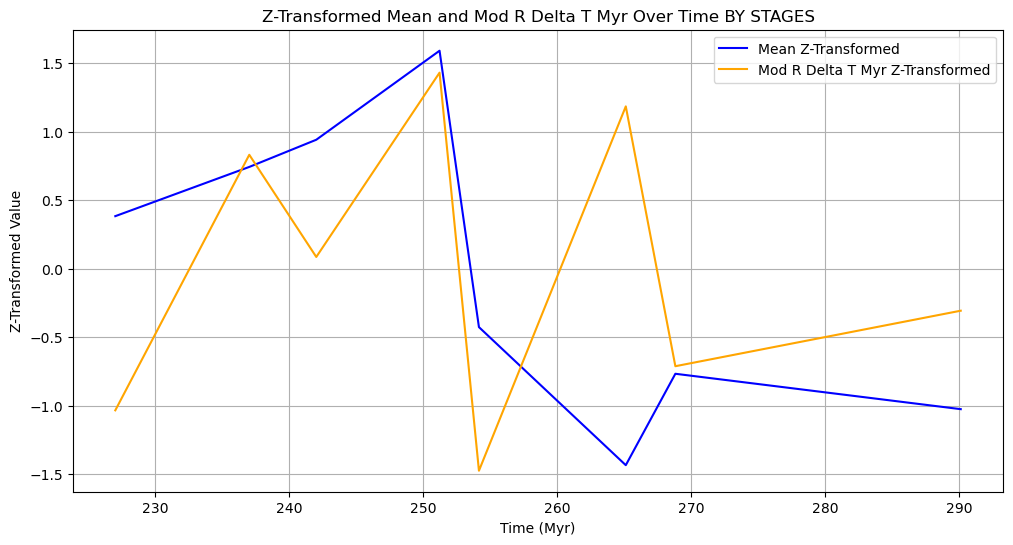

In [36]:
# Plotting the distribution of the mean_z_trans and Mod_R_deltaTMyr_z_trans columns as line plots
plt.figure(figsize=(12, 6))
plt.plot(songEA_data_ordered_filtered['Time'], songEA_data_ordered_filtered['mean_gl_stages_z_trans'], label='Mean Z-Transformed', color='blue')
plt.plot(songEA_data_ordered_filtered['Time'], songEA_data_ordered_filtered['Mod_R_deltaTMyr_gl_stages_z_trans'], label='Mod R Delta T Myr Z-Transformed', color='orange')
plt.title('Z-Transformed Mean and Mod R Delta T Myr Over Time BY STAGES')
plt.xlabel('Time (Myr)')
plt.ylabel('Z-Transformed Value')
plt.legend()
plt.grid()
plt.savefig('Guad-Ladin/gl_data_visualizations/songEA_gl_stages_z_transformed_plot.png')
plt.show()
                                                                            

#### 1 Myr Extension

In [21]:
songEA_data_ordered_filtered

,Time,mean_gl_stages_z_trans,Mod_R_deltaTMyr_gl_stages_z_trans
0,227.00,0.382854,-1.035019
1,237.00,0.742399,0.831026
2,242.00,0.940871,0.084911
3,251.20,1.590874,1.430728
4,254.14,-0.427245,-1.475899
5,265.10,-1.435390,1.184505
6,268.80,-0.767961,-0.712796
7,290.10,-1.026402,-0.307456


In [22]:
# Add rows to 'Time' at every 1 million years, from 227-291
time_range = pd.DataFrame({'Time': range(227, 292)})
# merge keeping all 'Time' values from the original songEA_data_ordered_filtered
songEA_data_ordered_filtered_1myr = pd.merge(time_range, songEA_data_ordered_filtered, on='Time', how='outer')
songEA_data_ordered_filtered_1myr = songEA_data_ordered_filtered_1myr.sort_values(by='Time').reset_index(drop=True)
songEA_data_ordered_filtered_1myr

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_5964\2034147109.py:4: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  songEA_data_ordered_filtered_1myr = pd.merge(time_range, songEA_data_ordered_filtered, on='Time', how='outer')


,Time,mean_gl_stages_z_trans,Mod_R_deltaTMyr_gl_stages_z_trans
0,227.0,0.382854,-1.035019
1,228.0,NaN,NaN
2,229.0,NaN,NaN
3,230.0,NaN,NaN
4,231.0,NaN,NaN
...,...,...,...
65,288.0,NaN,NaN
66,289.0,NaN,NaN
67,290.0,NaN,NaN
68,290.1,-1.026402,-0.307456


In [23]:
# drop the last row, index 69
songEA_data_ordered_filtered_1myr = songEA_data_ordered_filtered_1myr.drop(index=69).reset_index(drop=True)
songEA_data_ordered_filtered_1myr


,Time,mean_gl_stages_z_trans,Mod_R_deltaTMyr_gl_stages_z_trans
0,227.0,0.382854,-1.035019
1,228.0,NaN,NaN
2,229.0,NaN,NaN
3,230.0,NaN,NaN
4,231.0,NaN,NaN
...,...,...,...
64,287.0,NaN,NaN
65,288.0,NaN,NaN
66,289.0,NaN,NaN
67,290.0,NaN,NaN


In [24]:
# checking that all the original years were preserved
subset = songEA_data_ordered_filtered_1myr[songEA_data_ordered_filtered_1myr['Time'].isin(songEA_data_ordered_filtered['Time'])]
subset = subset.reset_index(drop=True)
subset == songEA_data_ordered_filtered

,Time,mean_gl_stages_z_trans,Mod_R_deltaTMyr_gl_stages_z_trans
0,True,True,True
1,True,True,True
2,True,True,True
3,True,True,True
4,True,True,True
5,True,True,True
6,True,True,True
7,True,True,True


I'll fill the NaN values in excel, much easier that way

In [ ]:
# commented out to avoid re-running and overwriting the file
# songEA_data_ordered_filtered_1myr.to_csv("C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\data\\Guad-Ladin\\songEA_isotopic_data\\songEA_data_ordered_filtered_1myr.csv", index=False)

In [26]:
# extended the values by hand, in Excel in the csv
# Now loading that in and saving as txt

songEA_data_1myr = pd.read_csv("Guad-Ladin/songEA_isotopic_data_gl_stages/songEA_data_ordered_filtered_1myr.csv")
songEA_data_1myr

,Time,mean_gl_stages_z_trans,Mod_R_deltaTMyr_gl_stages_z_trans
0,227.0,0.382854,-1.035019
1,228.0,0.382854,-1.035019
2,229.0,0.382854,-1.035019
3,230.0,0.382854,-1.035019
4,231.0,0.382854,-1.035019
...,...,...,...
64,287.0,-0.767961,-0.712796
65,288.0,-0.767961,-0.712796
66,289.0,-0.767961,-0.712796
67,290.0,-0.767961,-0.712796


In [84]:
songEA_data_1myr.to_csv("Guad-Ladin/songEA_isotopic_data/songEA_data_ordered_filtered_1myr.txt", sep="\t", index=False)

#### 0.1 Myr Extension

In [75]:
# Add rows to 'Time' at every 0.1 million years, from 227-291
time_range_01myr = pd.DataFrame({'Time': [x / 10.0 for x in range(2270, 2902)]})
time_range_01myr

,Time
0,227.0
1,227.1
2,227.2
3,227.3
4,227.4
...,...
627,289.7
628,289.8
629,289.9
630,290.0


In [79]:
songEA_data_ordered_filtered_0_1myr = pd.merge(time_range_01myr, songEA_data_ordered_filtered, on='Time', how='outer')
songEA_data_ordered_filtered_0_1myr = songEA_data_ordered_filtered_0_1myr.sort_values(by='Time').reset_index(drop=True)
songEA_data_ordered_filtered_0_1myr

,Time,mean_z_trans,Mod_R_deltaTMyr_z_trans
0,227.0,0.382854,-1.035019
1,227.1,NaN,NaN
2,227.2,NaN,NaN
3,227.3,NaN,NaN
4,227.4,NaN,NaN
...,...,...,...
628,289.7,NaN,NaN
629,289.8,NaN,NaN
630,289.9,NaN,NaN
631,290.0,NaN,NaN


In [101]:
# Checking that all original values are in 0.1myr extension dataframe
subset = songEA_data_ordered_filtered_0_1myr[songEA_data_ordered_filtered_0_1myr['Time'].isin(songEA_data_ordered_filtered['Time'])]
subset = subset.reset_index(drop=True)
subset == songEA_data_ordered_filtered

,Time,mean_z_trans,Mod_R_deltaTMyr_z_trans
0,True,True,True
1,True,True,True
2,True,True,True
3,True,True,True
4,True,True,True
5,True,True,True
6,True,True,True
7,True,True,True


In [ ]:
# Saving as csv file
# commented out to avoid re-running and overwriting the file
# songEA_data_ordered_filtered_0_1myr.to_csv("C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\data\\Guad-Ladin\\songEA_isotopic_data\\songEA_data_ordered_filtered_0.1myr.csv", index=False)

In [28]:
songEA_data_0_1myr = pd.read_csv("Guad-Ladin/songEA_isotopic_data_gl_stages/songEA_data_ordered_filtered_0.1myr.csv")
songEA_data_0_1myr

,Time,mean_gl_stages_z_trans,Mod_R_deltaTMyr_gl_stages_z_trans
0,227.0,0.382854,-1.035019
1,227.1,0.382854,-1.035019
2,227.2,0.382854,-1.035019
3,227.3,0.382854,-1.035019
4,227.4,0.382854,-1.035019
...,...,...,...
628,289.7,-0.767961,-0.712796
629,289.8,-0.767961,-0.712796
630,289.9,-0.767961,-0.712796
631,290.0,-0.767961,-0.712796


In [ ]:
songEA_data_0_1myr.to_csv("Guad-Ladin/songEA_isotopic_data_gl_stages/songEA_data_ordered_filtered_0.1myr.txt", sep="\t", index=False)

#### Adding to Backscale.txt

In [36]:
# Loading in backscale files
pt_reptilia_all_backscale_lats_songEA = pd.read_csv("Perm-Trias/backscale_txts/pt_reptilia_all_lat_range_backscale.txt", sep="\t")
pt_reptilia_terr_backscale_lats_songEA = pd.read_csv("Perm-Trias/backscale_txts/pt_reptilia_terr_lat_range_backscale.txt", sep="\t")
pt_synapsida_backscale_lats_songEA = pd.read_csv("Perm-Trias/backscale_txts/pt_synapsida_lat_range_backscale.txt", sep="\t")

gl_reptilia_all_backscale_lats_songEA = pd.read_csv("Guad-Ladin/backscale_txts/gl_reptilia_all_lat_range_backscale.txt", sep="\t")
gl_reptilia_terr_backscale_lats_songEA = pd.read_csv("Guad-Ladin/backscale_txts/gl_reptilia_terr_lat_range_backscale.txt", sep="\t")
gl_synapsida_backscale_lats_songEA = pd.read_csv("Guad-Ladin/backscale_txts/gl_synapsida_lat_range_backscale.txt", sep="\t")

In [37]:
songEA_mean_mean = songEA_data['mean'].mean()
songEA_mean_std = songEA_data['mean'].std()
songEA_Mod_R_deltaTMyr_mean = songEA_data['Mod_R_deltaTMyr'].mean()
songEA_Mod_R_deltaTMyr_std = songEA_data['Mod_R_deltaTMyr'].std()

In [ ]:
list_backscale_dfs_songEA = [pt_reptilia_all_backscale_lats_songEA, pt_reptilia_terr_backscale_lats_songEA, pt_synapsida_backscale_lats_songEA,
                     gl_reptilia_all_backscale_lats_songEA, gl_reptilia_terr_backscale_lats_songEA, gl_synapsida_backscale_lats_songEA]

for df in list_backscale_dfs_songEA:
    df['mean_gl_stages_z_trans'] = [songEA_mean_mean, songEA_mean_std]
    df['Mod_R_deltaTMyr_gl_stages_z_trans'] = [songEA_Mod_R_deltaTMyr_mean, songEA_Mod_R_deltaTMyr_std]
    


In [39]:
pt_reptilia_all_backscale_lats_songEA, pt_reptilia_terr_backscale_lats_songEA, pt_synapsida_backscale_lats_songEA, gl_reptilia_all_backscale_lats_songEA, gl_reptilia_terr_backscale_lats_songEA, gl_synapsida_backscale_lats_songEA

(   lat_range_z_trans  mean_z_trans  Mod_R_deltaTMyr_z_trans
 0           4.474401     30.681321                 1.785018
 1          13.293794      4.045348                 0.378153,
    lat_range_z_trans  mean_z_trans  Mod_R_deltaTMyr_z_trans
 0           4.036313     30.681321                 1.785018
 1          13.522209      4.045348                 0.378153,
    lat_range_z_trans  mean_z_trans  Mod_R_deltaTMyr_z_trans
 0           4.733017     30.681321                 1.785018
 1          15.930623      4.045348                 0.378153,
    lat_range_z_trans  mean_z_trans  Mod_R_deltaTMyr_z_trans
 0           4.087427     30.681321                 1.785018
 1          12.874720      4.045348                 0.378153,
    lat_range_z_trans  mean_z_trans  Mod_R_deltaTMyr_z_trans
 0           3.493765     30.681321                 1.785018
 1          13.233021      4.045348                 0.378153,
    lat_range_z_trans  mean_z_trans  Mod_R_deltaTMyr_z_trans
 0           5.3263

In [ ]:
# Saving all the backscale dfs as .txt's
pt_reptilia_all_backscale_lats_songEA.to_csv("Perm-Trias/backscale_txts/intermediate_backscale_txts/pt_reptilia_all_backscale_lats_songEA.txt", sep="\t", index=False)
pt_reptilia_terr_backscale_lats_songEA.to_csv("Perm-Trias/backscale_txts/intermediate_backscale_txts/pt_reptilia_terr_backscale_lats_songEA.txt", sep="\t", index=False)
pt_synapsida_backscale_lats_songEA.to_csv("Perm-Trias/backscale_txts/intermediate_backscale_txts/pt_synapsida_backscale_lats_songEA.txt", sep="\t", index=False)
gl_reptilia_all_backscale_lats_songEA.to_csv("Guad-Ladin/backscale_txts/intermediate_backscale_txts/gl_reptilia_all_backscale_lats_songEA.txt", sep="\t", index=False)
gl_reptilia_terr_backscale_lats_songEA.to_csv("Guad-Ladin/backscale_txts/intermediate_backscale_txts/gl_reptilia_terr_backscale_lats_songEA.txt", sep="\t", index=False)
gl_synapsida_backscale_lats_songEA.to_csv("Guad-Ladin/backscale_txts/intermediate_backscale_txts/gl_synapsida_backscale_lats_songEA.txt", sep="\t", index=False)
pt_reptilia_all_backscale_lats_songEA.to_csv("Perm-Trias/backscale_txts/intermediate_backscale_txts/pt_reptilia_all_backscale_lats_songEA.txt", sep="\t", index=False)



## Time-Series Data (Isotopic, 1 Myr)

In [42]:
isotopic_1myr = pd.read_csv("C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\data\\Perm-Trias\\songEA_isotopic_data_pt_1myr\\PaleoEnvData_1MyrBins.csv")
isotopic_1myr

,age,mean,X0.05,X0.95,Mod_R_deltaTMyr
0,300,30.431385,29.252519,31.616849,0.496400
1,299,29.392182,28.292941,30.490016,1.039204
2,298,27.019217,26.109637,27.935705,2.372964
3,297,28.111086,27.111756,29.110829,1.091868
4,296,29.660536,28.537474,30.777291,1.549450
...,...,...,...,...,...
80,206,30.440487,29.256034,31.624960,0.988279
81,205,29.284282,28.203319,30.377471,1.156205
82,204,30.114721,28.956996,31.257468,0.830439
83,203,30.395986,29.224803,31.579625,0.281265


In [43]:
isotopic_1myr_filtered = isotopic_1myr[["age", "mean", "Mod_R_deltaTMyr"]]
# rename columns
isotopic_1myr_filtered.columns = ["Time", "mean_pt_1myr", "Mod_R_deltaTMyr_pt_1myr"]
isotopic_1myr_filtered

,Time,mean_pt_1myr,Mod_R_deltaTMyr_pt_1myr
0,300,30.431385,0.496400
1,299,29.392182,1.039204
2,298,27.019217,2.372964
3,297,28.111086,1.091868
4,296,29.660536,1.549450
...,...,...,...
80,206,30.440487,0.988279
81,205,29.284282,1.156205
82,204,30.114721,0.830439
83,203,30.395986,0.281265


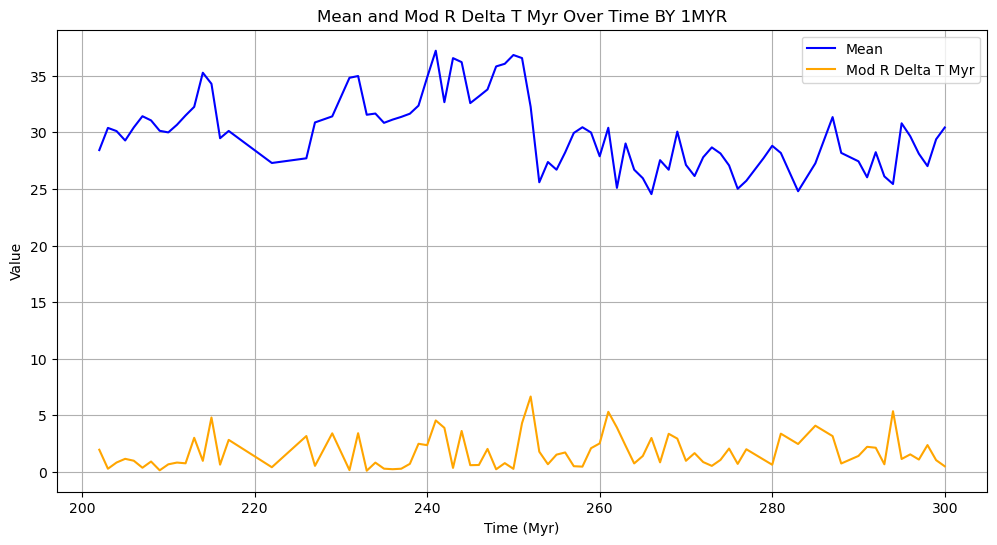

In [45]:
# Plotting the distribution of the mean_z_trans and Mod_R_deltaTMyr_z_trans columns as line plots
plt.figure(figsize=(12, 6))
plt.plot(isotopic_1myr_filtered['Time'], isotopic_1myr_filtered['mean_pt_1myr'], label='Mean', color='blue')
plt.plot(isotopic_1myr_filtered['Time'], isotopic_1myr_filtered['Mod_R_deltaTMyr_pt_1myr'], label='Mod R Delta T Myr', color='orange')
plt.title('Mean and Mod R Delta T Myr Over Time BY 1MYR')
plt.xlabel('Time (Myr)')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.savefig('Perm-Trias/pt_data_visualizations/isotopic_1myr_plot.png', dpi=600)
plt.show()
                                                                            

In [46]:
# z transforming with sklearn standard scaler
from sklearn.preprocessing import StandardScaler
scaler_mean = StandardScaler()
isotopic_1myr_filtered['mean_pt_1myr_z_trans'] = scaler_mean.fit_transform(isotopic_1myr_filtered[['mean_pt_1myr']])
scaler_Mod = StandardScaler()
isotopic_1myr_filtered['Mod_R_deltaTMyr_pt_1myr_z_trans'] = scaler_Mod.fit_transform(isotopic_1myr_filtered[['Mod_R_deltaTMyr_pt_1myr']])

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_19116\2594388136.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isotopic_1myr_filtered['mean_pt_1myr_z_trans'] = scaler_mean.fit_transform(isotopic_1myr_filtered[['mean_pt_1myr']])


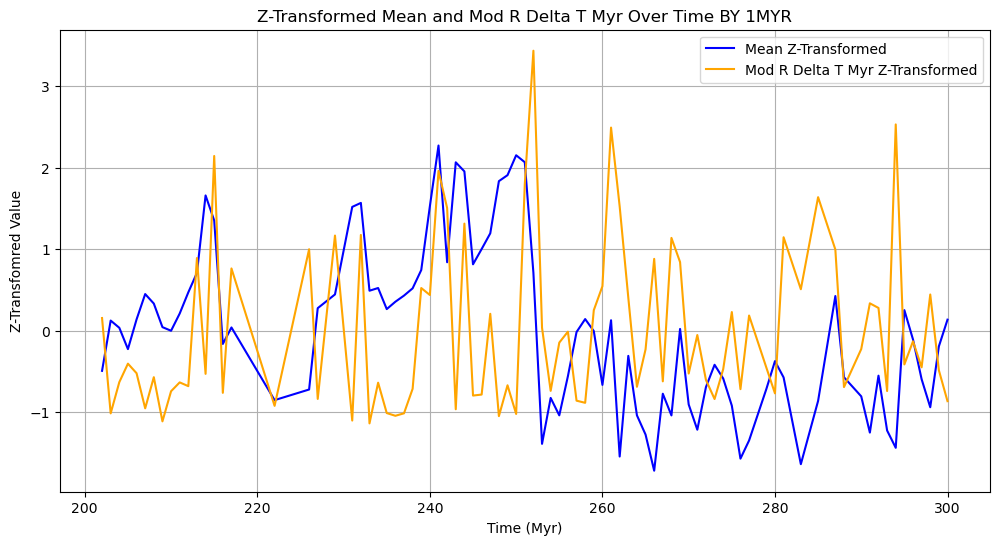

In [48]:
# Plotting the distribution of the mean_z_trans and Mod_R_deltaTMyr_z_trans columns as line plots
plt.figure(figsize=(12, 6))
plt.plot(isotopic_1myr_filtered['Time'], isotopic_1myr_filtered['mean_pt_1myr_z_trans'], label='Mean Z-Transformed', color='blue')
plt.plot(isotopic_1myr_filtered['Time'], isotopic_1myr_filtered['Mod_R_deltaTMyr_pt_1myr_z_trans'], label='Mod R Delta T Myr Z-Transformed', color='orange')
plt.title('Z-Transformed Mean and Mod R Delta T Myr Over Time BY 1MYR')
plt.xlabel('Time (Myr)')
plt.ylabel('Z-Transfomred Value')
plt.legend()
plt.grid()
plt.savefig('Perm-Trias/pt_data_visualizations/isotopic_pt_1myr_z_transformed_plot.png', dpi=600)
plt.show()
                        

In [56]:
isotopic_1myr_filtered

,Time,mean_pt_1myr,Mod_R_deltaTMyr_pt_1myr,mean_pt_1myr_z_trans,Mod_R_deltaTMyr_pt_1myr_z_trans
0,300,30.431385,0.496400,0.135311,-0.865252
1,299,29.392182,1.039204,-0.192132,-0.486496
2,298,27.019217,2.372964,-0.939830,0.444172
3,297,28.111086,1.091868,-0.595793,-0.449748
4,296,29.660536,1.549450,-0.107576,-0.130457
...,...,...,...,...,...
80,206,30.440487,0.988279,0.138179,-0.522030
81,205,29.284282,1.156205,-0.226130,-0.404855
82,204,30.114721,0.830439,0.035533,-0.632168
83,203,30.395986,0.281265,0.124157,-1.015368


In [57]:
isotopic_1myr_filtered_final = isotopic_1myr_filtered[['Time', 'mean_pt_1myr_z_trans', 'Mod_R_deltaTMyr_pt_1myr_z_trans']]
isotopic_1myr_filtered_final.to_csv("Perm-Trias/songEA_isotopic_data_pt_1myr/isotopic_1myr_filtered_final.txt", sep="\t", index=False)

### Adding to Backscale.txt

In [45]:
# Getting mean and std of the z-transformed columns
mean_mean = isotopic_1myr_filtered['mean_pt_1myr'].mean()
std_mean = isotopic_1myr_filtered['mean_pt_1myr'].std()
mean_Mod_R_deltaTMyr = isotopic_1myr_filtered['Mod_R_deltaTMyr_pt_1myr'].mean()
std_Mod_R_deltaTMyr = isotopic_1myr_filtered['Mod_R_deltaTMyr_pt_1myr'].std()

mean_mean, std_mean, mean_Mod_R_deltaTMyr, std_Mod_R_deltaTMyr

(30.00195020117647, 3.1925277166671604, 1.7364113529176473, 1.4416263255546373)

In [51]:
pt_rep_all_backscale = pd.read_csv("Perm-Trias/backscale_txts/pt_reptilia_all_backscale_final.txt", sep="\t")
pt_rep_terr_backscale = pd.read_csv("Perm-Trias/backscale_txts/pt_reptilia_terr_backscale_final.txt", sep="\t")
pt_synapsida_backscale = pd.read_csv("Perm-Trias/backscale_txts/pt_synapsida_backscale_final.txt", sep="\t")

pt_rep_all_backscale

,lat_range_z_trans,mean_gl_stages_z_trans,Mod_R_deltaTMyr_gl_stages_z_trans,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
0,4.474401,30.681321,1.785018,15.408586,1.544556,24.204728,7.265821,16.938907,2.426294,0.773897,1.652397
1,13.293794,4.045348,0.378153,10.057882,0.773211,9.568243,15.358677,17.109360,1.256015,0.435363,1.058917


In [52]:
backscales = [pt_rep_all_backscale, pt_rep_terr_backscale, pt_synapsida_backscale]
for df in backscales:
    df['mean_pt_1myr_z_trans'] = mean_mean
    df.loc[1, "mean_pt_1myr_z_trans"] = std_mean
    df['Mod_R_deltaTMyr_pt_1myr_z_trans'] = mean_Mod_R_deltaTMyr
    df.loc[1, "Mod_R_deltaTMyr_pt_1myr_z_trans"] = std_Mod_R_deltaTMyr
    

In [53]:
pt_rep_all_backscale

,lat_range_z_trans,mean_gl_stages_z_trans,Mod_R_deltaTMyr_gl_stages_z_trans,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans,mean_pt_1myr_z_trans,Mod_R_deltaTMyr_pt_1myr_z_trans
0,4.474401,30.681321,1.785018,15.408586,1.544556,24.204728,7.265821,16.938907,2.426294,0.773897,1.652397,30.001950,1.736411
1,13.293794,4.045348,0.378153,10.057882,0.773211,9.568243,15.358677,17.109360,1.256015,0.435363,1.058917,3.192528,1.441626


In [55]:
pt_rep_all_backscale.to_csv("Perm-Trias/backscale_txts/pt_reptilia_all_backscale_final.txt", sep="\t", index=False)
pt_rep_terr_backscale.to_csv("Perm-Trias/backscale_txts/pt_reptilia_terr_backscale_final.txt", sep="\t", index=False)
pt_synapsida_backscale.to_csv("Perm-Trias/backscale_txts/pt_synapsida_backscale_final.txt", sep="\t", index=False)

## Time-Series Data (BRIDGE, Stage)

In [49]:
reptilia_BRIDGE = pd.read_csv("AF_climactic_data/reptilia_terr_ClimVar_Bystage.csv")
synapsida_BRIDGE = pd.read_csv("AF_climactic_data/synapsida_ClimVar_Bystage.csv")


In [50]:
reptilia_BRIDGE

,time_bins,age_median,mat,map,wmm,cmm,wmmcmm,wetmon,drymon,wetdry
0,Anisian,244.068459,13.572186,1.063094,22.135437,6.014318,16.121119,1.490700,0.677930,0.812770
1,Artinskian,286.800000,28.441811,0.296123,29.938868,26.069955,3.868913,0.792081,0.010851,0.781230
2,Asselian,296.096000,11.740447,3.532841,12.603080,10.614780,1.988300,5.778464,1.511080,4.267385
3,Capitanian,261.559817,-2.444644,1.252862,11.016842,-13.094213,24.111055,2.020822,0.913160,1.107662
4,Carnian,231.903704,24.173980,1.924075,27.402139,20.934233,6.467906,3.232760,0.631016,2.601743
5,Changhsingian,253.003450,21.651270,0.902332,27.911245,16.212230,11.699015,1.019596,0.754662,0.264933
6,Hettangian,200.450000,21.605028,1.450444,32.876133,10.716254,22.159879,2.164926,0.518776,1.646150
7,Induan,250.031769,-1.572874,1.038018,26.702774,-26.272740,52.975515,1.902068,0.463126,1.438942
8,Kungurian,278.950000,23.417018,0.553246,25.231211,19.840961,5.390250,1.366519,0.036888,1.329632
9,Ladinian,239.342083,13.092836,1.729636,27.334872,1.193777,26.141096,2.344483,0.628879,1.715603


In [51]:
synapsida_BRIDGE

,time_bins,age_median,mat,map,wmm,cmm,wmmcmm,wetmon,drymon,wetdry
0,Anisian,243.953653,-0.411447,1.101593,23.553875,-21.287997,44.841872,1.762654,0.705240,1.057414
1,Artinskian,285.487500,23.964249,1.113407,25.275077,22.343493,2.931584,2.223679,0.164767,2.058912
2,Asselian,293.561282,24.329945,0.320354,25.612513,21.712729,3.899783,0.826773,0.005955,0.820818
3,Capitanian,261.553696,-7.369575,1.265884,15.643856,-25.749531,41.393387,2.519181,0.618585,1.900596
4,Carnian,232.051613,12.068748,2.180666,26.620331,-2.273815,28.894145,2.825358,0.957400,1.867957
5,Changhsingian,253.021000,2.907450,0.704774,5.383000,0.755005,4.627995,1.312052,0.450572,0.861480
6,Induan,249.826479,-4.168569,0.909242,37.715928,-40.154603,77.870532,1.771928,0.343196,1.428732
7,Kungurian,279.287662,24.561465,0.499732,26.286013,20.972991,5.313022,1.373929,0.000355,1.373574
8,Ladinian,239.495106,10.058921,0.882090,44.611579,-23.118434,67.730012,1.385638,0.123815,1.261823
9,Norian,217.703073,19.859099,0.668734,38.842957,0.200323,38.642634,1.049187,0.134477,0.914710


#### Adding proper time bin ages

In [52]:
# Reorder both in order ascending by 'age_median'
reptilia_BRIDGE = reptilia_BRIDGE.sort_values(by='age_median').reset_index(drop=True)
synapsida_BRIDGE = synapsida_BRIDGE.sort_values(by='age_median').reset_index(drop=True)

In [53]:
reptilia_BRIDGE

,time_bins,age_median,mat,map,wmm,cmm,wmmcmm,wetmon,drymon,wetdry
0,Hettangian,200.450000,21.605028,1.450444,32.876133,10.716254,22.159879,2.164926,0.518776,1.646150
1,Rhaetian,204.910417,24.488909,2.418243,32.591912,15.575254,17.016658,4.318783,0.934301,3.384481
2,Norian,217.577637,27.030298,1.903795,30.376893,24.334004,6.042889,3.147549,0.608602,2.538947
3,Carnian,231.903704,24.173980,1.924075,27.402139,20.934233,6.467906,3.232760,0.631016,2.601743
4,Ladinian,239.342083,13.092836,1.729636,27.334872,1.193777,26.141096,2.344483,0.628879,1.715603
5,Anisian,244.068459,13.572186,1.063094,22.135437,6.014318,16.121119,1.490700,0.677930,0.812770
6,Olenekian,248.766797,8.900449,1.525764,10.274552,6.154563,4.119989,2.242401,0.926201,1.316199
7,Induan,250.031769,-1.572874,1.038018,26.702774,-26.272740,52.975515,1.902068,0.463126,1.438942
8,Changhsingian,253.003450,21.651270,0.902332,27.911245,16.212230,11.699015,1.019596,0.754662,0.264933
9,Wuchiapingian,255.894970,7.944279,1.510061,39.879924,-19.045720,58.925644,1.811413,1.190361,0.621052


In [54]:
synapsida_BRIDGE

,time_bins,age_median,mat,map,wmm,cmm,wmmcmm,wetmon,drymon,wetdry
0,Rhaetian,204.950000,22.302474,2.365230,35.964574,8.280940,27.683634,4.519843,0.978698,3.541145
1,Norian,217.703073,19.859099,0.668734,38.842957,0.200323,38.642634,1.049187,0.134477,0.914710
2,Carnian,232.051613,12.068748,2.180666,26.620331,-2.273815,28.894145,2.825358,0.957400,1.867957
3,Ladinian,239.495106,10.058921,0.882090,44.611579,-23.118434,67.730012,1.385638,0.123815,1.261823
4,Anisian,243.953653,-0.411447,1.101593,23.553875,-21.287997,44.841872,1.762654,0.705240,1.057414
5,Olenekian,248.176316,-7.527689,0.851888,21.090347,-32.539021,53.629368,1.452150,0.404171,1.047978
6,Induan,249.826479,-4.168569,0.909242,37.715928,-40.154603,77.870532,1.771928,0.343196,1.428732
7,Changhsingian,253.021000,2.907450,0.704774,5.383000,0.755005,4.627995,1.312052,0.450572,0.861480
8,Wuchiapingian,256.523226,-2.034608,1.089521,38.137794,-36.258412,74.396205,1.887036,0.532699,1.354337
9,Capitanian,261.553696,-7.369575,1.265884,15.643856,-25.749531,41.393387,2.519181,0.618585,1.900596


Checking to see if time bin coverage is the same in both. Not necessary for analysis but good to know

In [55]:
reptilia_BRIDGE['time_bins'].isin(synapsida_BRIDGE['time_bins']).all()

False

In [56]:
synapsida_BRIDGE['time_bins'].isin(reptilia_BRIDGE['time_bins']).all()

False

In [57]:
# What time bins does reptilia_BRIDGE have that synapsida_BRIDGE does not?
reptilia_only_time_bins = reptilia_BRIDGE[~reptilia_BRIDGE['time_bins'].isin(synapsida_BRIDGE['time_bins'])]
synapsida_only_time_bins = synapsida_BRIDGE[~synapsida_BRIDGE['time_bins'].isin(reptilia_BRIDGE['time_bins'])]

print(f"reptilia only time bin: {reptilia_only_time_bins}")


reptilia only time bin:     time_bins  age_median        mat       map        wmm        cmm  \
0  Hettangian      200.45  21.605028  1.450444  32.876133  10.716254   

      wmmcmm    wetmon    drymon   wetdry  
0  22.159879  2.164926  0.518776  1.64615  


In [58]:
print(f"synapsida only time bin: {synapsida_only_time_bins}")

synapsida only time bin:     time_bins  age_median        mat       map        wmm        cmm  \
14  Sakmarian      290.46  21.991723  0.611073  23.568559  18.593423   

      wmmcmm    wetmon    drymon    wetdry  
14  4.975136  1.363418  0.015332  1.348086  


Both datasets have one time bin the other doesn't have.

In [59]:
time_bins = reptilia_BRIDGE['time_bins'].unique().tolist()
# append "Sakmarian" to second to last element
time_bins[-2] = "Sakmarian"
print(f"Time bins: {time_bins}")

Time bins: ['Hettangian', 'Rhaetian', 'Norian', 'Carnian', 'Ladinian', 'Anisian', 'Olenekian', 'Induan', 'Changhsingian', 'Wuchiapingian', 'Capitanian', 'Wordian', 'Roadian', 'Kungurian', 'Sakmarian', 'Asselian']


In [60]:
# Dictionary to map time bins to ages
time_bin_to_age = {
    "Hettangian":199.3,
    "Rhaetian":201.3,
    "Norian":208.5,
    "Carnian":227.0,
    "Ladinian":237.0,
    "Anisian":242.0,
    "Olenekian":247.2,
    "Induan":251.2,
    "Changhsingian":251.902,
    "Wuchiapingian":254.14,
    "Capitanian":259.1,
    "Wordian":265.1,
    "Roadian":268.8,
    "Kungurian":272.95,
    "Artinskian":283.5,
    "Sakmarian":290.1,
    "Asselian":293.52
}

In [61]:
# Create a new column in both dataframes called "Time" that contains the age corresponding to the time bin
# Make that column 3rd in the dataframe
reptilia_BRIDGE['Time'] = reptilia_BRIDGE['time_bins'].map(time_bin_to_age)
synapsida_BRIDGE['Time'] = synapsida_BRIDGE['time_bins'].map(time_bin_to_age)
# Reorder the columns so that "Time" is the 3rd column
reptilia_BRIDGE = reptilia_BRIDGE[['time_bins', 'age_median', 'Time', 'mat', 'map', 'wmm', 'cmm', 'wmmcmm', 'wetmon', 'drymon', 'wetdry']]
synapsida_BRIDGE = synapsida_BRIDGE[['time_bins', 'age_median', 'Time', 'mat', 'map', 'wmm', 'cmm', 'wmmcmm', 'wetmon', 'drymon', 'wetdry']]

In [62]:
reptilia_BRIDGE

,time_bins,age_median,Time,mat,map,wmm,cmm,wmmcmm,wetmon,drymon,wetdry
0,Hettangian,200.450000,199.300,21.605028,1.450444,32.876133,10.716254,22.159879,2.164926,0.518776,1.646150
1,Rhaetian,204.910417,201.300,24.488909,2.418243,32.591912,15.575254,17.016658,4.318783,0.934301,3.384481
2,Norian,217.577637,208.500,27.030298,1.903795,30.376893,24.334004,6.042889,3.147549,0.608602,2.538947
3,Carnian,231.903704,227.000,24.173980,1.924075,27.402139,20.934233,6.467906,3.232760,0.631016,2.601743
4,Ladinian,239.342083,237.000,13.092836,1.729636,27.334872,1.193777,26.141096,2.344483,0.628879,1.715603
5,Anisian,244.068459,242.000,13.572186,1.063094,22.135437,6.014318,16.121119,1.490700,0.677930,0.812770
6,Olenekian,248.766797,247.200,8.900449,1.525764,10.274552,6.154563,4.119989,2.242401,0.926201,1.316199
7,Induan,250.031769,251.200,-1.572874,1.038018,26.702774,-26.272740,52.975515,1.902068,0.463126,1.438942
8,Changhsingian,253.003450,251.902,21.651270,0.902332,27.911245,16.212230,11.699015,1.019596,0.754662,0.264933
9,Wuchiapingian,255.894970,254.140,7.944279,1.510061,39.879924,-19.045720,58.925644,1.811413,1.190361,0.621052


### Z-transformation

mat	map	wmm	cmm	wmmcmm	wetmon	drymon	wetdry

In [63]:
reptilia_BRIDGE_z_trans = reptilia_BRIDGE.copy()
synapsida_BRIDGE_z_trans = synapsida_BRIDGE.copy()

In [64]:
bridge_cols_list = ['mat', 'map', 'wmm', 'cmm', 'wmmcmm', 'wetmon', 'drymon', 'wetdry']
for col in bridge_cols_list:
    scaler_rep = StandardScaler()
    reptilia_BRIDGE_z_trans[col + '_z_trans'] = scaler_rep.fit_transform(reptilia_BRIDGE_z_trans[[col]])
    scaler_syn = StandardScaler()
    synapsida_BRIDGE_z_trans[col + '_z_trans'] = scaler_syn.fit_transform(synapsida_BRIDGE_z_trans[[col]])

In [65]:
reptilia_BRIDGE_z_trans

,time_bins,age_median,Time,mat,map,wmm,cmm,wmmcmm,wetmon,drymon,wetdry,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
0,Hettangian,200.450000,199.300,21.605028,1.450444,32.876133,10.716254,22.159879,2.164926,0.518776,1.646150,0.636283,-0.125708,0.935991,0.232025,0.315161,-0.214918,-0.605215,-0.006093
1,Rhaetian,204.910417,201.300,24.488909,2.418243,32.591912,15.575254,17.016658,4.318783,0.934301,3.384481,0.932415,1.167003,0.905312,0.558769,0.004693,1.556155,0.380521,1.689357
2,Norian,217.577637,208.500,27.030298,1.903795,30.376893,24.334004,6.042889,3.147549,0.608602,2.538947,1.193378,0.479843,0.666223,1.147751,-0.657731,0.593073,-0.392124,0.864681
3,Carnian,231.903704,227.000,24.173980,1.924075,27.402139,20.934233,6.467906,3.232760,0.631016,2.601743,0.900076,0.506932,0.345128,0.919133,-0.632075,0.663140,-0.338950,0.925927
4,Ladinian,239.342083,237.000,13.092836,1.729636,27.334872,1.193777,26.141096,2.344483,0.628879,1.715603,-0.237793,0.247215,0.337868,-0.408315,0.555484,-0.067271,-0.344020,0.061647
5,Anisian,244.068459,242.000,13.572186,1.063094,22.135437,6.014318,16.121119,1.490700,0.677930,0.812770,-0.188571,-0.643099,-0.223359,-0.084157,-0.049365,-0.769319,-0.227659,-0.818914
6,Olenekian,248.766797,247.200,8.900449,1.525764,10.274552,6.154563,4.119989,2.242401,0.926201,1.316199,-0.668289,-0.025101,-1.503622,-0.074727,-0.773806,-0.151212,0.361306,-0.327904
7,Induan,250.031769,251.200,-1.572874,1.038018,26.702774,-26.272740,52.975515,1.902068,0.463126,1.438942,-1.743744,-0.676594,0.269639,-2.255303,2.175327,-0.431060,-0.737231,-0.208189
8,Changhsingian,253.003450,251.902,21.651270,0.902332,27.911245,16.212230,11.699015,1.019596,0.754662,0.264933,0.641031,-0.857833,0.400081,0.601602,-0.316303,-1.156699,-0.045630,-1.353237
9,Wuchiapingian,255.894970,254.140,7.944279,1.510061,39.879924,-19.045720,58.925644,1.811413,1.190361,0.621052,-0.766474,-0.046076,1.691980,-1.769322,2.534502,-0.505604,0.987963,-1.005904


### Adding to Backscale.txt

mat_z_trans	map_z_trans	wmm_z_trans	cmm_z_trans	wmmcmm_z_trans	wetmon_z_trans	drymon_z_trans	wetdry_z_trans

In [61]:
# Loading in backscale files
pt_reptilia_all_backscale_lats_songEA_BRIDGE = pd.read_csv("Perm-Trias/backscale_txts/intermediate_backscale_txts/pt_reptilia_all_backscale_lats_songEA.txt", sep="\t")
pt_reptilia_terr_backscale_lats_songEA_BRIDGE = pd.read_csv("Perm-Trias/backscale_txts/intermediate_backscale_txts/pt_reptilia_terr_backscale_lats_songEA.txt", sep="\t")
pt_synapsida_backscale_lats_songEA_BRIDGE = pd.read_csv("Perm-Trias/backscale_txts/intermediate_backscale_txts/pt_synapsida_backscale_lats_songEA.txt", sep="\t")

gl_reptilia_all_backscale_lats_songEA_BRIDGE = pd.read_csv("Guad-Ladin/backscale_txts/intermediate_backscale_txts/gl_reptilia_all_backscale_lats_songEA.txt", sep="\t")
gl_reptilia_terr_backscale_lats_songEA_BRIDGE = pd.read_csv("Guad-Ladin/backscale_txts/intermediate_backscale_txts/gl_reptilia_terr_backscale_lats_songEA.txt", sep="\t")
gl_synapsida_backscale_lats_songEA_BRIDGE = pd.read_csv("Guad-Ladin/backscale_txts/intermediate_backscale_txts/gl_synapsida_backscale_lats_songEA.txt", sep="\t")

In [63]:
list_backscale_dfs_rep_BRIDGE = [pt_reptilia_all_backscale_lats_songEA_BRIDGE, 
                            pt_reptilia_terr_backscale_lats_songEA_BRIDGE, 
                            gl_reptilia_all_backscale_lats_songEA_BRIDGE, 
                            gl_reptilia_terr_backscale_lats_songEA_BRIDGE]

rep_BRIDGE_mat_mean = reptilia_BRIDGE['mat'].mean()
rep_BRIDGE_mat_std = reptilia_BRIDGE['mat'].std()
rep_BRIDGE_map_mean = reptilia_BRIDGE['map'].mean()
rep_BRIDGE_map_std = reptilia_BRIDGE['map'].std()
rep_BRIDGE_wmm_mean = reptilia_BRIDGE['wmm'].mean()
rep_BRIDGE_wmm_std = reptilia_BRIDGE['wmm'].std()
rep_BRIDGE_cmm_mean = reptilia_BRIDGE['cmm'].mean()
rep_BRIDGE_cmm_std = reptilia_BRIDGE['cmm'].std()
rep_BRIDGE_wmmcmm_mean = reptilia_BRIDGE['wmmcmm'].mean()
rep_BRIDGE_wmmcmm_std = reptilia_BRIDGE['wmmcmm'].std()
rep_BRIDGE_wetmon_mean = reptilia_BRIDGE['wetmon'].mean()
rep_BRIDGE_wetmon_std = reptilia_BRIDGE['wetmon'].std()
rep_BRIDGE_drymon_mean = reptilia_BRIDGE['drymon'].mean()
rep_BRIDGE_drymon_std = reptilia_BRIDGE['drymon'].std()
rep_BRIDGE_wetdry_mean = reptilia_BRIDGE['wetdry'].mean()
rep_BRIDGE_wetdry_std = reptilia_BRIDGE['wetdry'].std()

for df in list_backscale_dfs_rep_BRIDGE:
    df['mat_z_trans'] = [rep_BRIDGE_mat_mean, rep_BRIDGE_mat_std]
    df['map_z_trans'] = [rep_BRIDGE_map_mean, rep_BRIDGE_map_std]
    df['wmm_z_trans'] = [rep_BRIDGE_wmm_mean, rep_BRIDGE_wmm_std]
    df['cmm_z_trans'] = [rep_BRIDGE_cmm_mean, rep_BRIDGE_cmm_std]
    df['wmmcmm_z_trans'] = [rep_BRIDGE_wmmcmm_mean, rep_BRIDGE_wmmcmm_std]
    df['wetmon_z_trans'] = [rep_BRIDGE_wetmon_mean, rep_BRIDGE_wetmon_std]
    df['drymon_z_trans'] = [rep_BRIDGE_drymon_mean, rep_BRIDGE_drymon_std]
    df['wetdry_z_trans'] = [rep_BRIDGE_wetdry_mean, rep_BRIDGE_wetdry_std]


In [64]:
list_backscale_dfs_syn_BRIDGE = [pt_synapsida_backscale_lats_songEA_BRIDGE, 
                            gl_synapsida_backscale_lats_songEA_BRIDGE]

syn_BRIDGE_mat_mean = synapsida_BRIDGE['mat'].mean()
syn_BRIDGE_mat_std = synapsida_BRIDGE['mat'].std()
syn_BRIDGE_map_mean = synapsida_BRIDGE['map'].mean()
syn_BRIDGE_map_std = synapsida_BRIDGE['map'].std()
syn_BRIDGE_wmm_mean = synapsida_BRIDGE['wmm'].mean()
syn_BRIDGE_wmm_std = synapsida_BRIDGE['wmm'].std()
syn_BRIDGE_cmm_mean = synapsida_BRIDGE['cmm'].mean()
syn_BRIDGE_cmm_std = synapsida_BRIDGE['cmm'].std()
syn_BRIDGE_wmmcmm_mean = synapsida_BRIDGE['wmmcmm'].mean()
syn_BRIDGE_wmmcmm_std = synapsida_BRIDGE['wmmcmm'].std()
syn_BRIDGE_wetmon_mean = synapsida_BRIDGE['wetmon'].mean()
syn_BRIDGE_wetmon_std = synapsida_BRIDGE['wetmon'].std()
syn_BRIDGE_drymon_mean = synapsida_BRIDGE['drymon'].mean()
syn_BRIDGE_drymon_std = synapsida_BRIDGE['drymon'].std()
syn_BRIDGE_wetdry_mean = synapsida_BRIDGE['wetdry'].mean()
syn_BRIDGE_wetdry_std = synapsida_BRIDGE['wetdry'].std()

for df in list_backscale_dfs_syn_BRIDGE:
    df['mat_z_trans'] = [syn_BRIDGE_mat_mean, syn_BRIDGE_mat_std]
    df['map_z_trans'] = [syn_BRIDGE_map_mean, syn_BRIDGE_map_std]
    df['wmm_z_trans'] = [syn_BRIDGE_wmm_mean, syn_BRIDGE_wmm_std]
    df['cmm_z_trans'] = [syn_BRIDGE_cmm_mean, syn_BRIDGE_cmm_std]
    df['wmmcmm_z_trans'] = [syn_BRIDGE_wmmcmm_mean, syn_BRIDGE_wmmcmm_std]
    df['wetmon_z_trans'] = [syn_BRIDGE_wetmon_mean, syn_BRIDGE_wetmon_std]
    df['drymon_z_trans'] = [syn_BRIDGE_drymon_mean, syn_BRIDGE_drymon_std]
    df['wetdry_z_trans'] = [syn_BRIDGE_wetdry_mean, syn_BRIDGE_wetdry_std]


In [65]:
pt_reptilia_all_backscale_lats_songEA_BRIDGE

,lat_range_z_trans,mean_z_trans,Mod_R_deltaTMyr_z_trans,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
0,4.474401,30.681321,1.785018,15.408586,1.544556,24.204728,7.265821,16.938907,2.426294,0.773897,1.652397
1,13.293794,4.045348,0.378153,10.057882,0.773211,9.568243,15.358677,17.109360,1.256015,0.435363,1.058917


In [ ]:
# Save all the backscale dfs as .txt's
# DO NOT RE-RUN B/C IN THE "tIME-SERIES DATA (ISOTOPIC, 1MYR) SECTION, WE USE IT"
# pt_reptilia_all_backscale_lats_songEA_BRIDGE.to_csv("Perm-Trias/backscale_txts/pt_reptilia_all_backscale_final.txt", sep="\t", index=False)
# pt_reptilia_terr_backscale_lats_songEA_BRIDGE.to_csv("Perm-Trias/backscale_txts/pt_reptilia_terr_backscale_final.txt", sep="\t", index=False)
# pt_synapsida_backscale_lats_songEA_BRIDGE.to_csv("Perm-Trias/backscale_txts/pt_synapsida_backscale_final.txt", sep="\t", index=False)

# gl_reptilia_all_backscale_lats_songEA_BRIDGE.to_csv("Guad-Ladin/backscale_txts/gl_reptilia_all_backscale_final.txt", sep="\t", index=False)
# gl_reptilia_terr_backscale_lats_songEA_BRIDGE.to_csv("Guad-Ladin/backscale_txts/gl_reptilia_terr_backscale_final.txt", sep="\t", index=False)
# gl_synapsida_backscale_lats_songEA_BRIDGE.to_csv("Guad-Ladin/backscale_txts/gl_synapsida_backscale_final.txt", sep="\t", index=False)

### Visualizations

In [73]:
# Function for line plot of a list of columns in a dataframe
def plot_line_columns(df, x_col, y_cols, title, xlabel, path):
    plt.figure(figsize=(12, 10))
    for col in y_cols:
        plt.plot(df[x_col], df[col], label=col)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.legend()
    plt.grid()
    plt.savefig(path, dpi=600)
    plt.show()

    

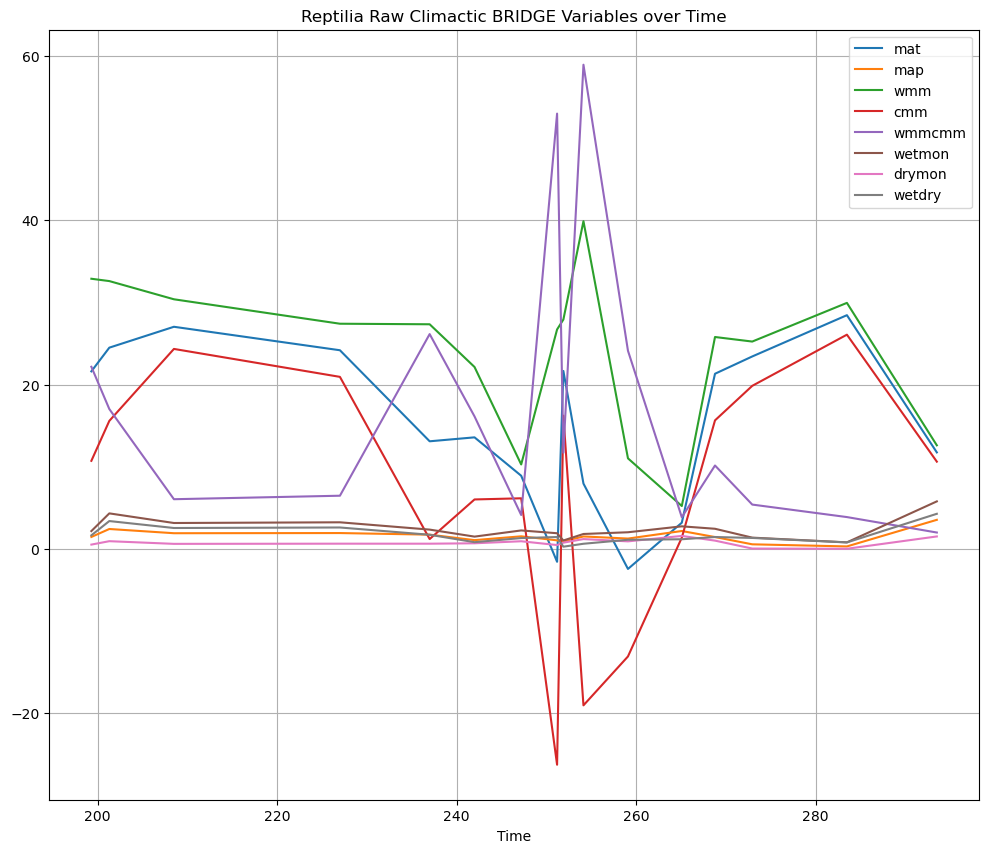

In [74]:
y_cols = ['mat', 'map', 'wmm', 'cmm', 'wmmcmm', 'wetmon', 'drymon', 'wetdry']
plot_line_columns(reptilia_BRIDGE_z_trans, 'Time', y_cols, "Reptilia Raw Climactic BRIDGE Variables over Time", "Time", 
                   "AF_climactic_data/AF_climactic_data_visualizations/reptilia_terr_raw_BRIDGE_variables_over_time.png")

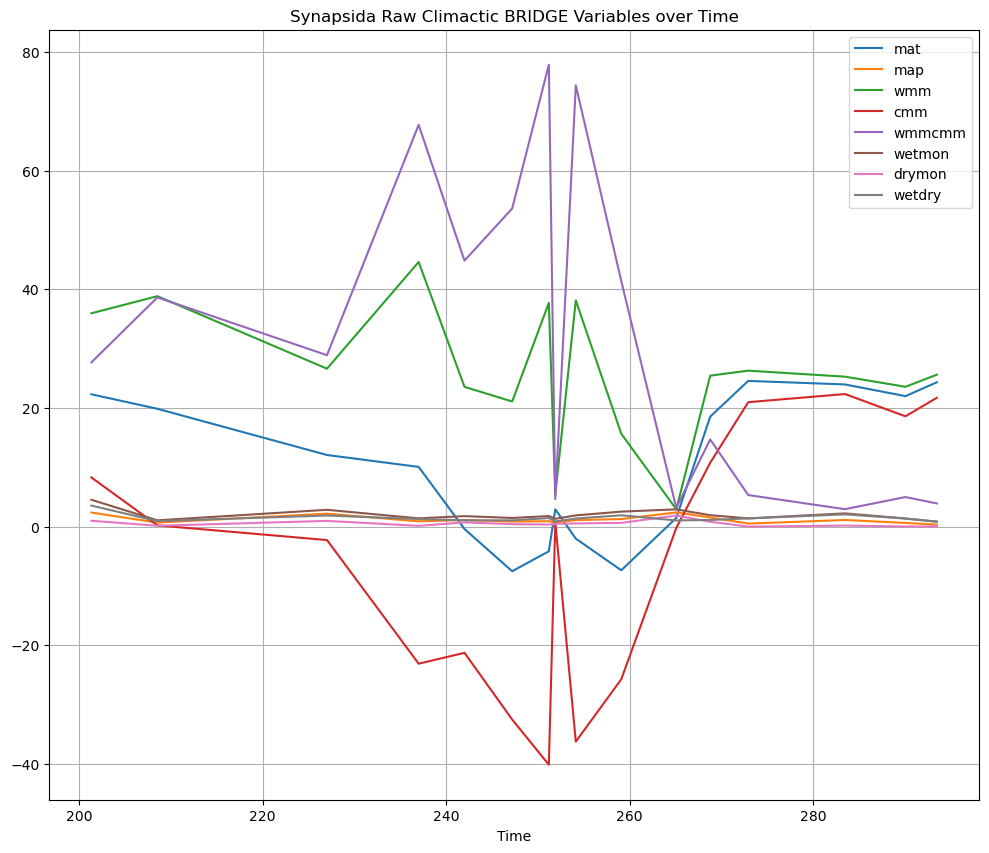

In [75]:
y_cols = ['mat', 'map', 'wmm', 'cmm', 'wmmcmm', 'wetmon', 'drymon', 'wetdry']
plot_line_columns(synapsida_BRIDGE_z_trans, 'Time', y_cols, "Synapsida Raw Climactic BRIDGE Variables over Time", "Time", 
                   "AF_climactic_data/AF_climactic_data_visualizations/synapsida_raw_BRIDGE_variables_over_time.png")

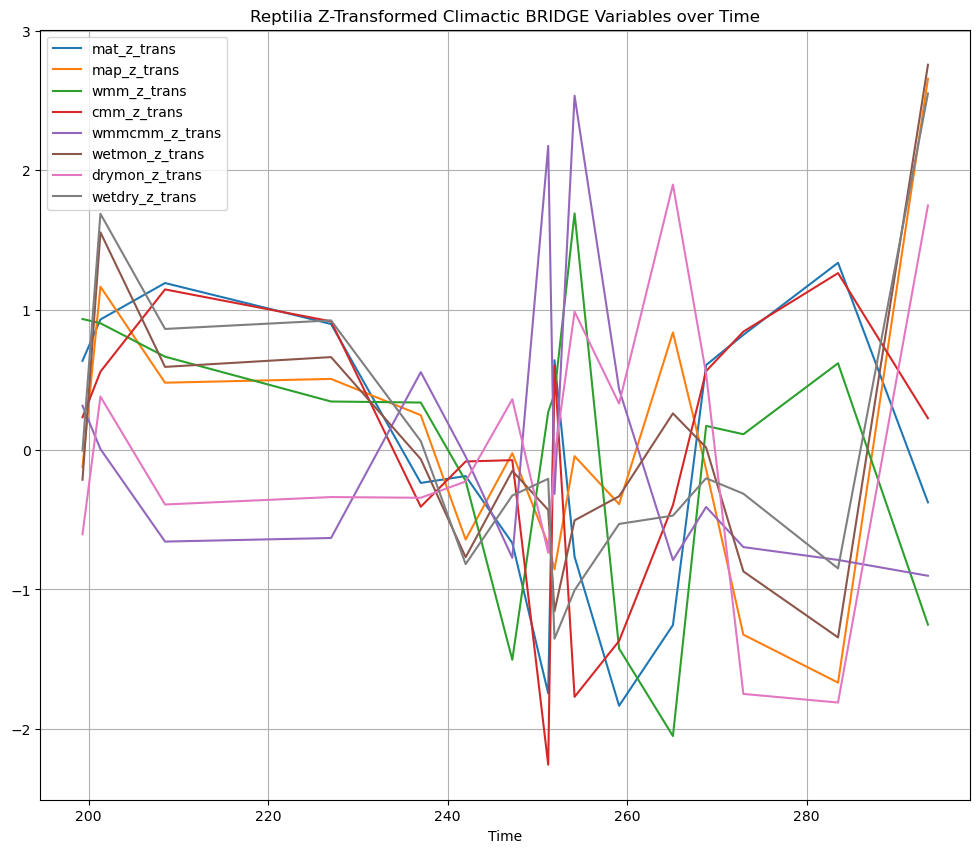

In [76]:
y_cols_z_trans = ['mat_z_trans', 'map_z_trans', 'wmm_z_trans', 'cmm_z_trans', 'wmmcmm_z_trans', 'wetmon_z_trans', 'drymon_z_trans', 'wetdry_z_trans']
plot_line_columns(reptilia_BRIDGE_z_trans, 'Time', y_cols_z_trans, "Reptilia Z-Transformed Climactic BRIDGE Variables over Time", "Time", 
                   "AF_climactic_data/AF_climactic_data_visualizations/reptilia_terr_z_trans_BRIDGE_variables_over_time.png")

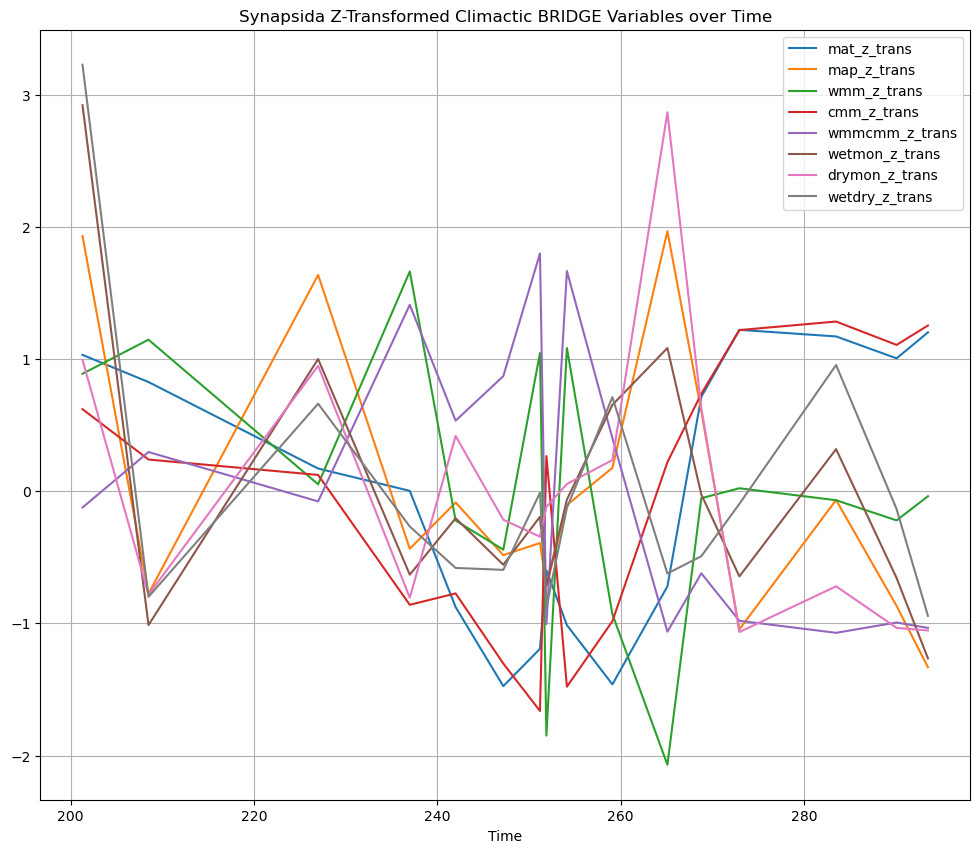

In [77]:
y_cols_z_trans = ['mat_z_trans', 'map_z_trans', 'wmm_z_trans', 'cmm_z_trans', 'wmmcmm_z_trans', 'wetmon_z_trans', 'drymon_z_trans', 'wetdry_z_trans']
plot_line_columns(synapsida_BRIDGE_z_trans, 'Time', y_cols_z_trans, "Synapsida Z-Transformed Climactic BRIDGE Variables over Time", "Time", 
                   "AF_climactic_data/AF_climactic_data_visualizations/synapsida_z_trans_BRIDGE_variables_over_time.png")

### Better Visualizations

In [ ]:
# Function for line plot of a list of columns in a dataframe
# Make it a 2 x 4 grid on one page
def plot_line_columns_grid(df, x_col, y_cols, title, xlabel, path):
    fig, axs = plt.subplots(4, 2, figsize=(12, 16))
    axs = axs.flatten()
    for i, col in enumerate(y_cols):
        axs[i].plot(df[x_col], df[col], label=col)
        axs[i].set_title(col)
        axs[i].grid()
    plt.suptitle(title, y=0.94)
    plt.xlabel(xlabel)
    plt.ylabel("Z-Transformed Value")
    # set y axis = 3
    for ax in axs:
        # ax.set_ylim(-3, 3) # Commented out for raw data to better visualize the data
        # Un comment for z transformed data
        ax.set_xlim(190,300)
    plt.savefig(path, dpi=600)
    plt.show()

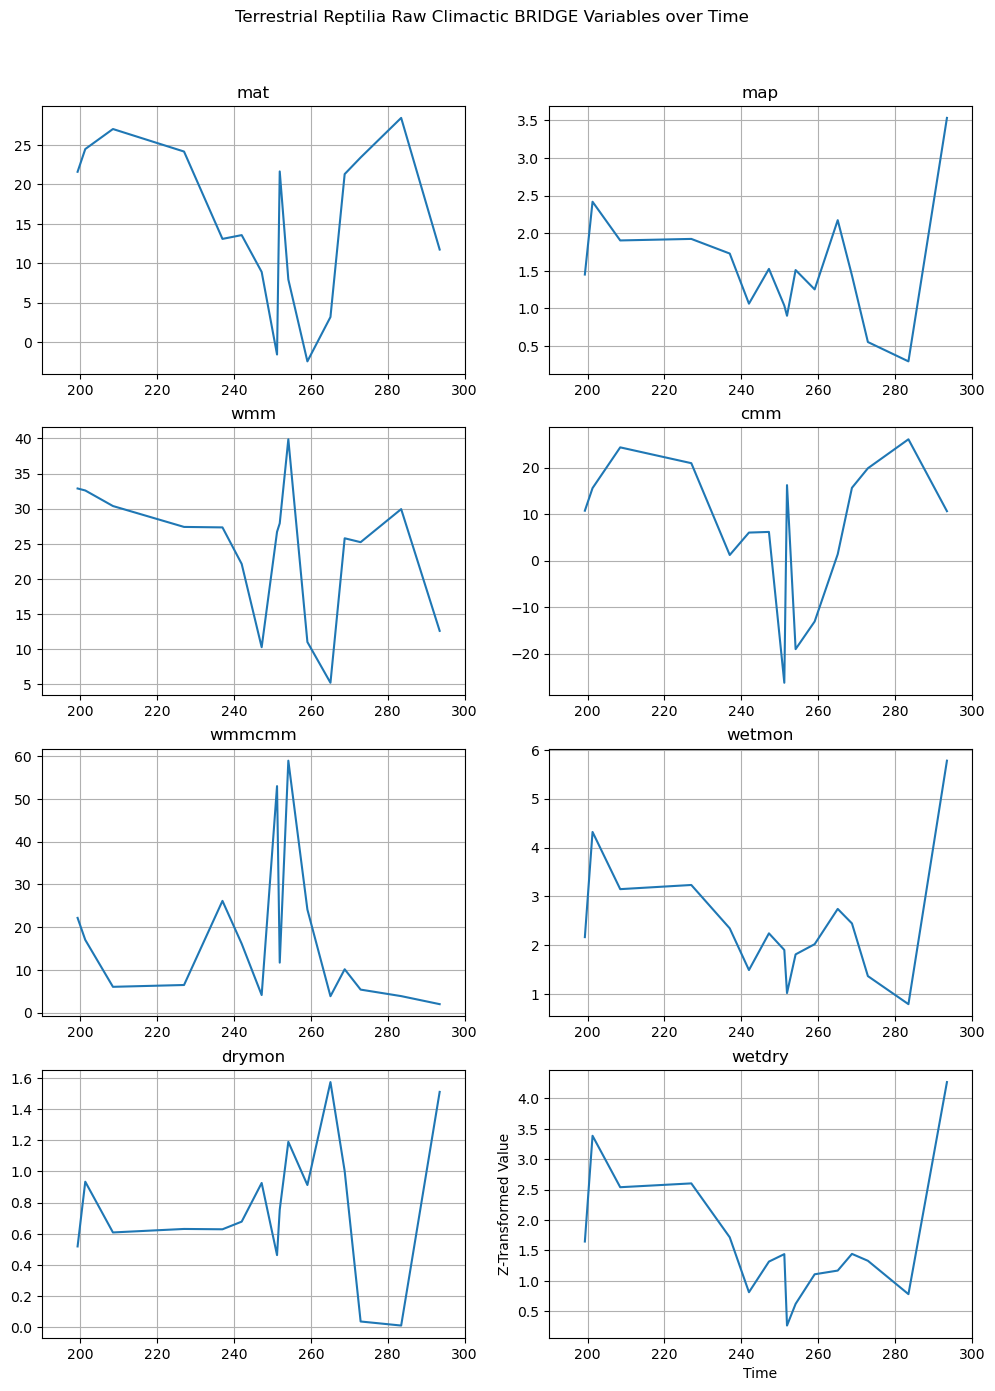

In [86]:
y_cols = ['mat', 'map', 'wmm', 'cmm', 'wmmcmm', 'wetmon', 'drymon', 'wetdry']
plot_line_columns_grid(reptilia_BRIDGE_z_trans, 'Time', y_cols, "Terrestrial Reptilia Raw Climactic BRIDGE Variables over Time", "Time", 
                   "AF_climactic_data/AF_climactic_data_visualizations/reptilia_terr_raw_BRIDGE_variables_over_time_grid.pdf")

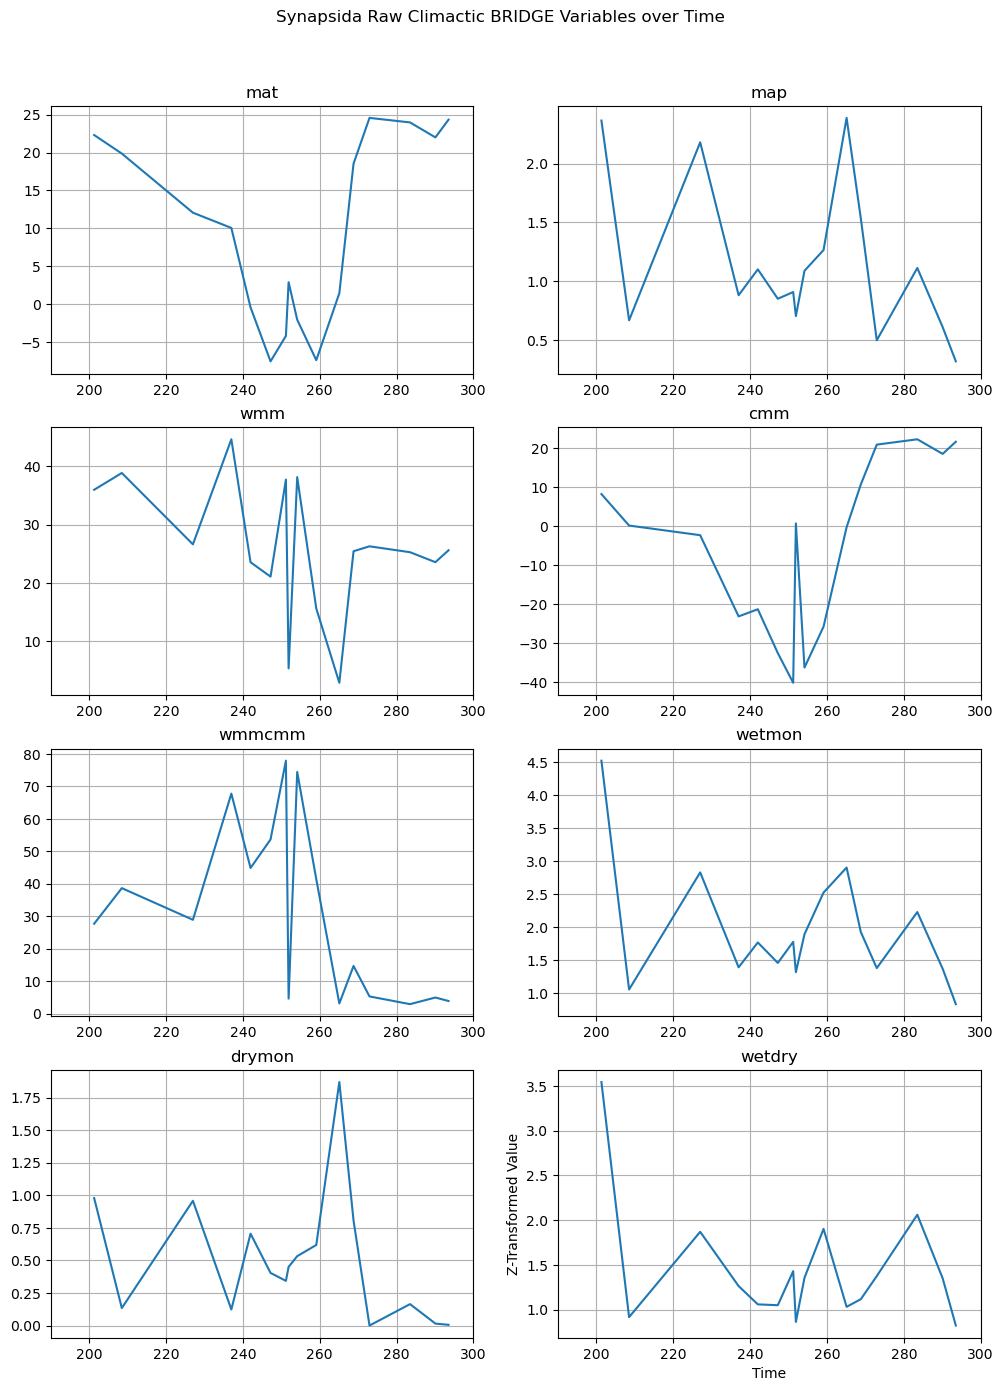

In [88]:
y_cols = ['mat', 'map', 'wmm', 'cmm', 'wmmcmm', 'wetmon', 'drymon', 'wetdry']
plot_line_columns_grid(synapsida_BRIDGE_z_trans, 'Time', y_cols, "Synapsida Raw Climactic BRIDGE Variables over Time", "Time", 
                   "AF_climactic_data/AF_climactic_data_visualizations/synapsida_raw_BRIDGE_variables_over_time_grid.pdf")

In [83]:
syn_BRIDGE_stage = pd.read_csv("AF_climactic_data/synapsida_BRIDGE_z_trans_filtered.csv")
rep_terr_BRIDGE_stage = pd.read_csv("AF_climactic_data/reptilia_terr_BRIDGE_z_trans_filtered.csv")
rep_terr_BRIDGE_stage.head()

,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
0,199.3,0.636283,-0.125708,0.935991,0.232025,0.315161,-0.214918,-0.605215,-0.006093
1,201.3,0.932415,1.167003,0.905312,0.558769,0.004693,1.556155,0.380521,1.689357
2,208.5,1.193378,0.479843,0.666223,1.147751,-0.657731,0.593073,-0.392124,0.864681
3,227.0,0.900076,0.506932,0.345128,0.919133,-0.632075,0.663140,-0.338950,0.925927
4,237.0,-0.237793,0.247215,0.337868,-0.408315,0.555484,-0.067271,-0.344020,0.061647


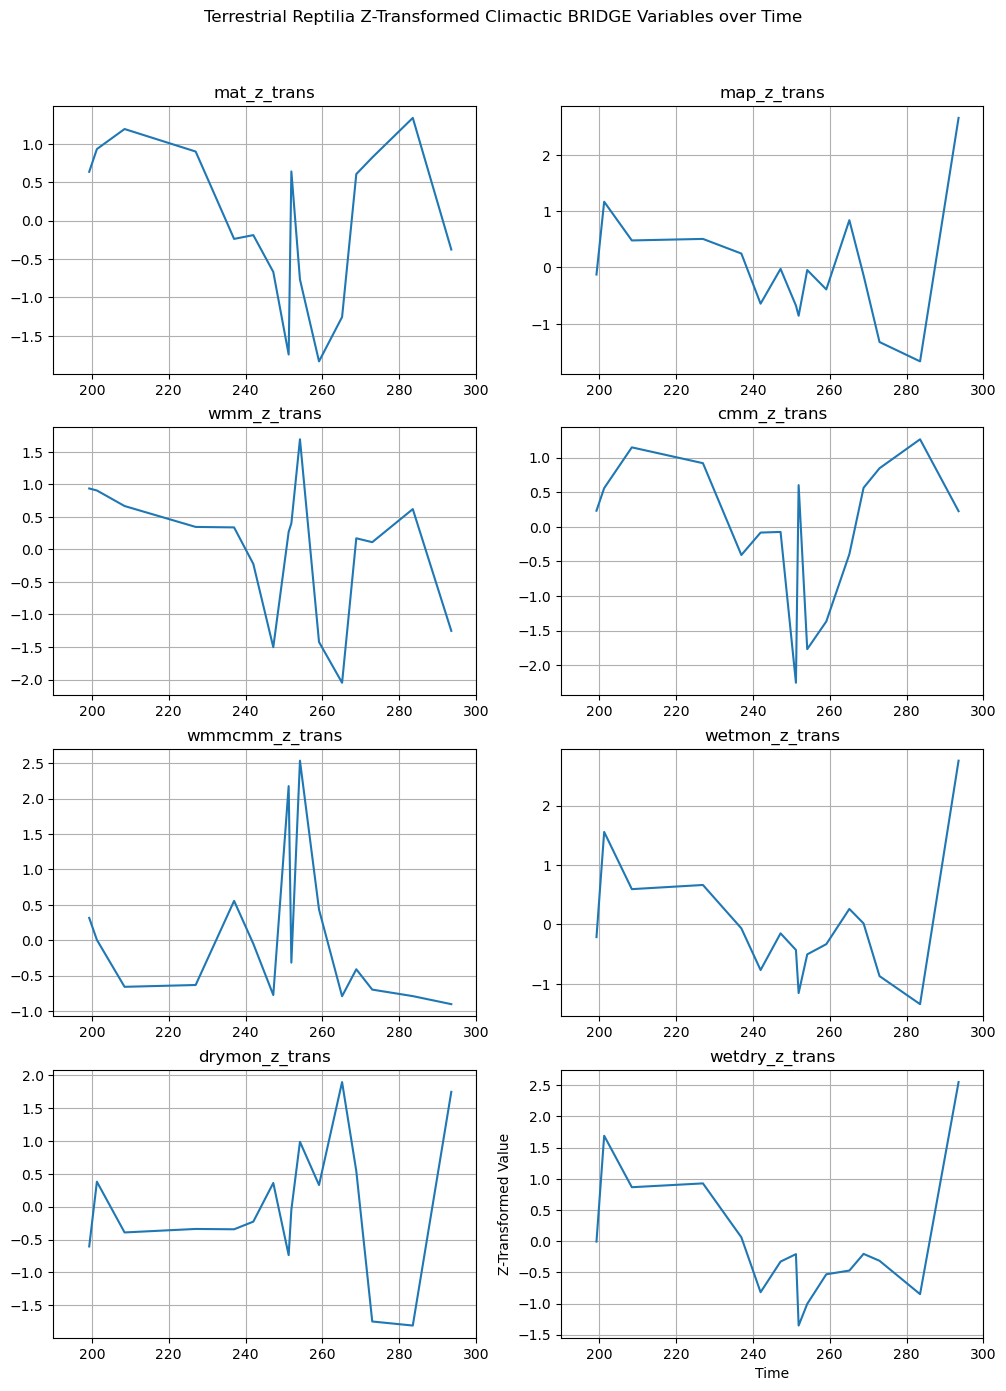

In [89]:
y_cols_z_trans = ['mat_z_trans', 'map_z_trans', 'wmm_z_trans', 'cmm_z_trans', 'wmmcmm_z_trans', 'wetmon_z_trans', 'drymon_z_trans', 'wetdry_z_trans']
plot_line_columns_grid(rep_terr_BRIDGE_stage, 'Time', y_cols_z_trans, "Terrestrial Reptilia Z-Transformed Climactic BRIDGE Variables over Time", "Time", 
                   "AF_climactic_data/AF_climactic_data_visualizations/reptilia_terr_z_trans_BRIDGE_variables_over_time_grid.pdf")

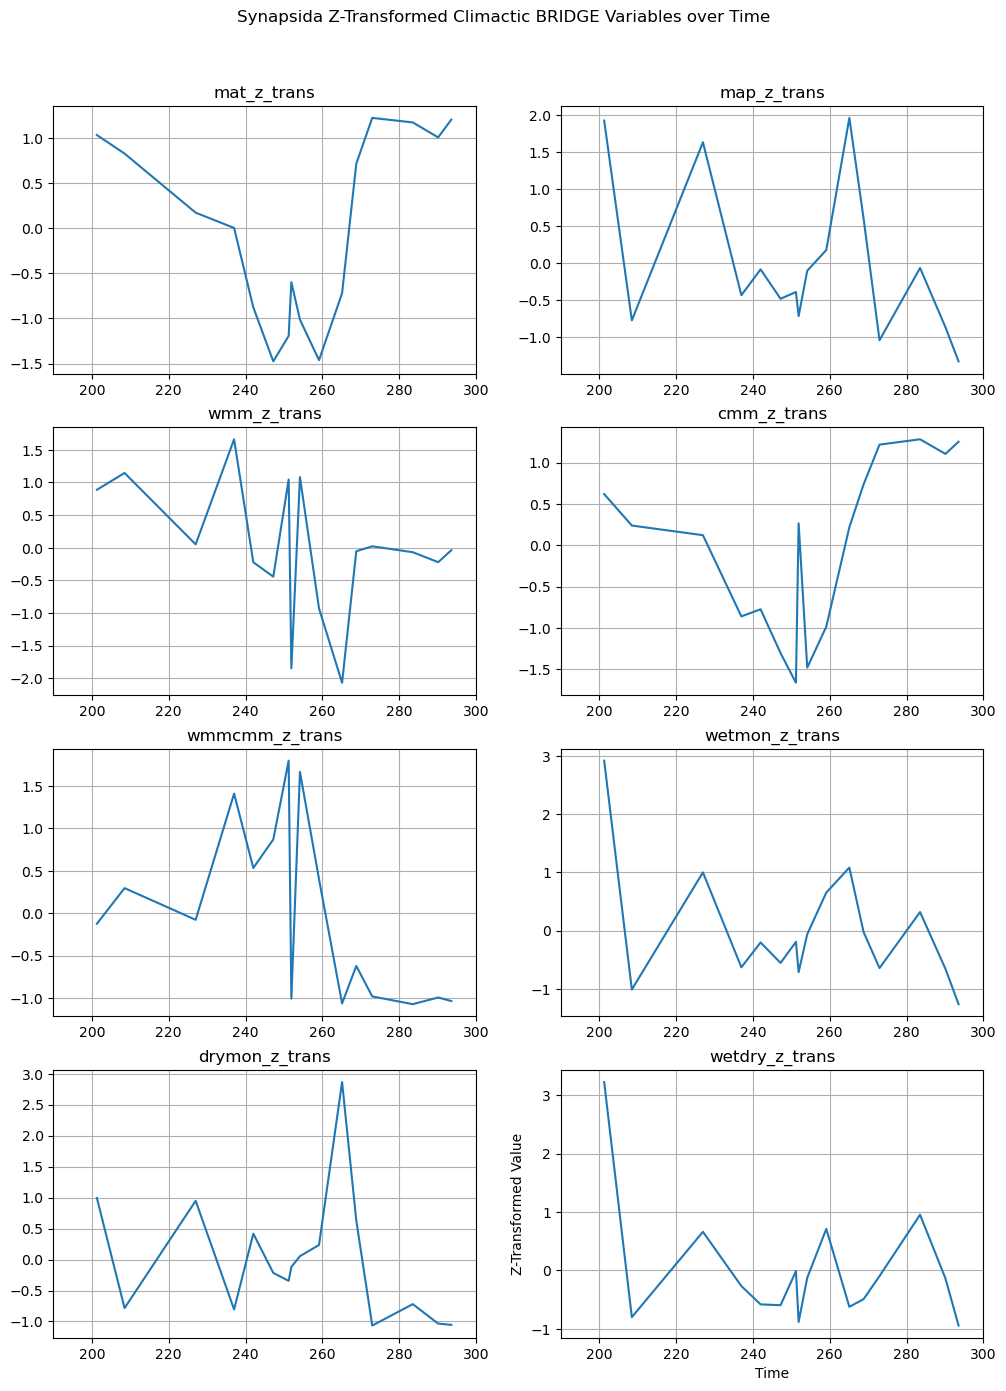

In [90]:
y_cols_z_trans = ['mat_z_trans', 'map_z_trans', 'wmm_z_trans', 'cmm_z_trans', 'wmmcmm_z_trans', 'wetmon_z_trans', 'drymon_z_trans', 'wetdry_z_trans']
plot_line_columns_grid(syn_BRIDGE_stage, 'Time', y_cols_z_trans, "Synapsida Z-Transformed Climactic BRIDGE Variables over Time", "Time", 
                   "AF_climactic_data/AF_climactic_data_visualizations/synapsida_z_trans_BRIDGE_variables_over_time_grid.pdf")

### Filtering and Saving

In [323]:
reptilia_BRIDGE_z_trans_filtered = reptilia_BRIDGE_z_trans[['Time', 'mat_z_trans','map_z_trans','wmm_z_trans','cmm_z_trans','wmmcmm_z_trans','wetmon_z_trans','drymon_z_trans','wetdry_z_trans']]
synapsida_BRIDGE_z_trans_filtered = synapsida_BRIDGE_z_trans[['Time', 'mat_z_trans','map_z_trans','wmm_z_trans','cmm_z_trans','wmmcmm_z_trans','wetmon_z_trans','drymon_z_trans','wetdry_z_trans']]

In [324]:
reptilia_BRIDGE_z_trans_filtered

,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
0,199.300,0.636283,-0.125708,0.935991,0.232025,0.315161,-0.214918,-0.605215,-0.006093
1,201.300,0.932415,1.167003,0.905312,0.558769,0.004693,1.556155,0.380521,1.689357
2,208.500,1.193378,0.479843,0.666223,1.147751,-0.657731,0.593073,-0.392124,0.864681
3,227.000,0.900076,0.506932,0.345128,0.919133,-0.632075,0.663140,-0.338950,0.925927
4,237.000,-0.237793,0.247215,0.337868,-0.408315,0.555484,-0.067271,-0.344020,0.061647
5,242.000,-0.188571,-0.643099,-0.223359,-0.084157,-0.049365,-0.769319,-0.227659,-0.818914
6,247.200,-0.668289,-0.025101,-1.503622,-0.074727,-0.773806,-0.151212,0.361306,-0.327904
7,251.200,-1.743744,-0.676594,0.269639,-2.255303,2.175327,-0.431060,-0.737231,-0.208189
8,251.902,0.641031,-0.857833,0.400081,0.601602,-0.316303,-1.156699,-0.045630,-1.353237
9,254.140,-0.766474,-0.046076,1.691980,-1.769322,2.534502,-0.505604,0.987963,-1.005904


In [325]:
synapsida_BRIDGE_z_trans_filtered

,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
0,201.300,1.030603,1.929754,0.888025,0.620072,-0.123821,2.919459,0.992889,3.225505
1,208.500,0.825377,-0.776213,1.145625,0.239217,0.295842,-1.013082,-0.783553,-0.799552
2,227.000,0.171044,1.635367,0.051764,0.122606,-0.077466,0.999467,0.948074,0.661316
3,237.000,0.002233,-0.435904,1.661887,-0.859841,1.409713,-0.631855,-0.805989,-0.267595
4,242.000,-0.877202,-0.085790,-0.222668,-0.773569,0.533235,-0.204664,0.417469,-0.580856
5,247.200,-1.474915,-0.484077,-0.443140,-1.303851,0.869743,-0.556491,-0.216052,-0.595315
6,251.200,-1.192773,-0.392594,1.044762,-1.662788,1.798033,-0.194156,-0.344357,-0.011804
7,251.902,-0.598439,-0.718728,-1.848866,0.265360,-1.006713,-0.715233,-0.118413,-0.881127
8,254.140,-1.013536,-0.105045,1.082517,-1.479153,1.664987,-0.063729,0.054401,-0.125815
9,259.100,-1.461635,0.176261,-0.930573,-0.983850,0.401179,0.652544,0.235127,0.711336


In [348]:
reptilia_BRIDGE_z_trans_filtered.to_csv("AF_climactic_data/reptilia_terr_BRIDGE_z_trans_filtered.txt", sep="\t", index=False)
synapsida_BRIDGE_z_trans_filtered.to_csv("AF_climactic_data/synapsida_BRIDGE_z_trans_filtered.txt", sep="\t", index=False)

In [349]:
# Also saving as csv for easier reading
reptilia_BRIDGE_z_trans_filtered.to_csv("AF_climactic_data/reptilia_terr_BRIDGE_z_trans_filtered.csv", index=False)
synapsida_BRIDGE_z_trans_filtered.to_csv("AF_climactic_data/synapsida_BRIDGE_z_trans_filtered.csv", index=False)

### 1 Myr Extension

In [89]:
reptilia_BRIDGE_z_trans_filtered = pd.read_csv("AF_climactic_data/reptilia_terr_BRIDGE_z_trans_filtered.csv")
synapsida_BRIDGE_z_trans_filtered = pd.read_csv("AF_climactic_data/synapsida_BRIDGE_z_trans_filtered.csv")  


In [90]:
reptilia_BRIDGE_z_trans_filtered

,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
0,199.300,0.636283,-0.125708,0.935991,0.232025,0.315161,-0.214918,-0.605215,-0.006093
1,201.300,0.932415,1.167003,0.905312,0.558769,0.004693,1.556155,0.380521,1.689357
2,208.500,1.193378,0.479843,0.666223,1.147751,-0.657731,0.593073,-0.392124,0.864681
3,227.000,0.900076,0.506932,0.345128,0.919133,-0.632075,0.663140,-0.338950,0.925927
4,237.000,-0.237793,0.247215,0.337868,-0.408315,0.555484,-0.067271,-0.344020,0.061647
5,242.000,-0.188571,-0.643099,-0.223359,-0.084157,-0.049365,-0.769319,-0.227659,-0.818914
6,247.200,-0.668289,-0.025101,-1.503622,-0.074727,-0.773806,-0.151212,0.361306,-0.327904
7,251.200,-1.743744,-0.676594,0.269639,-2.255303,2.175327,-0.431060,-0.737231,-0.208189
8,251.902,0.641031,-0.857833,0.400081,0.601602,-0.316303,-1.156699,-0.045630,-1.353237
9,254.140,-0.766474,-0.046076,1.691980,-1.769322,2.534502,-0.505604,0.987963,-1.005904


In [87]:
rep_time_range_1myr = pd.DataFrame({'Time': range(200,294)})
rep_time_range_1myr

,Time
0,200
1,201
2,202
3,203
4,204
...,...
89,289
90,290
91,291
92,292


In [91]:
reptilia_BRIDGE_z_trans_filtered_1myr = pd.merge(rep_time_range_1myr, reptilia_BRIDGE_z_trans_filtered, on='Time', how='outer')
reptilia_BRIDGE_z_trans_filtered_1myr = reptilia_BRIDGE_z_trans_filtered_1myr.sort_values(by='Time').reset_index(drop=True)
reptilia_BRIDGE_z_trans_filtered_1myr

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_25124\261469693.py:1: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  reptilia_BRIDGE_z_trans_filtered_1myr = pd.merge(rep_time_range_1myr, reptilia_BRIDGE_z_trans_filtered, on='Time', how='outer')


,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
0,199.30,0.636283,-0.125708,0.935991,0.232025,0.315161,-0.214918,-0.605215,-0.006093
1,200.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,201.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,201.30,0.932415,1.167003,0.905312,0.558769,0.004693,1.556155,0.380521,1.689357
4,202.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
102,290.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
103,291.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
104,292.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
105,293.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [102]:
subset = reptilia_BRIDGE_z_trans_filtered_1myr[reptilia_BRIDGE_z_trans_filtered_1myr['Time'].isin(reptilia_BRIDGE_z_trans_filtered['Time'])]
# drop index
subset = subset.reset_index(drop=True)
subset == reptilia_BRIDGE_z_trans_filtered

,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
0,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True
5,True,True,True,True,True,True,True,True,True
6,True,True,True,True,True,True,True,True,True
7,True,True,True,True,True,True,True,True,True
8,True,True,True,True,True,True,True,True,True
9,True,True,True,True,True,True,True,True,True


In [ ]:
# commented out to avoid re-running and overwriting the file
# reptilia_BRIDGE_z_trans_filtered_1myr.to_csv("AF_climactic_data/reptilia_terr_BRIDGE_z_trans_filtered_1myr.csv", index=False)

In [111]:
synapsida_BRIDGE_z_trans_filtered.describe()

,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
count,16.000000,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01
mean,253.332000,-3.469447e-17,5.551115e-17,-8.326673e-17,2.775558e-17,-5.551115e-17,-1.110223e-16,5.551115e-17,1.110223e-16
std,26.487172,1.032796e+00,1.032796e+00,1.032796e+00,1.032796e+00,1.032796e+00,1.032796e+00,1.032796e+00,1.032796e+00
min,201.300000,-1.474915e+00,-1.331892e+00,-2.069371e+00,-1.662788e+00,-1.071675e+00,-1.265095e+00,-1.065778e+00,-9.434420e-01
25%,240.750000,-9.112857e-01,-7.330992e-01,-2.777859e-01,-8.908430e-01,-9.967427e-01,-6.480998e-01,-7.891618e-01,-6.021790e-01
50%,253.021000,8.663836e-02,-2.488195e-01,-4.591203e-02,2.289540e-01,-1.006437e-01,-1.994101e-01,-1.672323e-01,-2.014949e-01
75%,269.837500,1.011027e+00,2.832189e-01,9.272094e-01,8.290625e-01,6.173623e-01,4.014224e-01,4.703514e-01,1.564762e-01
max,293.520000,1.220342e+00,1.965673e+00,1.661887e+00,1.282867e+00,1.798033e+00,2.919459e+00,2.865256e+00,3.225505e+00


In [113]:
syn_time_range_1myr = pd.DataFrame({'Time': range(202,294)})
syn_time_range_1myr

,Time
0,202
1,203
2,204
3,205
4,206
...,...
87,289
88,290
89,291
90,292


In [114]:
synapsida_BRIDGE_z_trans_filtered_1myr = pd.merge(syn_time_range_1myr, synapsida_BRIDGE_z_trans_filtered, on='Time', how='outer')
synapsida_BRIDGE_z_trans_filtered_1myr = synapsida_BRIDGE_z_trans_filtered_1myr.sort_values(by='Time').reset_index(drop=True)
synapsida_BRIDGE_z_trans_filtered_1myr

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_25124\400155805.py:1: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  synapsida_BRIDGE_z_trans_filtered_1myr = pd.merge(syn_time_range_1myr, synapsida_BRIDGE_z_trans_filtered, on='Time', how='outer')


,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
0,201.30,1.030603,1.929754,0.888025,0.620072,-0.123821,2.919459,0.992889,3.225505
1,202.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,203.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,204.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,205.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
100,290.10,1.004502,-0.868185,-0.221353,1.106119,-0.993419,-0.657032,-1.034263,-0.135395
101,291.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
102,292.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
103,293.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [115]:
subset = synapsida_BRIDGE_z_trans_filtered_1myr[synapsida_BRIDGE_z_trans_filtered_1myr['Time'].isin(synapsida_BRIDGE_z_trans_filtered['Time'])]
# drop index
subset = subset.reset_index(drop=True)
subset == synapsida_BRIDGE_z_trans_filtered

,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
0,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True
5,True,True,True,True,True,True,True,True,True
6,True,True,True,True,True,True,True,True,True
7,True,True,True,True,True,True,True,True,True
8,True,True,True,True,True,True,True,True,True
9,True,True,True,True,True,True,True,True,True


In [ ]:
# commented out to avoid re-running and overwriting the file
# synapsida_BRIDGE_z_trans_filtered_1myr.to_csv("AF_climactic_data/synapsida_BRIDGE_z_trans_filtered_1myr.csv", index=False)

#### Visualizations

In [91]:
syn_BRIDGE_1myr = pd.read_csv("AF_climactic_data/synapsida_BRIDGE_z_trans_filtered_1myr.csv")
rep_terr_BRIDGE_1myr = pd.read_csv("AF_climactic_data/reptilia_terr_BRIDGE_z_trans_filtered_1myr.csv")
rep_terr_BRIDGE_1myr.head()

,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
0,199.3,0.636283,-0.125708,0.935991,0.232025,0.315161,-0.214918,-0.605215,-0.006093
1,200.0,0.636283,-0.125708,0.935991,0.232025,0.315161,-0.214918,-0.605215,-0.006093
2,201.0,0.636283,-0.125708,0.935991,0.232025,0.315161,-0.214918,-0.605215,-0.006093
3,201.3,0.932415,1.167003,0.905312,0.558769,0.004693,1.556155,0.380521,1.689357
4,202.0,0.932415,1.167003,0.905312,0.558769,0.004693,1.556155,0.380521,1.689357


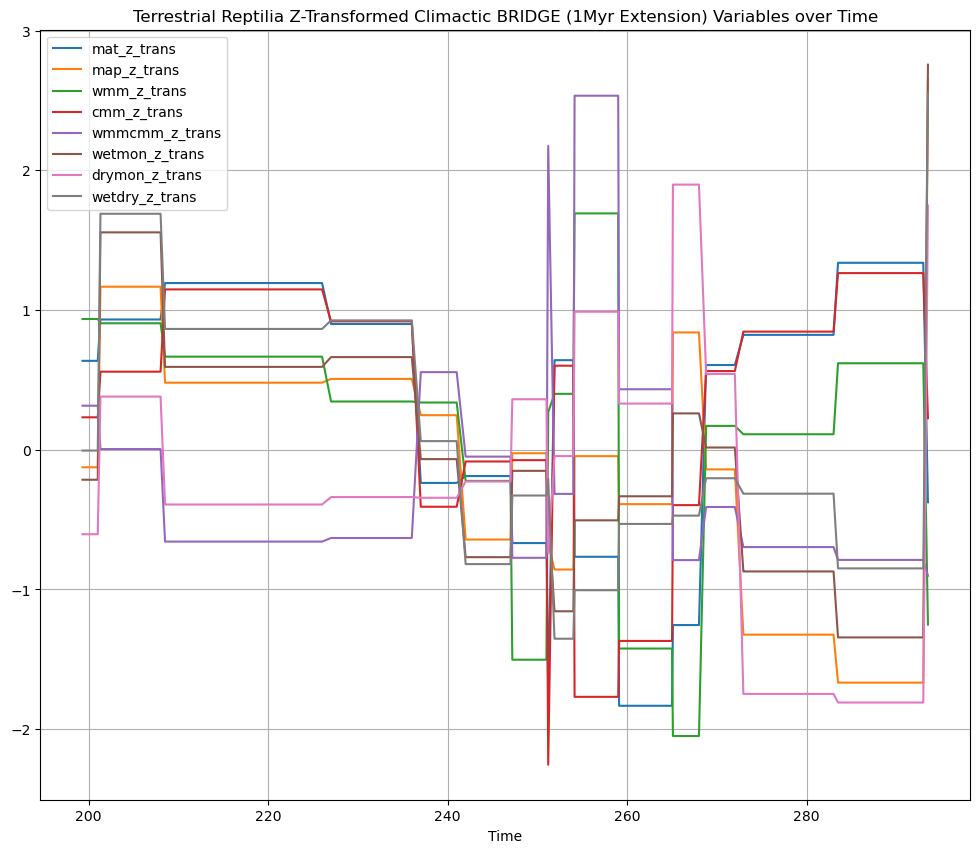

In [96]:
y_cols_z_trans = ['mat_z_trans', 'map_z_trans', 'wmm_z_trans', 'cmm_z_trans', 'wmmcmm_z_trans', 'wetmon_z_trans', 'drymon_z_trans', 'wetdry_z_trans']
plot_line_columns(rep_terr_BRIDGE_1myr, 'Time', y_cols_z_trans, "Terrestrial Reptilia Z-Transformed Climactic BRIDGE (1Myr Extension) Variables over Time", "Time", 
                   "AF_climactic_data/AF_climactic_data_visualizations/reptilia_terr_z_trans_BRIDGE_1Myr_variables_over_time.pdf")

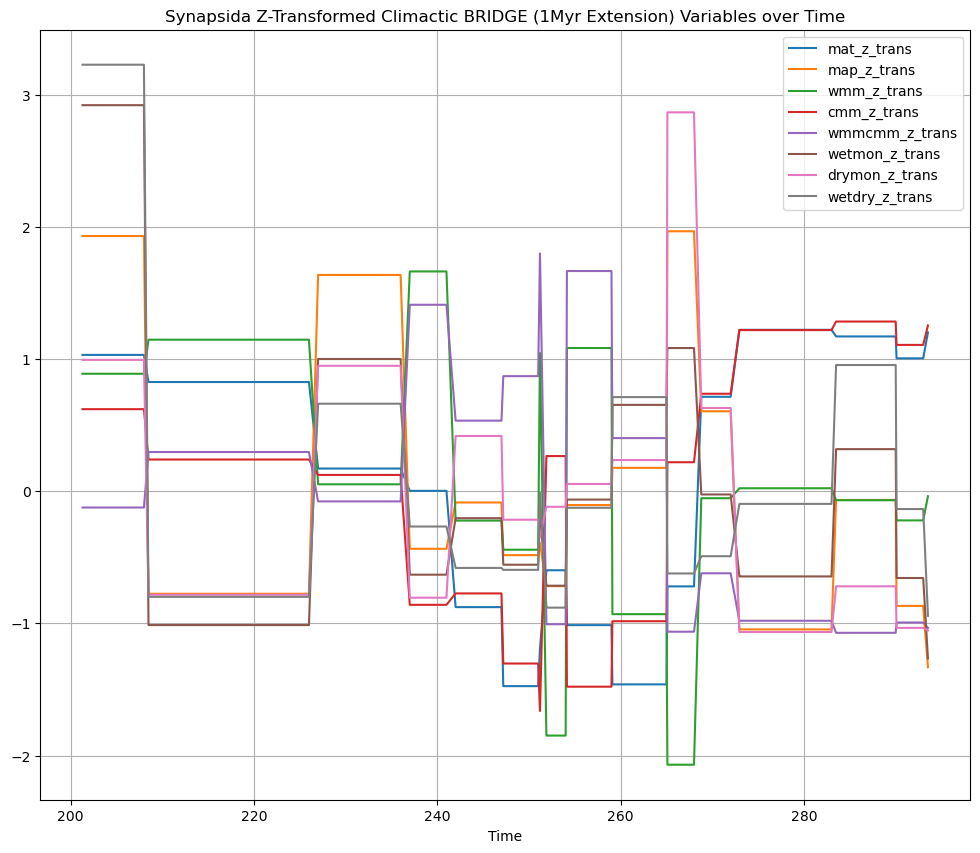

In [97]:
y_cols_z_trans = ['mat_z_trans', 'map_z_trans', 'wmm_z_trans', 'cmm_z_trans', 'wmmcmm_z_trans', 'wetmon_z_trans', 'drymon_z_trans', 'wetdry_z_trans']
plot_line_columns(syn_BRIDGE_1myr, 'Time', y_cols_z_trans, "Synapsida Z-Transformed Climactic BRIDGE (1Myr Extension) Variables over Time", "Time", 
                   "AF_climactic_data/AF_climactic_data_visualizations/synapsida_z_trans_BRIDGE_1Myr_variables_over_time.pdf")

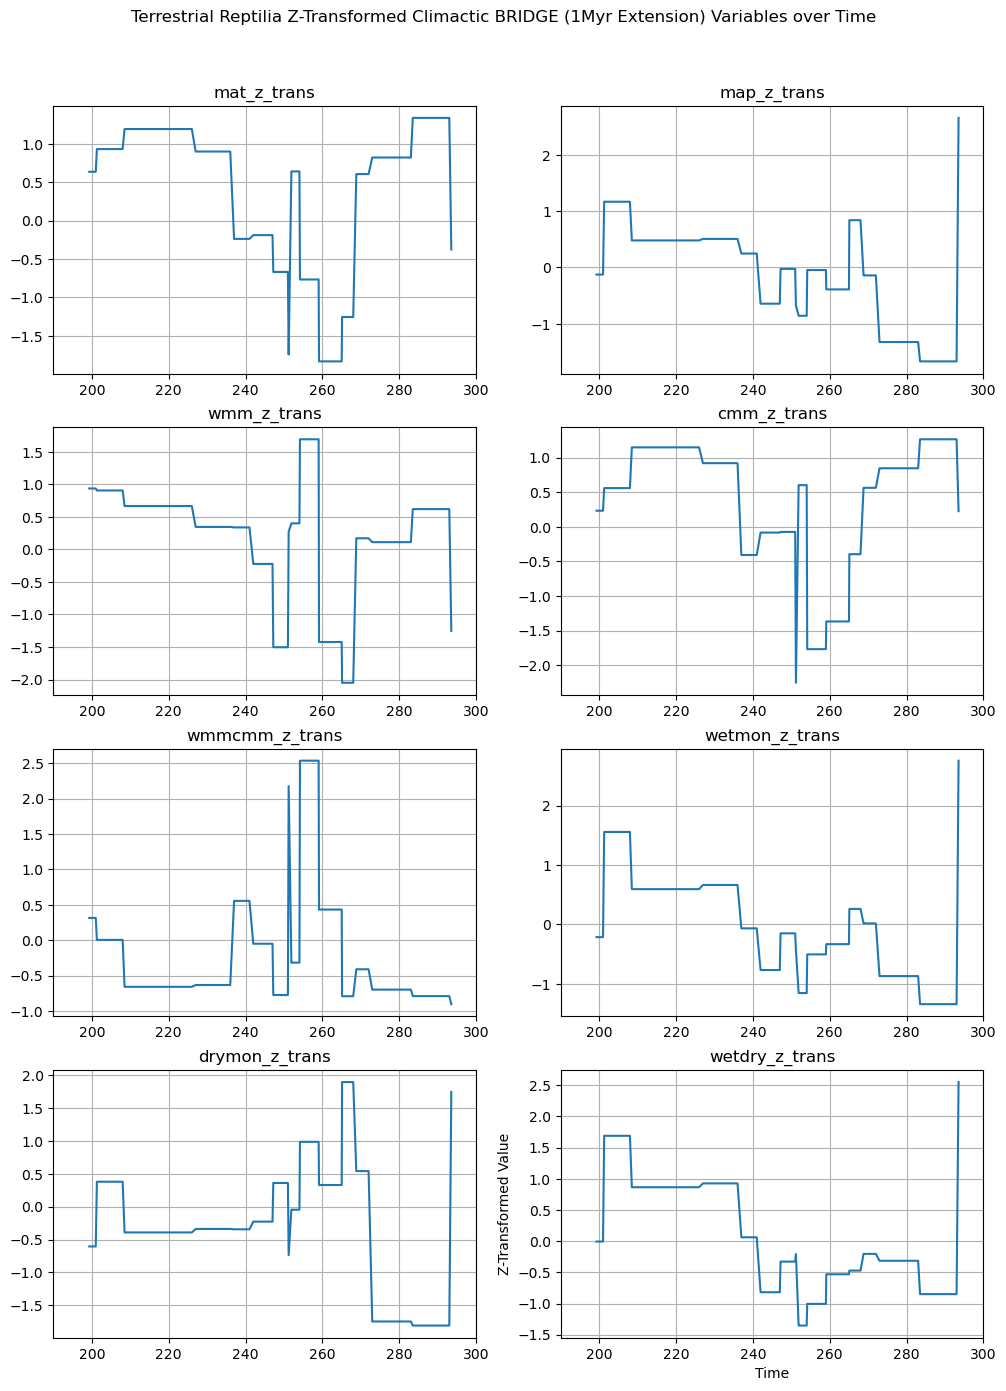

In [98]:
y_cols_z_trans = ['mat_z_trans', 'map_z_trans', 'wmm_z_trans', 'cmm_z_trans', 'wmmcmm_z_trans', 'wetmon_z_trans', 'drymon_z_trans', 'wetdry_z_trans']
plot_line_columns_grid(rep_terr_BRIDGE_1myr, 'Time', y_cols_z_trans, "Terrestrial Reptilia Z-Transformed Climactic BRIDGE (1Myr Extension) Variables over Time", "Time", 
                   "AF_climactic_data/AF_climactic_data_visualizations/reptilia_terr_z_trans_BRIDGE_1Myr_variables_over_time_grid.pdf")

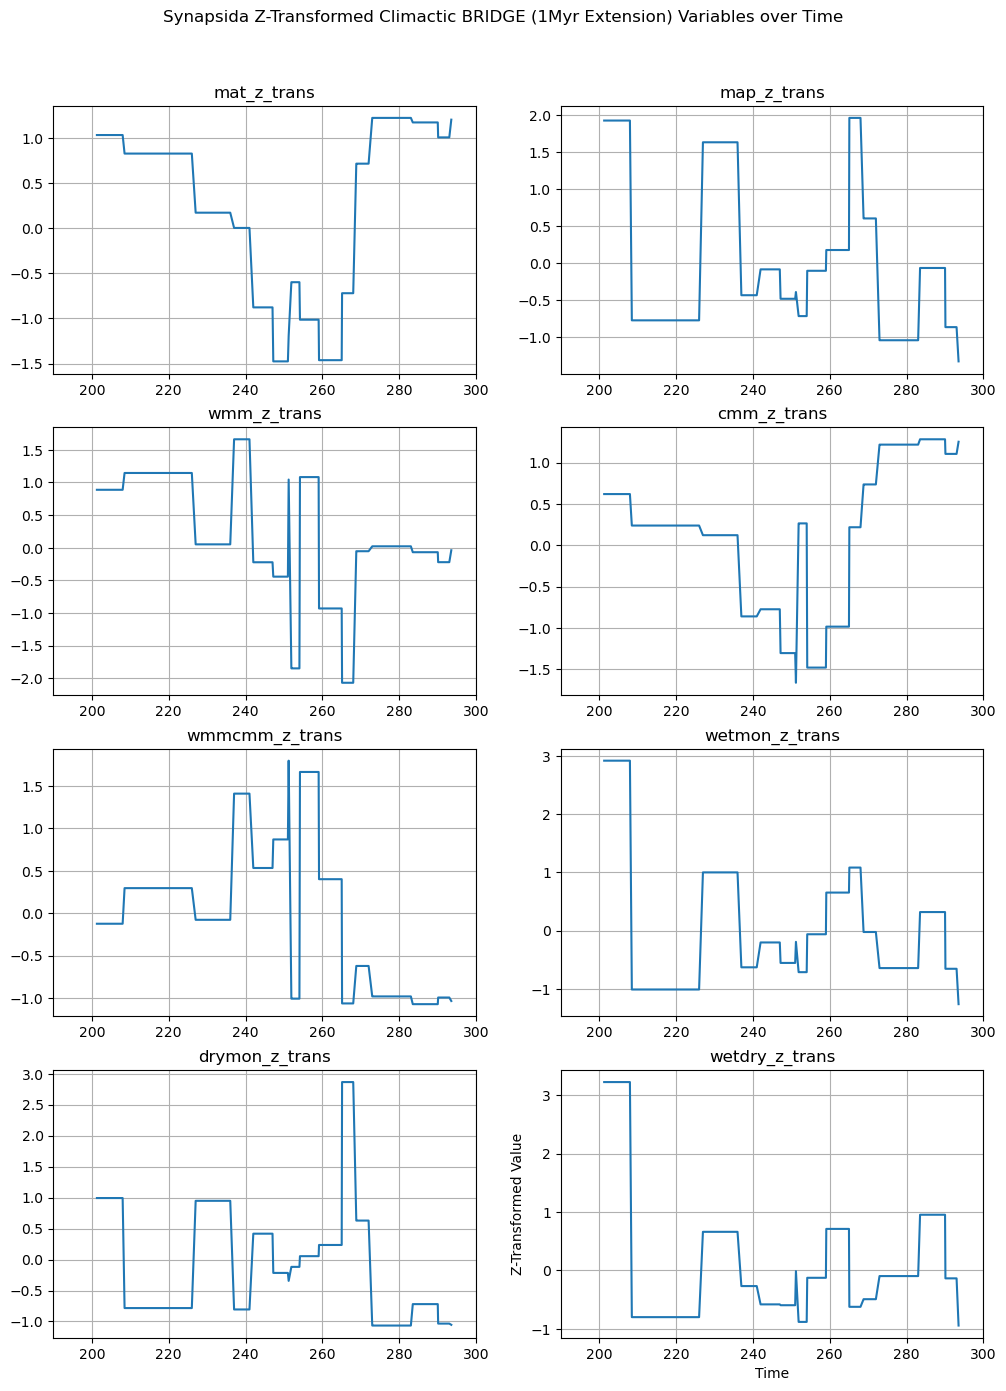

In [99]:
y_cols_z_trans = ['mat_z_trans', 'map_z_trans', 'wmm_z_trans', 'cmm_z_trans', 'wmmcmm_z_trans', 'wetmon_z_trans', 'drymon_z_trans', 'wetdry_z_trans']
plot_line_columns_grid(syn_BRIDGE_1myr, 'Time', y_cols_z_trans, "Synapsida Z-Transformed Climactic BRIDGE (1Myr Extension) Variables over Time", "Time", 
                   "AF_climactic_data/AF_climactic_data_visualizations/synapsida_z_trans_BRIDGE_1Myr_variables_over_time_grid.pdf")

### 0.1 Myr Extension

In [110]:
reptilia_BRIDGE_z_trans_filtered.describe()

,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
count,16.000000,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,16.000000,1.600000e+01
mean,247.657000,-2.775558e-17,2.775558e-17,-2.498002e-16,5.551115e-17,-4.163336e-17,2.775558e-17,0.000000,1.387779e-17
std,27.779892,1.032796e+00,1.032796e+00,1.032796e+00,1.032796e+00,1.032796e+00,1.032796e+00,1.032796,1.032796e+00
min,199.300000,-1.833262e+00,-1.667559e+00,-2.049837e+00,-2.255303e+00,-9.024838e-01,-1.343780e+00,-1.810146,-1.353237e+00
25%,234.500000,-6.928354e-01,-6.514730e-01,-4.805896e-01,-3.996124e-01,-7.162969e-01,-5.715329e-01,-0.445396,-6.032016e-01
50%,251.551000,2.088792e-01,-8.589215e-02,3.037533e-01,2.286128e-01,-3.631632e-01,-1.830647e-01,-0.136644,-2.614960e-01
75%,266.025000,8.417796e-01,4.866154e-01,6.307627e-01,6.626056e-01,3.446060e-01,3.433471e-01,0.420954,2.624057e-01
max,293.520000,1.338319e+00,2.655796e+00,1.691980e+00,1.264486e+00,2.534502e+00,2.756421e+00,1.898150,2.550480e+00


In [117]:
rep_time_range_0_1myr = pd.DataFrame({'Time': [x / 10.0 for x in range(1994, 2936)]})
rep_time_range_0_1myr

,Time
0,199.4
1,199.5
2,199.6
3,199.7
4,199.8
...,...
937,293.1
938,293.2
939,293.3
940,293.4


In [118]:
reptilia_BRIDGE_z_trans_filtered_0_1myr = pd.merge(rep_time_range_0_1myr, reptilia_BRIDGE_z_trans_filtered, on='Time', how='outer')
reptilia_BRIDGE_z_trans_filtered_0_1myr = reptilia_BRIDGE_z_trans_filtered_0_1myr.sort_values(by='Time').reset_index(drop=True)
reptilia_BRIDGE_z_trans_filtered_0_1myr

,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
0,199.30,0.636283,-0.125708,0.935991,0.232025,0.315161,-0.214918,-0.605215,-0.006093
1,199.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,199.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,199.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,199.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
942,293.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
943,293.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
944,293.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
945,293.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [119]:
subset = reptilia_BRIDGE_z_trans_filtered_0_1myr[reptilia_BRIDGE_z_trans_filtered_0_1myr['Time'].isin(reptilia_BRIDGE_z_trans_filtered['Time'])]
# drop index
subset = subset.reset_index(drop=True)
subset == reptilia_BRIDGE_z_trans_filtered

,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
0,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True
5,True,True,True,True,True,True,True,True,True
6,True,True,True,True,True,True,True,True,True
7,True,True,True,True,True,True,True,True,True
8,True,True,True,True,True,True,True,True,True
9,True,True,True,True,True,True,True,True,True


In [ ]:
# commented out to avoid re-running and overwriting the file
# reptilia_BRIDGE_z_trans_filtered_0_1myr.to_csv("AF_climactic_data/reptilia_terr_BRIDGE_z_trans_filtered_0.1myr.csv", index=False)

In [121]:
synapsida_BRIDGE_z_trans_filtered.describe()

,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
count,16.000000,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01
mean,253.332000,-3.469447e-17,5.551115e-17,-8.326673e-17,2.775558e-17,-5.551115e-17,-1.110223e-16,5.551115e-17,1.110223e-16
std,26.487172,1.032796e+00,1.032796e+00,1.032796e+00,1.032796e+00,1.032796e+00,1.032796e+00,1.032796e+00,1.032796e+00
min,201.300000,-1.474915e+00,-1.331892e+00,-2.069371e+00,-1.662788e+00,-1.071675e+00,-1.265095e+00,-1.065778e+00,-9.434420e-01
25%,240.750000,-9.112857e-01,-7.330992e-01,-2.777859e-01,-8.908430e-01,-9.967427e-01,-6.480998e-01,-7.891618e-01,-6.021790e-01
50%,253.021000,8.663836e-02,-2.488195e-01,-4.591203e-02,2.289540e-01,-1.006437e-01,-1.994101e-01,-1.672323e-01,-2.014949e-01
75%,269.837500,1.011027e+00,2.832189e-01,9.272094e-01,8.290625e-01,6.173623e-01,4.014224e-01,4.703514e-01,1.564762e-01
max,293.520000,1.220342e+00,1.965673e+00,1.661887e+00,1.282867e+00,1.798033e+00,2.919459e+00,2.865256e+00,3.225505e+00


In [123]:
syn_time_range_0_1myr = pd.DataFrame({'Time': [x / 10.0 for x in range(2014, 2936)]})
syn_time_range_0_1myr

,Time
0,201.4
1,201.5
2,201.6
3,201.7
4,201.8
...,...
917,293.1
918,293.2
919,293.3
920,293.4


In [124]:
synapsida_BRIDGE_z_trans_filtered_0_1myr = pd.merge(syn_time_range_0_1myr, synapsida_BRIDGE_z_trans_filtered, on='Time', how='outer')
synapsida_BRIDGE_z_trans_filtered_0_1myr = synapsida_BRIDGE_z_trans_filtered_0_1myr.sort_values(by='Time').reset_index(drop=True)
synapsida_BRIDGE_z_trans_filtered_0_1myr

,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
0,201.30,1.030603,1.929754,0.888025,0.620072,-0.123821,2.919459,0.992889,3.225505
1,201.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,201.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,201.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,201.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
922,293.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
923,293.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
924,293.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
925,293.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [125]:
subset = synapsida_BRIDGE_z_trans_filtered_0_1myr[synapsida_BRIDGE_z_trans_filtered_0_1myr['Time'].isin(synapsida_BRIDGE_z_trans_filtered['Time'])]
# drop index
subset = subset.reset_index(drop=True)
subset == synapsida_BRIDGE_z_trans_filtered

,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
0,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True
5,True,True,True,True,True,True,True,True,True
6,True,True,True,True,True,True,True,True,True
7,True,True,True,True,True,True,True,True,True
8,True,True,True,True,True,True,True,True,True
9,True,True,True,True,True,True,True,True,True


In [ ]:
# commented out to avoid re-running and overwriting the file
# synapsida_BRIDGE_z_trans_filtered_0_1myr.to_csv("AF_climactic_data/synapsida_BRIDGE_z_trans_filtered_0.1myr.csv", index=False)

# Binary Stages File

Columns for each bin, rows for 1 myr time steps, 0 or 1 for whether we're at that bin

In [2]:
cols = ['Time','208-217','217-227', '227-237','237-242','242-246.7','246.7-252','252-259.5','259.5-264.3','264.3-274.4','274.4-283.5','283.5-290.1']

stages_timevar_0_1myr = pd.DataFrame(columns=cols)
stages_timevar_0_1myr['Time'] = np.arange(208.0, 290.1, 0.1)
stages_timevar_0_1myr['208-217'] = stages_timevar_0_1myr['Time'].apply(lambda x: 1 if 208 <= x < 217 else 0)
stages_timevar_0_1myr['217-227'] = stages_timevar_0_1myr['Time'].apply(lambda x: 1 if 217 <= x < 227 else 0)
stages_timevar_0_1myr['227-237'] = stages_timevar_0_1myr['Time'].apply(lambda x: 1 if 227 <= x < 237 else 0)
stages_timevar_0_1myr['237-242'] = stages_timevar_0_1myr['Time'].apply(lambda x: 1 if 237 <= x < 242 else 0)
stages_timevar_0_1myr['242-246.7'] = stages_timevar_0_1myr['Time'].apply (lambda x: 1 if 242 <= x < 246.7 else 0)
stages_timevar_0_1myr['246.7-252'] = stages_timevar_0_1myr['Time'].apply(lambda x: 1 if 246.7 <= x < 252 else 0)
stages_timevar_0_1myr['252-259.5'] = stages_timevar_0_1myr['Time'].apply(lambda x: 1 if 252 <= x < 259.5 else 0)
stages_timevar_0_1myr['259.5-264.3'] = stages_timevar_0_1myr['Time'].apply(lambda x: 1 if 259.5 <= x < 264.3 else 0)
stages_timevar_0_1myr['264.3-274.4'] = stages_timevar_0_1myr['Time'].apply(lambda x: 1 if 264.3 <= x < 274.4 else 0)
stages_timevar_0_1myr['274.4-283.5'] = stages_timevar_0_1myr['Time'].apply(lambda x: 1 if 274.4 <= x < 283.5 else 0)
stages_timevar_0_1myr['283.5-290.1'] = stages_timevar_0_1myr['Time'].apply(lambda x: 1 if 283.5 <= x < 290.1 else 0)
stages_timevar_0_1myr


,Time,208-217,217-227,227-237,237-242,242-246.7,246.7-252,252-259.5,259.5-264.3,264.3-274.4,274.4-283.5,283.5-290.1
0,208.0,1,0,0,0,0,0,0,0,0,0,0
1,208.1,1,0,0,0,0,0,0,0,0,0,0
2,208.2,1,0,0,0,0,0,0,0,0,0,0
3,208.3,1,0,0,0,0,0,0,0,0,0,0
4,208.4,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
817,289.7,0,0,0,0,0,0,0,0,0,0,1
818,289.8,0,0,0,0,0,0,0,0,0,0,1
819,289.9,0,0,0,0,0,0,0,0,0,0,1
820,290.0,0,0,0,0,0,0,0,0,0,0,1


In [3]:
stages_timevar_0_1myr.to_csv("Perm-Trias/stages_timevar_predictor/stages_timevar_0.1myr.txt", sep="\t", index=False,float_format='%.1f')

In [7]:
cols = ['Time','208-217','217-227', '227-237','237-242','242-246.7','246.7-252','252-259.5','259.5-264.3','264.3-274.4','274.4-283.5','283.5-290.1']

stages_timevar_1myr = pd.DataFrame(columns=cols)
stages_timevar_1myr['Time'] = np.arange(208.0, 292, 1)
stages_timevar_1myr['208-217'] = stages_timevar_1myr['Time'].apply(lambda x: 1 if 208 <= x < 217 else 0)
stages_timevar_1myr['217-227'] = stages_timevar_1myr['Time'].apply(lambda x: 1 if 217 <= x < 227 else 0)
stages_timevar_1myr['227-237'] = stages_timevar_1myr['Time'].apply(lambda x: 1 if 227 <= x < 237 else 0)
stages_timevar_1myr['237-242'] = stages_timevar_1myr['Time'].apply(lambda x: 1 if 237 <= x < 242 else 0)
stages_timevar_1myr['242-246.7'] = stages_timevar_1myr['Time'].apply (lambda x: 1 if 242 <= x < 246.7 else 0)
stages_timevar_1myr['246.7-252'] = stages_timevar_1myr['Time'].apply(lambda x: 1 if 246.7 <= x < 252 else 0)
stages_timevar_1myr['252-259.5'] = stages_timevar_1myr['Time'].apply(lambda x: 1 if 252 <= x < 259.5 else 0)
stages_timevar_1myr['259.5-264.3'] = stages_timevar_1myr['Time'].apply(lambda x: 1 if 259.5 <= x < 264.3 else 0)
stages_timevar_1myr['264.3-274.4'] = stages_timevar_1myr['Time'].apply(lambda x: 1 if 264.3 <= x < 274.4 else 0)
stages_timevar_1myr['274.4-283.5'] = stages_timevar_1myr['Time'].apply(lambda x: 1 if 274.4 <= x < 283.5 else 0)
stages_timevar_1myr['283.5-290.1'] = stages_timevar_1myr['Time'].apply(lambda x: 1 if 283.5 <= x < 290.1 else 0)
stages_timevar_1myr

,Time,208-217,217-227,227-237,237-242,242-246.7,246.7-252,252-259.5,259.5-264.3,264.3-274.4,274.4-283.5,283.5-290.1
0,208.0,1,0,0,0,0,0,0,0,0,0,0
1,209.0,1,0,0,0,0,0,0,0,0,0,0
2,210.0,1,0,0,0,0,0,0,0,0,0,0
3,211.0,1,0,0,0,0,0,0,0,0,0,0
4,212.0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
79,287.0,0,0,0,0,0,0,0,0,0,0,1
80,288.0,0,0,0,0,0,0,0,0,0,0,1
81,289.0,0,0,0,0,0,0,0,0,0,0,1
82,290.0,0,0,0,0,0,0,0,0,0,0,1


In [8]:
stages_timevar_1myr.to_csv("Perm-Trias/stages_timevar_predictor/stages_timevar_1myr.txt", sep="\t", index=False,float_format='%.1f')

# Binary Stages File + Isotopic Stages Data

In [9]:
stages_timevar_1myr = pd.read_csv("Perm-Trias/stages_timevar_predictor/stages_timevar_1myr.txt", sep="\t")
stages_timevar_1myr

,Time,208-217,217-227,227-237,237-242,242-246.7,246.7-252,252-259.5,259.5-264.3,264.3-274.4,274.4-283.5,283.5-290.1
0,208.0,1,0,0,0,0,0,0,0,0,0,0
1,209.0,1,0,0,0,0,0,0,0,0,0,0
2,210.0,1,0,0,0,0,0,0,0,0,0,0
3,211.0,1,0,0,0,0,0,0,0,0,0,0
4,212.0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
79,287.0,0,0,0,0,0,0,0,0,0,0,1
80,288.0,0,0,0,0,0,0,0,0,0,0,1
81,289.0,0,0,0,0,0,0,0,0,0,0,1
82,290.0,0,0,0,0,0,0,0,0,0,0,1


In [10]:
isotopic_1myr = pd.read_csv("Guad-Ladin/songEA_isotopic_data/songEA_data_ordered_filtered_1myr.txt", sep="\t")
isotopic_1myr

,Time,mean_z_trans,Mod_R_deltaTMyr_z_trans
0,227.0,0.382854,-1.035019
1,228.0,0.382854,-1.035019
2,229.0,0.382854,-1.035019
3,230.0,0.382854,-1.035019
4,231.0,0.382854,-1.035019
...,...,...,...
64,287.0,-0.767961,-0.712796
65,288.0,-0.767961,-0.712796
66,289.0,-0.767961,-0.712796
67,290.0,-0.767961,-0.712796


In [11]:
isotopic_stages_timevar_1myr = pd.merge(isotopic_1myr, stages_timevar_1myr, on='Time', how='outer')
isotopic_stages_timevar_1myr = isotopic_stages_timevar_1myr.sort_values(by='Time').reset_index(drop=True)
isotopic_stages_timevar_1myr

,Time,mean_z_trans,Mod_R_deltaTMyr_z_trans,208-217,217-227,227-237,237-242,242-246.7,246.7-252,252-259.5,259.5-264.3,264.3-274.4,274.4-283.5,283.5-290.1
0,208.0,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,209.0,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,210.0,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,211.0,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,212.0,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,288.0,-0.767961,-0.712796,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
85,289.0,-0.767961,-0.712796,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
86,290.0,-0.767961,-0.712796,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
87,290.1,-1.026402,-0.307456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Saved off and filling NaN's in Excel. 
# Commented out to avoid re-running and overwriting the file
# isotopic_stages_timevar_1myr.to_csv("Guad-Ladin/songEA_isotopic_data/isotopic_and_binary_stages_data/isotopic_stages_timevar_1myr.csv", index=False)

In [12]:
isotopic_stages_timevar_1myr[isotopic_stages_timevar_1myr.isna().any(axis=1)]

,Time,mean_z_trans,Mod_R_deltaTMyr_z_trans,208-217,217-227,227-237,237-242,242-246.7,246.7-252,252-259.5,259.5-264.3,264.3-274.4,274.4-283.5,283.5-290.1
0,208.00,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,209.00,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,210.00,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,211.00,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,212.00,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,213.00,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,214.00,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,215.00,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,216.00,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,217.00,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Binary Stages File + Isotopic 1Myr Data

In [58]:
stages_timevar_1myr = pd.read_csv("Perm-Trias/stages_timevar_predictor/stages_timevar_1myr.txt", sep="\t")

stages_timevar_1myr

,Time,208-217,217-227,227-237,237-242,242-246.7,246.7-252,252-259.5,259.5-264.3,264.3-274.4,274.4-283.5,283.5-290.1
0,208.0,1,0,0,0,0,0,0,0,0,0,0
1,209.0,1,0,0,0,0,0,0,0,0,0,0
2,210.0,1,0,0,0,0,0,0,0,0,0,0
3,211.0,1,0,0,0,0,0,0,0,0,0,0
4,212.0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
79,287.0,0,0,0,0,0,0,0,0,0,0,1
80,288.0,0,0,0,0,0,0,0,0,0,0,1
81,289.0,0,0,0,0,0,0,0,0,0,0,1
82,290.0,0,0,0,0,0,0,0,0,0,0,1


In [64]:
isotopic_1myr_data = pd.read_csv("Perm-Trias/songEA_isotopic_data_pt_1myr/isotopic_1myr_filtered_final.txt", sep="\t")
isotopic_1myr_data

,Time,mean_pt_1myr_z_trans,Mod_R_deltaTMyr_pt_1myr_z_trans
0,300,0.135311,-0.865252
1,299,-0.192132,-0.486496
2,298,-0.939830,0.444172
3,297,-0.595793,-0.449748
4,296,-0.107576,-0.130457
...,...,...,...
80,206,0.138179,-0.522030
81,205,-0.226130,-0.404855
82,204,0.035533,-0.632168
83,203,0.124157,-1.015368


In [65]:
isotopic_1myr_stages_timevar = pd.merge(isotopic_1myr_data, stages_timevar_1myr, on='Time', how='outer')
isotopic_1myr_stages_timevar = isotopic_1myr_stages_timevar.sort_values(by='Time').reset_index(drop=True)
isotopic_1myr_stages_timevar

,Time,mean_pt_1myr_z_trans,Mod_R_deltaTMyr_pt_1myr_z_trans,208-217,217-227,227-237,237-242,242-246.7,246.7-252,252-259.5,259.5-264.3,264.3-274.4,274.4-283.5,283.5-290.1
0,202.0,-0.493105,0.155316,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,203.0,0.124157,-1.015368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,204.0,0.035533,-0.632168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,205.0,-0.226130,-0.404855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,206.0,0.138179,-0.522030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,296.0,-0.107576,-0.130457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95,297.0,-0.595793,-0.449748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,298.0,-0.939830,0.444172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,299.0,-0.192132,-0.486496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
# Saving the isotopic data as a csv
isotopic_1myr_stages_timevar.to_csv("Perm-Trias/songEA_isotopic_data_pt_1myr/isotopic_1myr_binary_stages_timevar_raw.csv", index=False)

# Binary Stages File + BRIDGE Data

In [16]:
# stages_timevar_1myr = pd.read_csv("Perm-Trias/stages_timevar_predictor/stages_timevar_1myr.txt", sep="\t")
stages_timevar_1myr

,Time,208-217,217-227,227-237,237-242,242-246.7,246.7-252,252-259.5,259.5-264.3,264.3-274.4,274.4-283.5,283.5-290.1
0,208.0,1,0,0,0,0,0,0,0,0,0,0
1,209.0,1,0,0,0,0,0,0,0,0,0,0
2,210.0,1,0,0,0,0,0,0,0,0,0,0
3,211.0,1,0,0,0,0,0,0,0,0,0,0
4,212.0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
79,287.0,0,0,0,0,0,0,0,0,0,0,1
80,288.0,0,0,0,0,0,0,0,0,0,0,1
81,289.0,0,0,0,0,0,0,0,0,0,0,1
82,290.0,0,0,0,0,0,0,0,0,0,0,1


In [17]:
rep_BRIDGE_1myr = pd.read_csv("AF_climactic_data/reptilia_terr_BRIDGE_z_trans_filtered_1myr.csv")
rep_BRIDGE_1myr

,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
0,199.30,0.636283,-0.125708,0.935991,0.232025,0.315161,-0.214918,-0.605215,-0.006093
1,200.00,0.636283,-0.125708,0.935991,0.232025,0.315161,-0.214918,-0.605215,-0.006093
2,201.00,0.636283,-0.125708,0.935991,0.232025,0.315161,-0.214918,-0.605215,-0.006093
3,201.30,0.932415,1.167003,0.905312,0.558769,0.004693,1.556155,0.380521,1.689357
4,202.00,0.932415,1.167003,0.905312,0.558769,0.004693,1.556155,0.380521,1.689357
...,...,...,...,...,...,...,...,...,...
102,290.00,1.338319,-1.667559,0.618943,1.264486,-0.788962,-1.343780,-1.810146,-0.849677
103,291.00,1.338319,-1.667559,0.618943,1.264486,-0.788962,-1.343780,-1.810146,-0.849677
104,292.00,1.338319,-1.667559,0.618943,1.264486,-0.788962,-1.343780,-1.810146,-0.849677
105,293.00,1.338319,-1.667559,0.618943,1.264486,-0.788962,-1.343780,-1.810146,-0.849677


In [18]:
rep_BRIDGE_stages_timevar_1myr = pd.merge(rep_BRIDGE_1myr, stages_timevar_1myr, on='Time', how='outer')
rep_BRIDGE_stages_timevar_1myr = rep_BRIDGE_stages_timevar_1myr.sort_values(by='Time').reset_index(drop=True)
rep_BRIDGE_stages_timevar_1myr

,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans,208-217,217-227,227-237,237-242,242-246.7,246.7-252,252-259.5,259.5-264.3,264.3-274.4,274.4-283.5,283.5-290.1
0,199.30,0.636283,-0.125708,0.935991,0.232025,0.315161,-0.214918,-0.605215,-0.006093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,200.00,0.636283,-0.125708,0.935991,0.232025,0.315161,-0.214918,-0.605215,-0.006093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,201.00,0.636283,-0.125708,0.935991,0.232025,0.315161,-0.214918,-0.605215,-0.006093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,201.30,0.932415,1.167003,0.905312,0.558769,0.004693,1.556155,0.380521,1.689357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,202.00,0.932415,1.167003,0.905312,0.558769,0.004693,1.556155,0.380521,1.689357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,290.00,1.338319,-1.667559,0.618943,1.264486,-0.788962,-1.343780,-1.810146,-0.849677,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
103,291.00,1.338319,-1.667559,0.618943,1.264486,-0.788962,-1.343780,-1.810146,-0.849677,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
104,292.00,1.338319,-1.667559,0.618943,1.264486,-0.788962,-1.343780,-1.810146,-0.849677,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
105,293.00,1.338319,-1.667559,0.618943,1.264486,-0.788962,-1.343780,-1.810146,-0.849677,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Saved off and filling NaN's in Excel.
# Commented out to avoid re-running and overwriting the file
# rep_BRIDGE_stages_timevar_1myr.to_csv("AF_climactic_data/BRIDGE_and_binary_stages_data/rep_terr_BRIDGE_stages_timevar_1myr.csv", index=False)

In [20]:
syn_BRIDGE_1myr = pd.read_csv("AF_climactic_data/synapsida_BRIDGE_z_trans_filtered_1myr.csv")
syn_BRIDGE_1myr

,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans
0,201.30,1.030603,1.929754,0.888025,0.620072,-0.123821,2.919459,0.992889,3.225505
1,202.00,1.030603,1.929754,0.888025,0.620072,-0.123821,2.919459,0.992889,3.225505
2,203.00,1.030603,1.929754,0.888025,0.620072,-0.123821,2.919459,0.992889,3.225505
3,204.00,1.030603,1.929754,0.888025,0.620072,-0.123821,2.919459,0.992889,3.225505
4,205.00,1.030603,1.929754,0.888025,0.620072,-0.123821,2.919459,0.992889,3.225505
...,...,...,...,...,...,...,...,...,...
100,290.10,1.004502,-0.868185,-0.221353,1.106119,-0.993419,-0.657032,-1.034263,-0.135395
101,291.00,1.004502,-0.868185,-0.221353,1.106119,-0.993419,-0.657032,-1.034263,-0.135395
102,292.00,1.004502,-0.868185,-0.221353,1.106119,-0.993419,-0.657032,-1.034263,-0.135395
103,293.00,1.004502,-0.868185,-0.221353,1.106119,-0.993419,-0.657032,-1.034263,-0.135395


In [21]:
syn_BRIDGE_1myr_stages_timevar_1myr = pd.merge(syn_BRIDGE_1myr, stages_timevar_1myr, on='Time', how='outer')
syn_BRIDGE_1myr_stages_timevar_1myr = syn_BRIDGE_1myr_stages_timevar_1myr.sort_values(by='Time').reset_index(drop=True)
syn_BRIDGE_1myr_stages_timevar_1myr

,Time,mat_z_trans,map_z_trans,wmm_z_trans,cmm_z_trans,wmmcmm_z_trans,wetmon_z_trans,drymon_z_trans,wetdry_z_trans,208-217,217-227,227-237,237-242,242-246.7,246.7-252,252-259.5,259.5-264.3,264.3-274.4,274.4-283.5,283.5-290.1
0,201.30,1.030603,1.929754,0.888025,0.620072,-0.123821,2.919459,0.992889,3.225505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,202.00,1.030603,1.929754,0.888025,0.620072,-0.123821,2.919459,0.992889,3.225505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,203.00,1.030603,1.929754,0.888025,0.620072,-0.123821,2.919459,0.992889,3.225505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,204.00,1.030603,1.929754,0.888025,0.620072,-0.123821,2.919459,0.992889,3.225505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,205.00,1.030603,1.929754,0.888025,0.620072,-0.123821,2.919459,0.992889,3.225505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,290.10,1.004502,-0.868185,-0.221353,1.106119,-0.993419,-0.657032,-1.034263,-0.135395,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101,291.00,1.004502,-0.868185,-0.221353,1.106119,-0.993419,-0.657032,-1.034263,-0.135395,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
102,292.00,1.004502,-0.868185,-0.221353,1.106119,-0.993419,-0.657032,-1.034263,-0.135395,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
103,293.00,1.004502,-0.868185,-0.221353,1.106119,-0.993419,-0.657032,-1.034263,-0.135395,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Saved off and filling NaN's in Excel.
# Commented out to avoid re-running and overwriting the file
# syn_BRIDGE_1myr_stages_timevar_1myr.to_csv("AF_climactic_data/BRIDGE_and_binary_stages_data/syn_BRIDGE_stages_timevar_1myr.csv", index=False)

# FixShift w/ 1Myr + Stage Bins

In [59]:
# Create a dataframe with rows starting from 299 and going down to 198 in increments of 1
# No column name
data = range(300, 197, -1)
fixshift_1myr = pd.DataFrame(data)
fixshift_1myr

,0
0,300
1,299
2,298
3,297
4,296
...,...
98,202
99,201
100,200
101,199


In [60]:
time_bins_needed = pd.read_csv("Perm-Trias/Time_bins_ByStages.txt", sep="\t", header=None)
time_bins_needed

,0
0,290.1
1,283.5
2,274.4
3,264.3
4,259.5
5,252.0
6,246.7
7,242.0
8,237.0
9,227.0


In [61]:
# Now I need to insert the following partial year values (stages) into the dataframe
partial_years = time_bins_needed[time_bins_needed[0] % 1 != 0]
partial_years

,0
0,290.1
1,283.5
2,274.4
3,264.3
4,259.5
6,246.7


In [62]:
# Add the partial years to the dataframe in the correct order
fixshift_1myr_stages = pd.concat([fixshift_1myr, partial_years], ignore_index=True)
fixshift_1myr_stages = fixshift_1myr_stages.sort_values(by=0, ascending=False).reset_index(drop=True)
fixshift_1myr_stages


,0
0,300.0
1,299.0
2,298.0
3,297.0
4,296.0
...,...
104,202.0
105,201.0
106,200.0
107,199.0


In [63]:
fixshift_1myr_stages.to_csv("Perm-Trias/Time_bins_1myr_and_stages.txt", sep="\t", index=False, header=False)

# EDA on -BDNNtimevar Interpolation

**This section should be defunct now that we've decided to extend both environmental predictors by 0.1Myr time steps by just repeating values within that time bin. This should by-pass PyRate's internal interpolation when binning time series values (environmental predictors) into the fixshift bins, which are larger (1myr mostly) than 0.1Myr**

When -fixShift and the time bins in a -BDNNtimevar file (such as BRIDGE or SongEA Isotopic data) don't match, how does PyRate interpolate the -BDNNtimevar file to fit inside the -fixShift time bins? 

Added print statements (tip from Torsten Hauffe) to PyRate.py to investigate

time_vec = time bins from my -fixShift file + the age of my oldest occurrence (298.498). This vector also contained a 0 at the end, but that would've caused issue in the interpolation code so I left it o

time_var_lambda = a list of lists, where the first list corresponds to the first time bin, the second list corresponds to the second time bin, etc. Each item within each sublist refers to one paleoenvironmental predictor (in this case, variables from the BRIDGE data). So -0.377 is the "mat_z_trans" variable for the time between 298.498 myr - 290.1 myr. 

In [131]:
time_vec_original = [298.498, 290.1, 283.5, 274.4, 264.3,259.5,252,246.7,242, 237, 227, 217, 208] # also had a 0 at the end
time_vec_as_bins = ["298.498-290.1", "290.1-283.5", "283.5-274.4", "274.4-264.3", "264.3-259.5", "259.5-252", "252-246.7", "246.7-242",
                    "242-237", "237-227","227-217", "217-208", "208-0"]
time_var_lambda =[[-0.377,  2.656, -1.252,  0.225, -0.902,  2.756,  1.749,  2.55 ],
 [ 1.338, -1.668,  0.619,  1.264, -0.789, -1.344, -1.81,  -0.85 ],
 [ 1.338, -1.668,  0.619,  1.264, -0.789, -1.344, -1.81,  -0.85 ],
 [ 0.058, -0.208, -0.589,  0.337, -0.632, -0.199,  0.231, -0.33 ],
 [-1.833, -0.39,  -1.423, -1.369,  0.433, -0.333,  0.33,  -0.531],
 [-1.3,   -0.218,  0.134, -1.569,  1.484, -0.42,   0.659, -0.769],
 [-0.59,  -0.52,  -0.278, -0.576,  0.362, -0.58,  -0.141, -0.63 ],
 [-0.189, -0.643, -0.223, -0.084, -0.049, -0.769, -0.228, -0.819],
 [-0.213, -0.198,  0.057, -0.246, 0.253, -0.418, -0.286, -0.379],
 [ 0.331,  0.377,  0.341,  0.255, -0.038,  0.298, -0.341,  0.494],
 [ 0.9,    0.507,  0.345,  0.919, -0.632,  0.663, -0.339,  0.926],
 [ 1.193,  0.48,   0.666,  1.148, -0.658,  0.593, -0.392,  0.865],
 [ 0.735,  0.305,  0.926,  0.341,  0.212,  0.375, -0.277,  0.559]]

# The first sublist corresponds to the first time point, the second sublist to the second time point, and so on.
time_var_lambda = np.array(time_var_lambda)
# Create a dataframe with the time vector as the index and each sublist as a row
interpolated_BRIDGE = pd.DataFrame(time_var_lambda, index=time_vec_as_bins)
# Add a 'time' column with the original time vector
interpolated_BRIDGE['Time'] = time_vec_original
# reorder dataframe by index, ascending
interpolated_BRIDGE = interpolated_BRIDGE.sort_index(ascending=True)
interpolated_BRIDGE

,0,1,2,3,4,5,6,7,Time
208-0,0.735,0.305,0.926,0.341,0.212,0.375,-0.277,0.559,208.000
217-208,1.193,0.480,0.666,1.148,-0.658,0.593,-0.392,0.865,217.000
227-217,0.900,0.507,0.345,0.919,-0.632,0.663,-0.339,0.926,227.000
237-227,0.331,0.377,0.341,0.255,-0.038,0.298,-0.341,0.494,237.000
242-237,-0.213,-0.198,0.057,-0.246,0.253,-0.418,-0.286,-0.379,242.000
246.7-242,-0.189,-0.643,-0.223,-0.084,-0.049,-0.769,-0.228,-0.819,246.700
252-246.7,-0.590,-0.520,-0.278,-0.576,0.362,-0.580,-0.141,-0.630,252.000
259.5-252,-1.300,-0.218,0.134,-1.569,1.484,-0.420,0.659,-0.769,259.500
264.3-259.5,-1.833,-0.390,-1.423,-1.369,0.433,-0.333,0.330,-0.531,264.300
274.4-264.3,0.058,-0.208,-0.589,0.337,-0.632,-0.199,0.231,-0.330,274.400


In [134]:
interpolated_BRIDGE_mat = interpolated_BRIDGE[[0, 'Time']]
interpolated_BRIDGE_mat.columns = ['mat_z_trans', 'Time']
# make the index a column called 'Time_bins'
interpolated_BRIDGE_mat.reset_index(inplace=True)
interpolated_BRIDGE_mat.rename(columns={'index': 'Time_bins'}, inplace=True)
# Reorder
interpolated_BRIDGE_mat = interpolated_BRIDGE_mat[['Time', 'Time_bins', 'mat_z_trans']]
interpolated_BRIDGE_mat

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_17060\2036810896.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  interpolated_BRIDGE_mat.rename(columns={'index': 'Time_bins'}, inplace=True)


,Time,Time_bins,mat_z_trans
0,208.000,208-0,0.735
1,217.000,217-208,1.193
2,227.000,227-217,0.900
3,237.000,237-227,0.331
4,242.000,242-237,-0.213
5,246.700,246.7-242,-0.189
6,252.000,252-246.7,-0.590
7,259.500,259.5-252,-1.300
8,264.300,264.3-259.5,-1.833
9,274.400,274.4-264.3,0.058


In [136]:
interpolated_BRIDGE_mat[['Time_bins', 'mat_z_trans']]

,Time_bins,mat_z_trans
0,208-0,0.735
1,217-208,1.193
2,227-217,0.900
3,237-227,0.331
4,242-237,-0.213
5,246.7-242,-0.189
6,252-246.7,-0.590
7,259.5-252,-1.300
8,264.3-259.5,-1.833
9,274.4-264.3,0.058


In [135]:
fixShift_bins = interpolated_BRIDGE_mat[['Time', 'Time_bins']]
fixShift_bins

,Time,Time_bins
0,208.000,208-0
1,217.000,217-208
2,227.000,227-217
3,237.000,237-227
4,242.000,242-237
5,246.700,246.7-242
6,252.000,252-246.7
7,259.500,259.5-252
8,264.300,264.3-259.5
9,274.400,274.4-264.3


In [124]:
BRIDGE = pd.read_csv("AF_climactic_data/reptilia_terr_BRIDGE_z_trans_filtered.txt", sep="\t")
BRIDGE_mat = BRIDGE[['Time', 'mat_z_trans']]
# Add a new row with Time = 0, and 'mat_z_trans' = 0. Do not use append, use loc to avoid index issues
BRIDGE_mat.loc[len(BRIDGE_mat)] = [400, 0]
# New column where value is current 'Time' - the next 'Time' value in the column as a string
BRIDGE_mat['Time_bins'] = BRIDGE_mat['Time'].astype(str) + '-' + BRIDGE_mat['Time'].shift(-1).fillna(0).astype(int).astype(str)
# Remove the last row, which has a Time of 400 as a placeholder for the oldest age in the occurrence dataset
BRIDGE_mat = BRIDGE_mat[:-1]
# Reorder the columns
BRIDGE_mat = BRIDGE_mat[['Time', 'Time_bins', 'mat_z_trans']]
BRIDGE_mat

C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_17060\292090017.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BRIDGE_mat.loc[len(BRIDGE_mat)] = [400, 0]
C:\Users\SimoesLabAdmin\AppData\Local\Temp\ipykernel_17060\292090017.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BRIDGE_mat['Time_bins'] = BRIDGE_mat['Time'].astype(str) + '-' + BRIDGE_mat['Time'].shift(-1).fillna(0).astype(int).astype(str)


,Time,Time_bins,mat_z_trans
0,199.300,199.3-201,0.636283
1,201.300,201.3-208,0.932415
2,208.500,208.5-227,1.193378
3,227.000,227.0-237,0.900076
4,237.000,237.0-242,-0.237793
5,242.000,242.0-247,-0.188571
6,247.200,247.2-251,-0.668289
7,251.200,251.2-251,-1.743744
8,251.902,251.902-254,0.641031
9,254.140,254.14-259,-0.766474


In [139]:
print(BRIDGE_mat)
print(interpolated_BRIDGE_mat)

       Time    Time_bins  mat_z_trans
0   199.300    199.3-201     0.636283
1   201.300    201.3-208     0.932415
2   208.500    208.5-227     1.193378
3   227.000    227.0-237     0.900076
4   237.000    237.0-242    -0.237793
5   242.000    242.0-247    -0.188571
6   247.200    247.2-251    -0.668289
7   251.200    251.2-251    -1.743744
8   251.902  251.902-254     0.641031
9   254.140   254.14-259    -0.766474
10  259.100    259.1-265    -1.833262
11  265.100    265.1-268    -1.255381
12  268.800    268.8-272     0.606329
13  272.950   272.95-283     0.822347
14  283.500    283.5-293     1.338319
15  293.520   293.52-400    -0.376664
       Time      Time_bins  mat_z_trans
0   208.000          208-0        0.735
1   217.000        217-208        1.193
2   227.000        227-217        0.900
3   237.000        237-227        0.331
4   242.000        242-237       -0.213
5   246.700      246.7-242       -0.189
6   252.000      252-246.7       -0.590
7   259.500      259.5-252       -

In [92]:
# Interpolate the BRIDGE_mat dataframe to match the time vector of the interpolated_BRIDGE dataframe
BRIDGE_mat_interpolated = pd.DataFrame({
    'Time': interpolated_BRIDGE.index,
    'mat_z_trans': np.interp(interpolated_BRIDGE.index, BRIDGE_mat['Time'], BRIDGE_mat['mat_z_trans'])
})
BRIDGE_mat_interpolated

,Time,mat_z_trans
0,208.000,1.175255
1,217.000,1.058618
2,227.000,0.900076
3,237.000,-0.237793
4,242.000,-0.188571
5,246.700,-0.622163
6,252.000,0.579398
7,259.500,-1.794737
8,264.300,-1.332432
9,274.400,0.893263


In [93]:
interpolated_BRIDGE_mat

,0
208.000,0.735
217.000,1.193
227.000,0.900
237.000,0.331
242.000,-0.213
246.700,-0.189
252.000,-0.590
259.500,-1.300
264.300,-1.833
274.400,0.058


In [98]:
# Create an empty list to store the results
results = []

# Change interpolated_BRIDGE.index to a series
interpolated_BRIDGE_index_series = pd.Series(interpolated_BRIDGE.index)

# Iterate over each bin and find the corresponding interval in BRIDGE
for i in range(len(interpolated_BRIDGE.index) - 1):
    start_bin = interpolated_BRIDGE.index[i]
    end_bin = interpolated_BRIDGE.index[i + 1]
    
    # Find the index in BRIDGE where the time corresponds to the start of the bin
    index = BRIDGE_mat[(BRIDGE_mat['Time'] <= end_bin) & (BRIDGE_mat['Time'] > start_bin)].index.min()
    
    # Get the mat_z_trans value for the corresponding interval
    if pd.notnull(index):
        mat_z_trans_value = BRIDGE_mat.loc[index, 'mat_z_trans']
    else:
        mat_z_trans_value = BRIDGE_mat.loc[BRIDGE_mat['Time'] <= start_bin, 'mat_z_trans'].iloc[-1]
    
    # Append the result to the list
    results.append({
        'Time_Bins': start_bin,
        'Interpolated_mat_z_trans': mat_z_trans_value
    })

# Handle the last bin separately
last_bin = interpolated_BRIDGE_index_series.iloc[-1]
index = BRIDGE_mat[BRIDGE_mat['Time'] <= last_bin].index.max()
mat_z_trans_value = BRIDGE_mat.loc[index, 'mat_z_trans']
results.append({
    'Time_Bins': last_bin,
    'Interpolated_mat_z_trans': mat_z_trans_value
})

# Convert the list of results to a DataFrame
interpolated_df = pd.DataFrame(results)

print(interpolated_df)

    Time_Bins  Interpolated_mat_z_trans
0     208.000                  1.193378
1     217.000                  0.900076
2     227.000                 -0.237793
3     237.000                 -0.188571
4     242.000                 -0.188571
5     246.700                 -0.668289
6     252.000                 -0.766474
7     259.500                 -1.833262
8     264.300                 -1.255381
9     274.400                  1.338319
10    283.500                  1.338319
11    290.100                 -0.376664
12    298.498                 -0.376664


In [99]:
interpolated_df, interpolated_BRIDGE_mat

(    Time_Bins  Interpolated_mat_z_trans
 0     208.000                  1.193378
 1     217.000                  0.900076
 2     227.000                 -0.237793
 3     237.000                 -0.188571
 4     242.000                 -0.188571
 5     246.700                 -0.668289
 6     252.000                 -0.766474
 7     259.500                 -1.833262
 8     264.300                 -1.255381
 9     274.400                  1.338319
 10    283.500                  1.338319
 11    290.100                 -0.376664
 12    298.498                 -0.376664,
              0
 208.000  0.735
 217.000  1.193
 227.000  0.900
 237.000  0.331
 242.000 -0.213
 246.700 -0.189
 252.000 -0.590
 259.500 -1.300
 264.300 -1.833
 274.400  0.058
 283.500  1.338
 290.100  1.338
 298.498 -0.377)